In [1]:
#해찬추가-import오류 해결 위해 다시 작성한 코드
# 데이터 처리 및 분석
import pandas as pd
import ast
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# ── 스타벅스 공식 컬러 팔레트 ──
SB_DEEP_GREEN  = '#1E3932'  # 가장 어두운 초록 (VIP/헤드라인)
SB_GREEN       = '#006241'  # 공식 스타벅스 그린 (메인 액션)
SB_LIGHT_GREEN = '#D4E9E2'  # 연한 초록 (보조/새싹 고객)
SB_GOLD        = '#CBA258'  # 골드 (강조/정보성 선호 고객)
SB_GREY        = '#A2AAAD'  # 회색 (일반 고객/기타)
SB_BLACK       = '#27251F'  # 텍스트용 블랙

sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

# ── 연령대 레이블 (전체 셀 공유) ──
AGE_BINS   = [0, 19, 29, 39, 49, 59, 69, 79, 150]
AGE_LABELS = ['20대 미만', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']

# ── 소득 구간 레이블 (전체 셀 공유) ──
INCOME_BINS   = [0, 50000, 70000, 90000, 110000, float('inf')]
INCOME_LABELS = ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상']
INCOME_ORDER  = INCOME_LABELS + ['Unknown']

# ── 가입 연차 레이블 (전체 셀 공유) ──
TENURE_ORDER = ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년', '5년 이상']

# ── 성별 순서 (전체 셀 공유) ──
GENDER_ORDER = ['남성', '여성', 'Other', 'Unknown']

# ── 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize']     = (12, 6)
plt.rcParams['text.color']         = SB_BLACK
plt.rcParams['axes.labelcolor']    = SB_BLACK
plt.rcParams['xtick.color']        = SB_BLACK
plt.rcParams['ytick.color']        = SB_BLACK

# ── 출력 설정 ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")
df = merge_df.copy()
trans_df = pd.read_csv("../../Data/transactions_260325.csv")
transaction_df = trans_df.copy()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

In [4]:
df.head()

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,received,576,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,0,1,1.0,NaN
1,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,1.0,NaN
2,0009655768c64bdeb2e877511632db8f,received,336,3f207df678b143eea3cee63160fa8bed,NaN,NaN,15,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,0,1,1.0,NaN
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
4,0009655768c64bdeb2e877511632db8f,received,168,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,8,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,0,1,1.0,NaN


In [5]:
exclude_labels = ['informational_1', 'informational_2']

noinfo_merge_df = df[~df['offer_label'].isin(exclude_labels)]

print("남아있는 오퍼:", noinfo_merge_df['offer_label'].unique())

남아있는 오퍼: <StringArray>
['discount_4',     'bogo_4', 'discount_3',          nan, 'discount_1',
 'discount_2',     'bogo_3',     'bogo_2',     'bogo_1']
Length: 9, dtype: str


In [6]:
ex_shape = df.shape
print(ex_shape)

noinfo_shape = noinfo_merge_df.shape
print(noinfo_shape)  

(306137, 26)
(280071, 26)


# 1. 핵심 KPI 모음

### 총 매출
### 총 거래 건수
### 거래당 평균 구매금액 = AOV
### 고객당 평균 구매금액 = 고객가치

In [7]:
# 구매 데이터 추출
transactions = df[df['event'] == 'transaction'].copy()

# 핵심 KPI 계산
total_revenue = transactions['amount'].sum()                  # 총 매출
transaction_cnt = len(transactions)                           # 총 거래 건수
customer_cnt = df['customer_id'].nunique()                    # 전체 고객 수
buyer_cnt = transactions['customer_id'].nunique()             # 구매 고객 수

# 거래당 평균 구매금액(AOV)
aov = total_revenue / transaction_cnt if transaction_cnt > 0 else 0

# 고객당 평균 구매금액(전체 고객 기준)
customer_value = total_revenue / customer_cnt if customer_cnt > 0 else 0

# 구매 고객당 평균 구매금액(구매 고객 기준)
arppu = total_revenue / buyer_cnt if buyer_cnt > 0 else 0

# 평균 구매 빈도
avg_purchase_freq_all = transaction_cnt / customer_cnt if customer_cnt > 0 else 0
avg_purchase_freq_buyers = transaction_cnt / buyer_cnt if buyer_cnt > 0 else 0

print("=" * 60)
print("[핵심 KPI]")
print("=" * 60)
print(f"총 매출: ${total_revenue:,.2f}")
print(f"총 거래 건수: {transaction_cnt:,}건")
print(f"거래당 평균 구매 금액(AOV): ${aov:,.2f}")
print(f"고객당 평균 구매 금액(전체 고객 기준): ${customer_value:,.2f}")
print(f"고객당 평균 구매 금액(구매 고객 기준): ${arppu:,.2f}")
print(f"전체 고객 수: {customer_cnt:,}명")
print(f"구매 고객 수: {buyer_cnt:,}명")
print(f"평균 구매 빈도(전체 고객 기준): {avg_purchase_freq_all:,.2f}회")
print(f"평균 구매 빈도(구매 고객 기준): {avg_purchase_freq_buyers:,.2f}회")

[핵심 KPI]
총 매출: $1,775,451.97
총 거래 건수: 138,953건
거래당 평균 구매 금액(AOV): $12.78
고객당 평균 구매 금액(전체 고객 기준): $104.44
고객당 평균 구매 금액(구매 고객 기준): $107.10
전체 고객 수: 17,000명
구매 고객 수: 16,578명
평균 구매 빈도(전체 고객 기준): 8.17회
평균 구매 빈도(구매 고객 기준): 8.38회


### 총 발송 수, 총 열람 수 , 총 완료 수

Received 건수: 76,277
Viewed 건수: 57,725
Completed 건수: 33,182


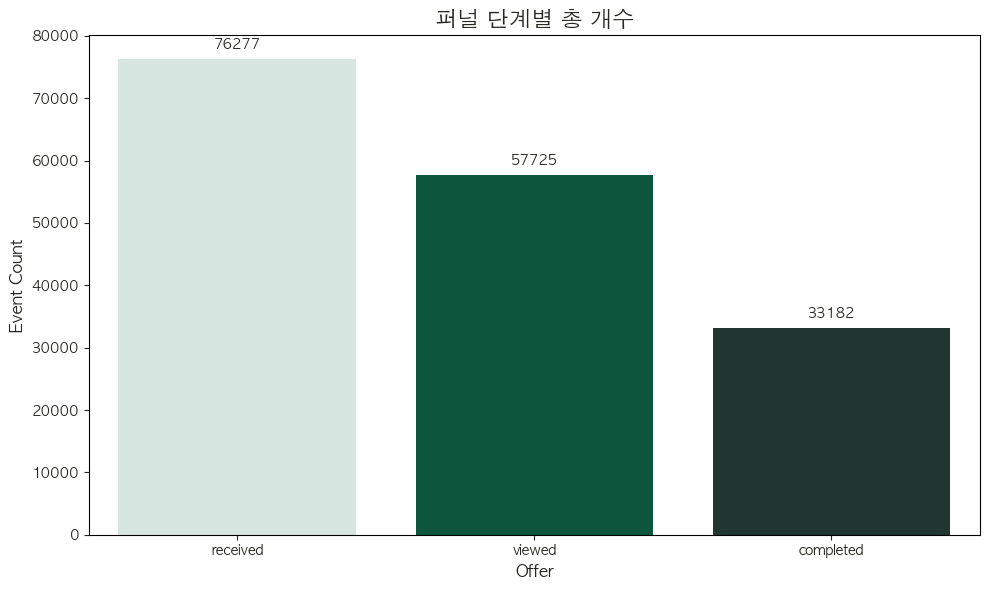

In [8]:
offer_events = ['received', 'viewed', 'completed']
event_counts = df['event'].value_counts().reindex(offer_events)

print(f"Received 건수: {event_counts['received']:,}")
print(f"Viewed 건수: {event_counts['viewed']:,}")
print(f"Completed 건수: {event_counts['completed']:,}")

plot_df = event_counts.reset_index()
plot_df.columns = ['Stage', 'Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_df, x='Stage', y='Count', 
                 palette=[SB_LIGHT_GREEN, SB_GREEN, SB_DEEP_GREEN], 
                 hue='Stage', legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title('퍼널 단계별 총 개수', fontsize=16, fontweight='bold')
plt.ylabel('Event Count', fontsize=12)
plt.xlabel('Offer', fontsize=12)

plt.tight_layout()
plt.show()

# 2. 오퍼별 

In [9]:
# trans_df에 'final_label' 컬럼 생성 (다중오퍼 및 개별 오퍼 라벨링)
def get_correct_label(row):
    # 종류가 다른 오퍼들이 섞인 경우 (tx_offer_type이 multi인 경우)
    if row.get('tx_offer_type') == 'multi':
        return '다중오퍼'
    # bogo나 discount 계열 내에서 여러 오퍼를 동시에 완료한 경우
    elif row.get('tx_offer_type') in ['bogo', 'discount']:
        try:
            labels = ast.literal_eval(row['reward_offer_label_list'])
            if len(labels) > 1:
                return '다중오퍼'
            elif len(labels) == 1:
                return labels[0]
        except:
            pass
    return '일반결제'

# trans_df에 'final_label' 컬럼을 직접 생성합니다.
transaction_df['final_label'] = transaction_df.apply(get_correct_label, axis=1)

# 생성된 final_label을 바탕으로 master_df(전체 퍼널 데이터) 구성
# trans_df에서 '다중오퍼'로 판명된 결제들의 사람/시간 정보 추출
multi_txn_info = transaction_df[transaction_df['final_label'] == '다중오퍼'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# merge_df의 완료 이벤트와 엮어서 '다중오퍼 경로' 키(key) 추출
completions = df[df['event'] == 'completed']
multi_path = pd.merge(completions, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# merge_df 전체(인포메이셔널 제외)에 'final_label' 장착
master_df = df[~df['offer_label'].str.contains('informational', na=False)].copy()
master_df = pd.merge(master_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')

# 다중오퍼 경로면 '다중오퍼', 아니면 기존 오퍼 분류 적용
master_df['final_label'] = master_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

성과별로 볼 때는 informational 제외

### 오퍼별 총 발송 수, 총 열람 수, 총 완료 수

In [10]:
# 발송/열람/완료  계산

# master_df에서 이벤트별로 개수 세기 (피벗 테이블 활용)
funnel_df = master_df.groupby(['final_label', 'event']).size().unstack(fill_value=0)

# 필요한 컬럼만 가져와서 이름붙이기 
funnel_df = funnel_df[['received', 'viewed', 'completed']]
funnel_df.columns = ['총발송수', '총열람수', '총완료수']

# 9종 오퍼 보기 좋게 순서 정렬
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
funnel_df = funnel_df.reindex(order)

# 결과 확인
display(funnel_df)

,총발송수,총열람수,총완료수
final_label,,,
bogo_1,7078,6249,3055
bogo_2,7124,6848,2832
bogo_3,7001,3826,3627
bogo_4,7035,6759,3726
discount_1,6894,2395,2560
discount_2,7012,6737,4476
discount_3,6862,6639,4526
discount_4,6966,3743,3296
다중오퍼,5070,3698,5084


### 1. 오퍼별 총 발송 수

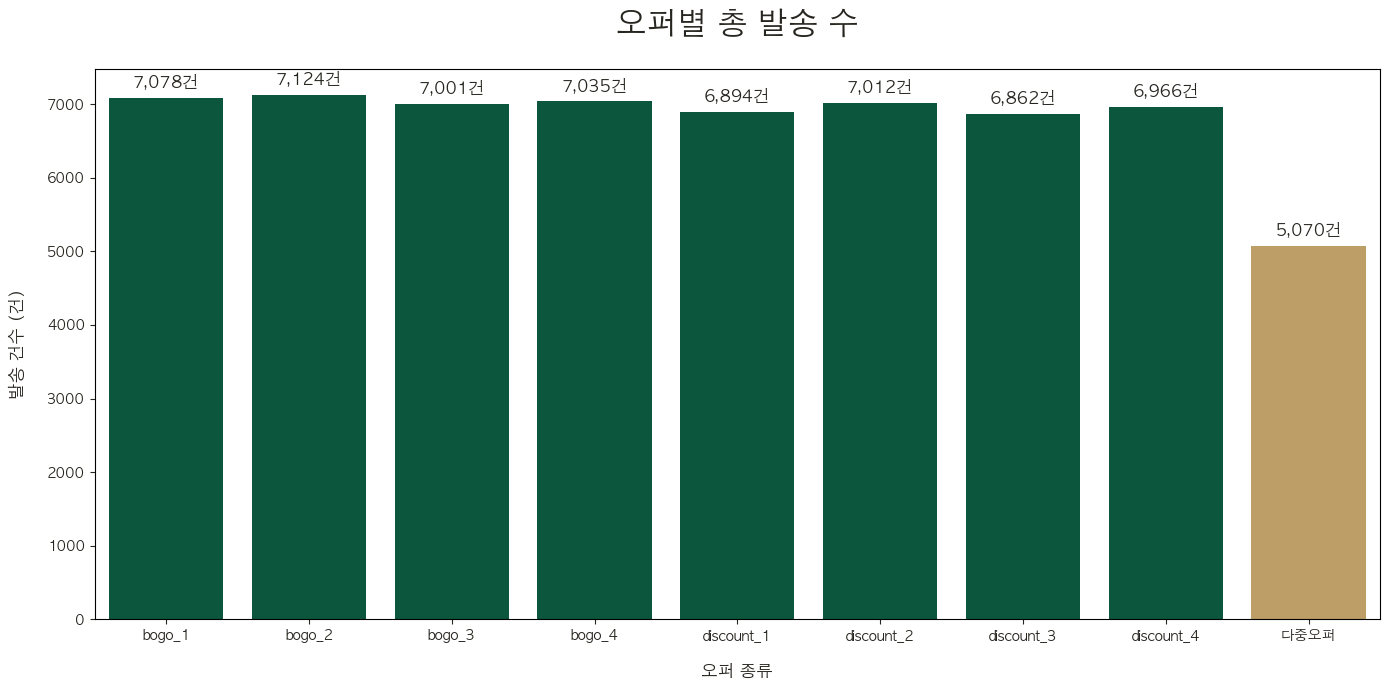

In [11]:
plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='총발송수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 발송 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('발송 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 2. 오퍼별 총 열람 수

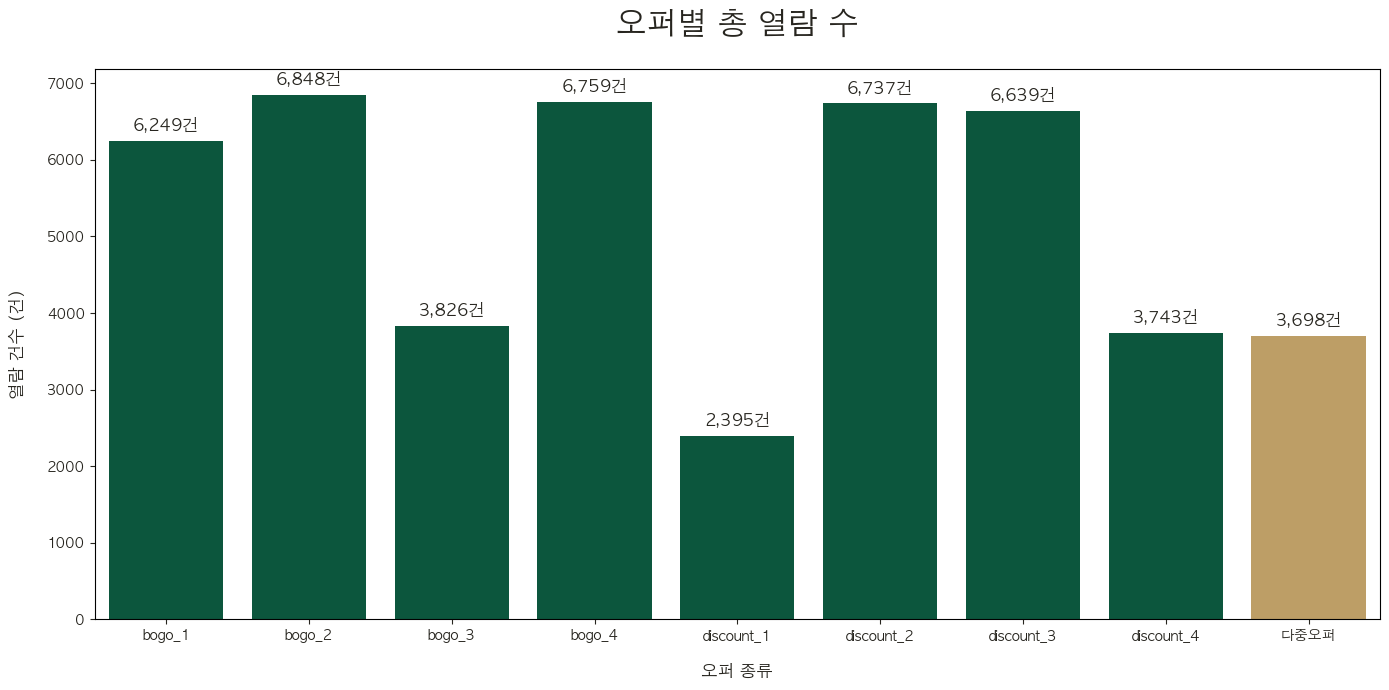

In [12]:
plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기 
ax = sns.barplot(data=plot_data, x='final_label', y='총열람수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 열람 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('열람 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 3. 오펴별 총 완료 수

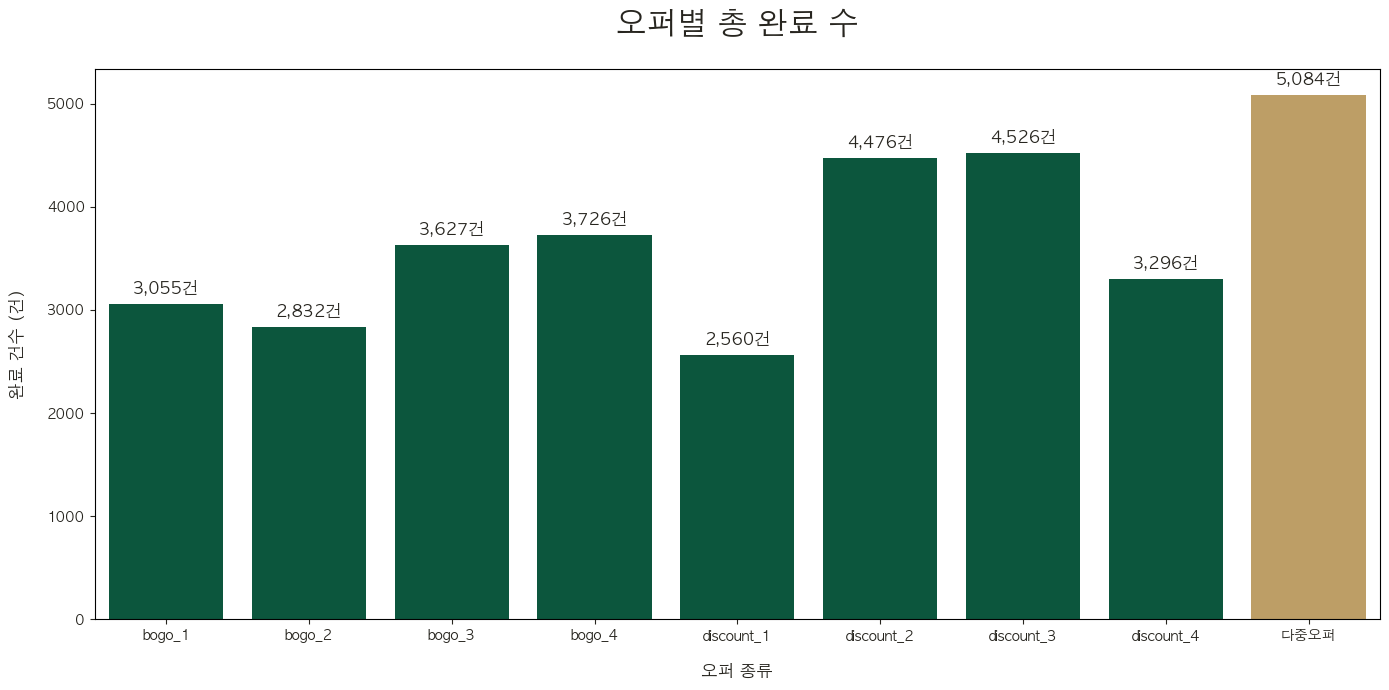

In [13]:
plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기 
ax = sns.barplot(data=plot_data, x='final_label', y='총완료수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 완료 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 4. 오퍼별 완료율 (%)

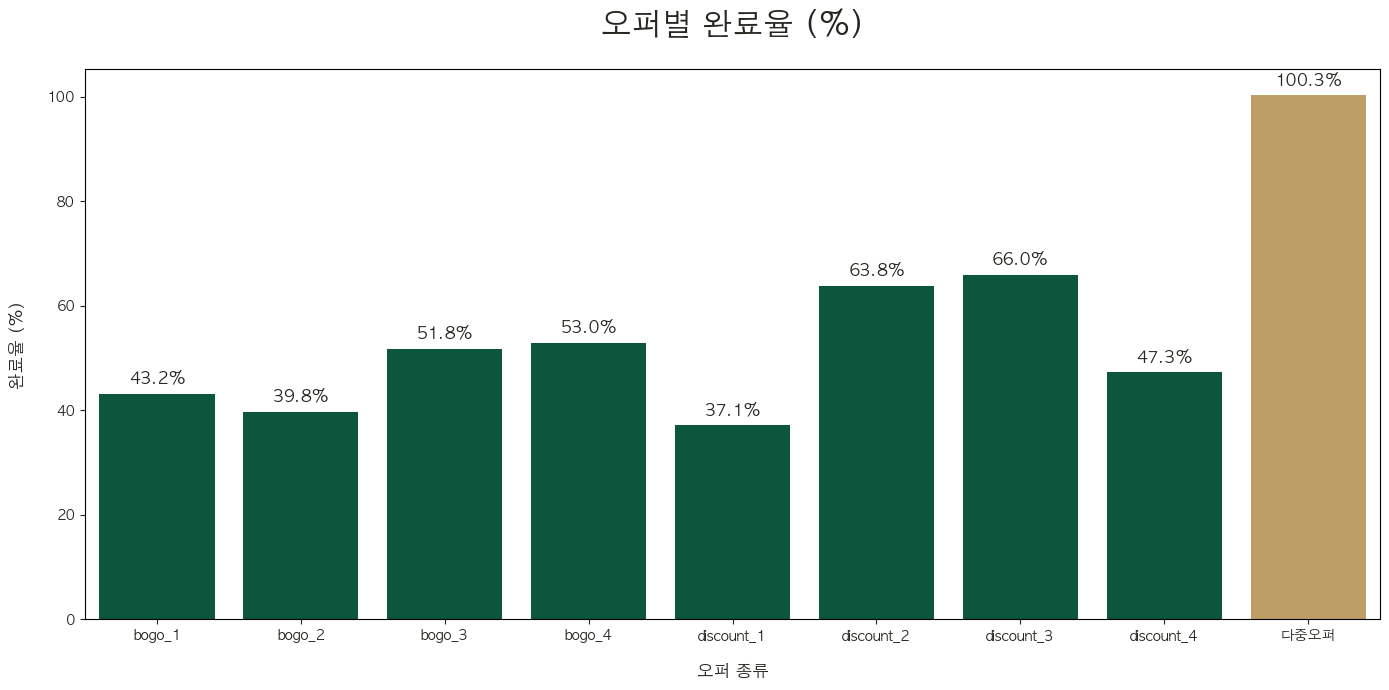

In [14]:
# 완료율 계산: (총완료수 / 총발송수) * 100
funnel_df['완료율(%)'] = (funnel_df['총완료수'] / funnel_df['총발송수']) * 100

plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='완료율(%)', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 완료율 (%)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=15)

# 막대 위에 소수점 첫째 자리와 % 기호 달아주기
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 5. 오퍼별 총 연계 매출

In [15]:
# # 1. 전체 매출액 계산 (merge_df의 모든 transaction 합계)
# total_sales_val = df[df['event'] == 'transaction']['amount'].sum()

# # 2. 오퍼 연계 매출액 계산 (trans_df에서 '다중오퍼'나 'bogo_n', 'discount_n'들의 합계)
# # '일반결제' 혹은 '일반 결제'라고 이름 붙은 것들을 제외한 모든 매출
# offer_sales_val = transaction_df[~transaction_df['final_label'].str.contains('일반', na=False)]['amount'].sum()

# # 3. 산출된 진짜 일반 결제액 (전체 - 오퍼)
# calculated_normal_sales = total_sales_val - offer_sales_val

# # 4. 시각화용 데이터프레임 업데이트
# # 10개 카테고리 매출을 새로 집계합니다.
# rev_10_data = transaction_df[~transaction_df['final_label'].str.contains('일반', na=False)].groupby('final_label')['amount'].sum().reset_index()

# # 여기에 일반 결제 한 줄을 추가
# normal_row = pd.DataFrame({'final_label': ['일반 결제'], 'amount': [calculated_normal_sales]})
# total_rev_10 = pd.concat([rev_10_data, normal_row], ignore_index=True)

# # 5. 순서 정렬 (띄어쓰기 고정)
# order_10 = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼', '일반 결제']
# total_rev_10['final_label'] = pd.Categorical(total_rev_10['final_label'], categories=order_10, ordered=True)
# total_rev_10 = total_rev_10.sort_values('final_label')

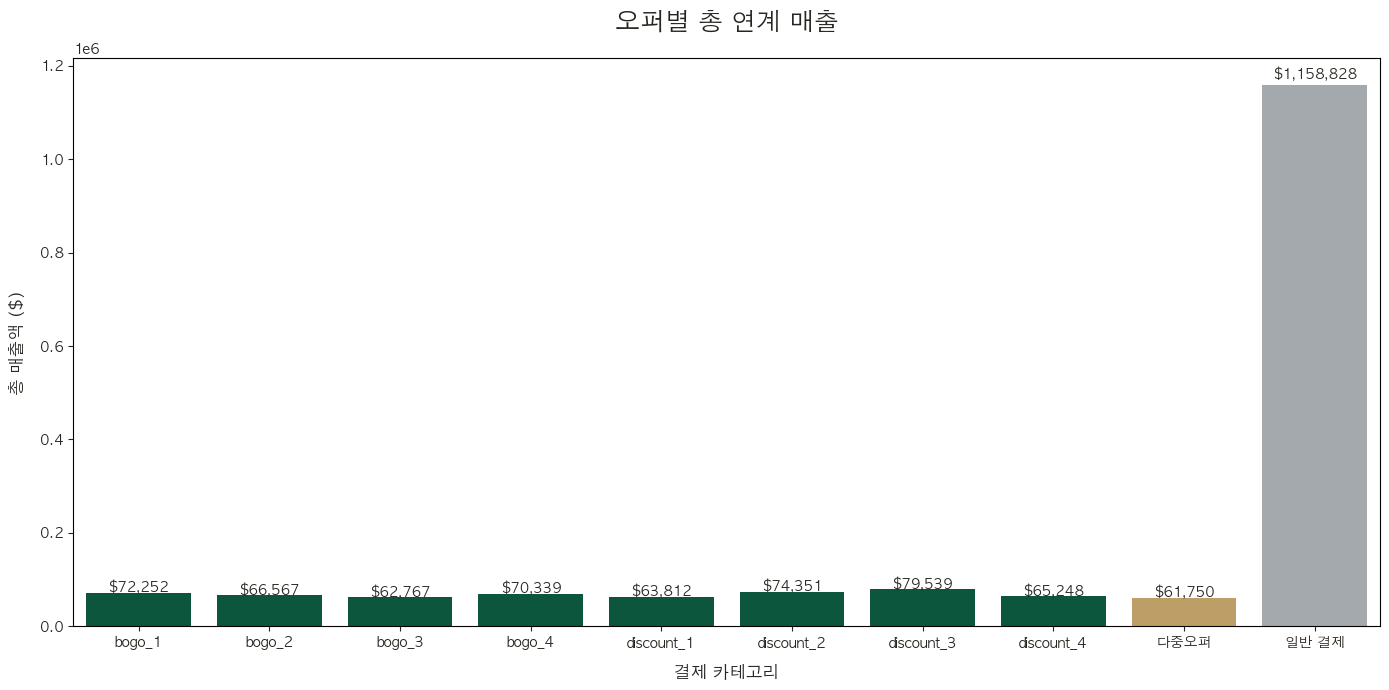

,final_label,amount
0,bogo_1,72251.56
1,bogo_2,66567.32
2,bogo_3,62767.30
3,bogo_4,70338.90
4,discount_1,63811.75
5,discount_2,74350.56
6,discount_3,79538.92
7,discount_4,65247.52
8,다중오퍼,61749.85
9,일반 결제,1158828.29


In [16]:
# 일반 결제 금액 산출 (전체 - 오퍼)

# 전체 매출액 (merge_df 기준)
total_sales_val = df[df['event'] == 'transaction']['amount'].sum()

# 오퍼 연계 매출액 (trans_df에서 '일반'을 제외한 모든 것)
offer_sales_val = transaction_df[~transaction_df['final_label'].str.contains('일반', na=False)]['amount'].sum()

# 일반 결제액
normal_sales_val = total_sales_val - offer_sales_val

# 시각화용 요약 테이블 만들기

# 먼저 오퍼별 매출 집계
revenue_summary = transaction_df[~transaction_df['final_label'].str.contains('일반', na=False)].groupby('final_label')['amount'].sum().reset_index()

# 여기에 계산한 '일반 결제' 행을 추가
normal_row = pd.DataFrame({'final_label': ['일반 결제'], 'amount': [normal_sales_val]})
revenue_summary = pd.concat([revenue_summary, normal_row], ignore_index=True)

order_10 = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼', '일반 결제']
revenue_summary['final_label'] = pd.Categorical(revenue_summary['final_label'], categories=order_10, ordered=True)
revenue_summary = revenue_summary.sort_values('final_label')

# 금액순으로 내림차순 정렬
# revenue_summary = revenue_summary.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 시각화
plt.figure(figsize=(14, 7))

# 카테고리에 따른 색상 배정 (일반: 회색, 다중오퍼: 골드, 개별오퍼: 그린)
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in revenue_summary['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_label', y='amount', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 + $)
for i, v in enumerate(revenue_summary['amount']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 데이터 확인
display(revenue_summary)

### 오퍼별 총 연계매출 - 합산본

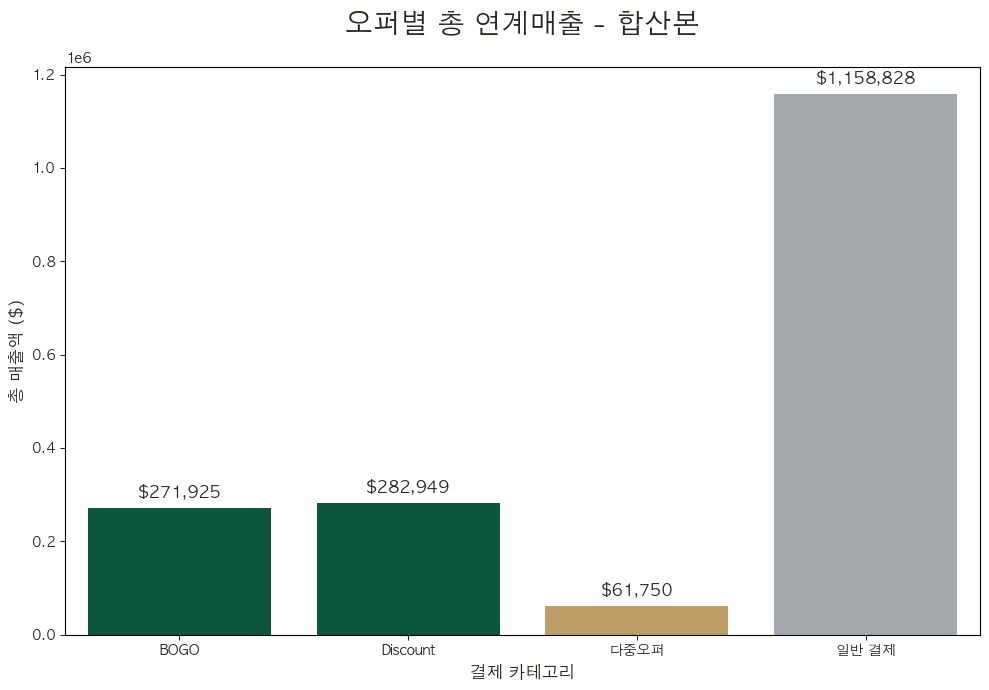

,group,amount
0,BOGO,271925.08
1,Discount,282948.75
2,다중오퍼,61749.85
3,일반 결제,1158828.29


In [17]:
# 그룹화 데이터 준비
# 아까 만든 10종 매출 데이터(revenue_summary)를 활용
summary_4 = revenue_summary.copy()

def get_group_4(label):
    if 'bogo' in label.lower(): return 'BOGO'
    elif 'discount' in label.lower(): return 'Discount'
    elif '다중' in label: return '다중오퍼'
    else: return '일반 결제'

summary_4['group'] = summary_4['final_label'].apply(get_group_4)

# 그룹별 매출 합계 계산
summary_4_final = summary_4.groupby('group')['amount'].sum().reset_index()

# 순서 고정
order_4 = ['BOGO', 'Discount', '다중오퍼', '일반 결제']
summary_4_final['group'] = pd.Categorical(summary_4_final['group'], categories=order_4, ordered=True)
summary_4_final = summary_4_final.sort_values('group')

plt.figure(figsize=(10, 7))

# 색상 매칭
colors_4 = [SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=summary_4_final, x='group', y='amount', palette=colors_4)

plt.title('오퍼별 총 연계매출 - 합산본', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12)
plt.ylabel('총 매출액 ($)', fontsize=12)

# 금액 표시 ($ + 천 단위 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(summary_4_final)

### 6. 오퍼별 발송당 평균 수익 (RPS)

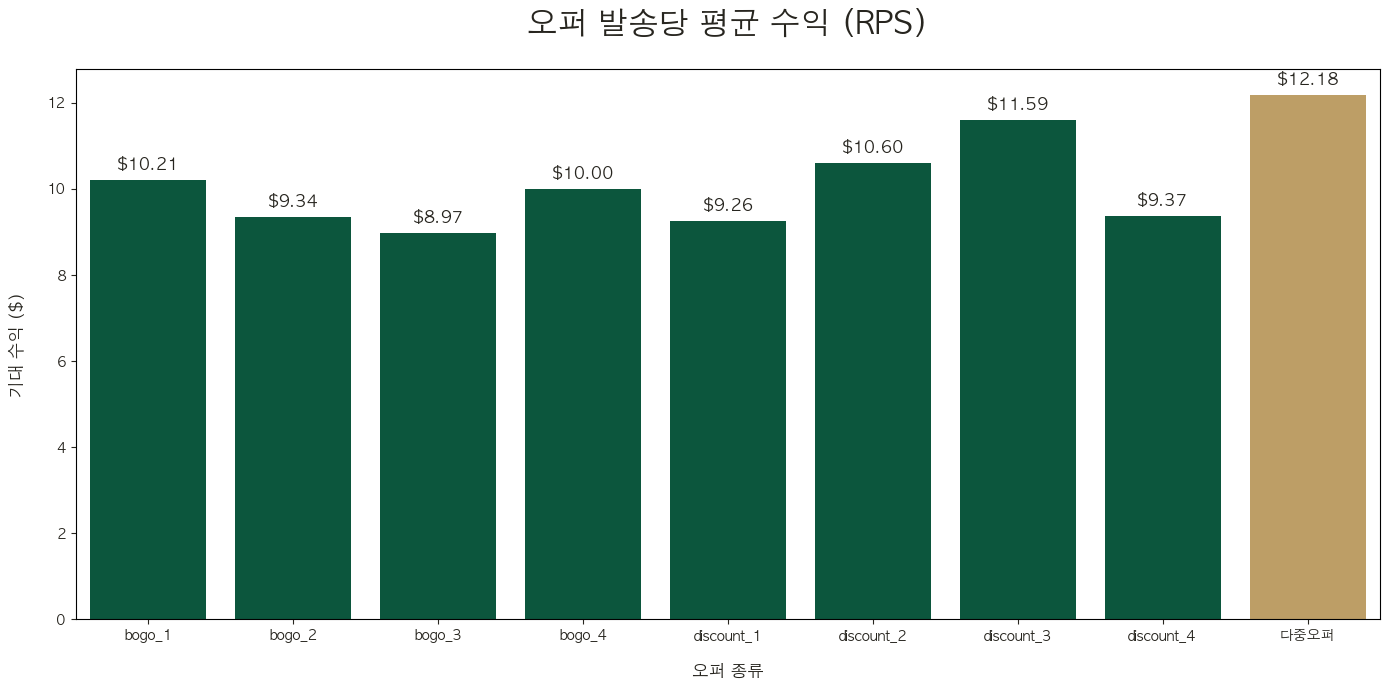

In [18]:
# 오퍼 연계 결제만 필터링
offer_txns = transaction_df[transaction_df['final_label'] != '일반결제']

# 효율 지표 계산 (총매출, 거래횟수, 인원수)
efficiency_df = pd.DataFrame({
    '총매출': offer_txns.groupby('final_label')['amount'].sum(),
    '결제인원수': offer_txns.groupby('final_label')['person'].nunique()
})

# RPS(발송당 기대수익) 계산 - funnel_df의 총발송수와 매칭
efficiency_df['발송1건당_매출'] = efficiency_df['총매출'] / funnel_df['총발송수']

# 순서 정렬 (bogo_1 ~ 다중오퍼)
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
efficiency_df = efficiency_df.reindex(order)

# 그래프용 데이터 변환 
plot_data = efficiency_df.reset_index()

# 2. 시각화 
plt.figure(figsize=(14, 7))

colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='발송1건당_매출', palette=colors)


plt.title('오퍼 발송당 평균 수익 (RPS)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('기대 수익 ($)', fontsize=12, labelpad=15)

# 값 표시 
for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val): # 데이터가 있는 경우만 표시
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 7. 오퍼 완료당 평균 매출

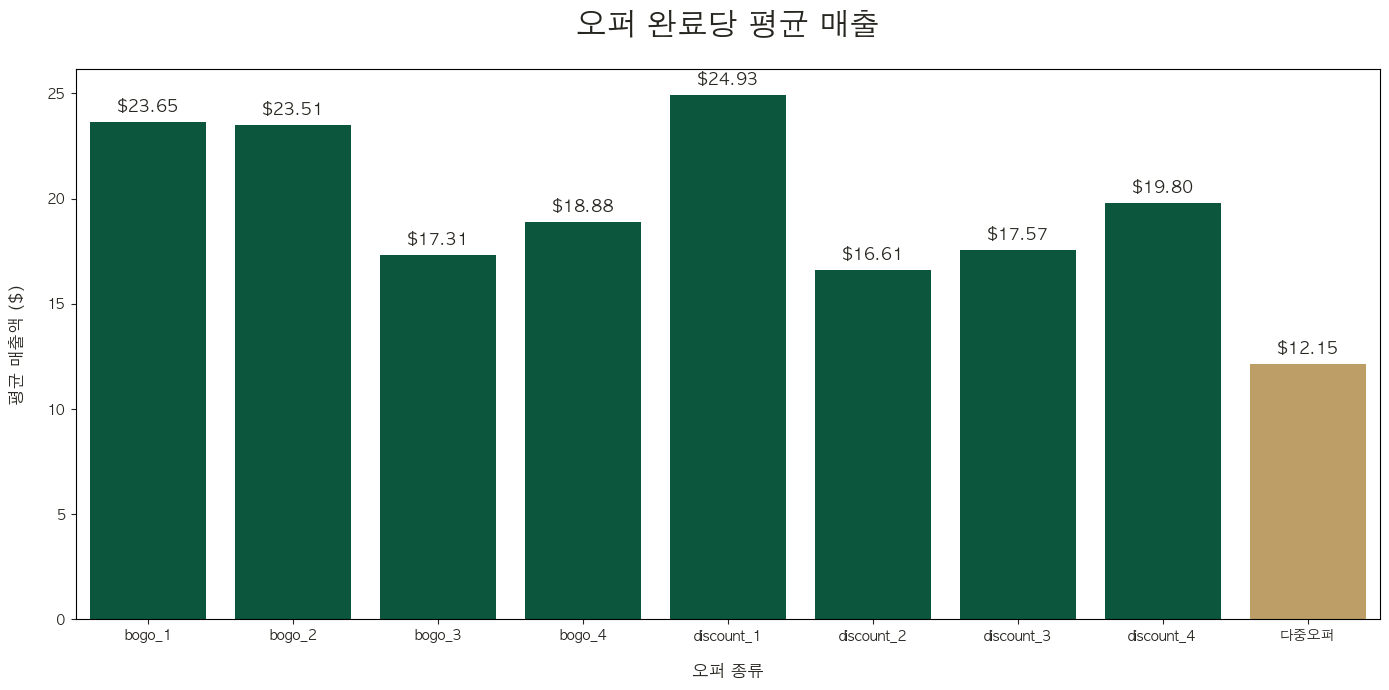

,총매출,완료당_평균_매출
final_label,,
bogo_1,72251.56,23.650265
bogo_2,66567.32,23.505410
bogo_3,62767.30,17.305569
bogo_4,70338.90,18.877858
discount_1,63811.75,24.926465
discount_2,74350.56,16.610938
discount_3,79538.92,17.573778
discount_4,65247.52,19.795971
다중오퍼,61749.85,12.145919


In [19]:
# 데이터 계산 (완료당 매출)

# efficiency_df에 '완료당_평균_매출' 컬럼 추가
# 총매출을 funnel_df의 총완료수로 나눔
efficiency_df['완료당_평균_매출'] = efficiency_df['총매출'] / funnel_df['총완료수']

# 그래프용 데이터 변환 
plot_data_comp = efficiency_df.reset_index()

# 시각화
plt.figure(figsize=(14, 7))

# 색상 설정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data_comp['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data_comp, x='final_label', y='완료당_평균_매출', palette=colors)

plt.title('오퍼 완료당 평균 매출', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('평균 매출액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시 ($ + 소수점 둘째자리)
for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val):
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 확인용
display(efficiency_df[['총매출', '완료당_평균_매출']].head(10))

### 8. 인당 평균 결제액 (ARPU)

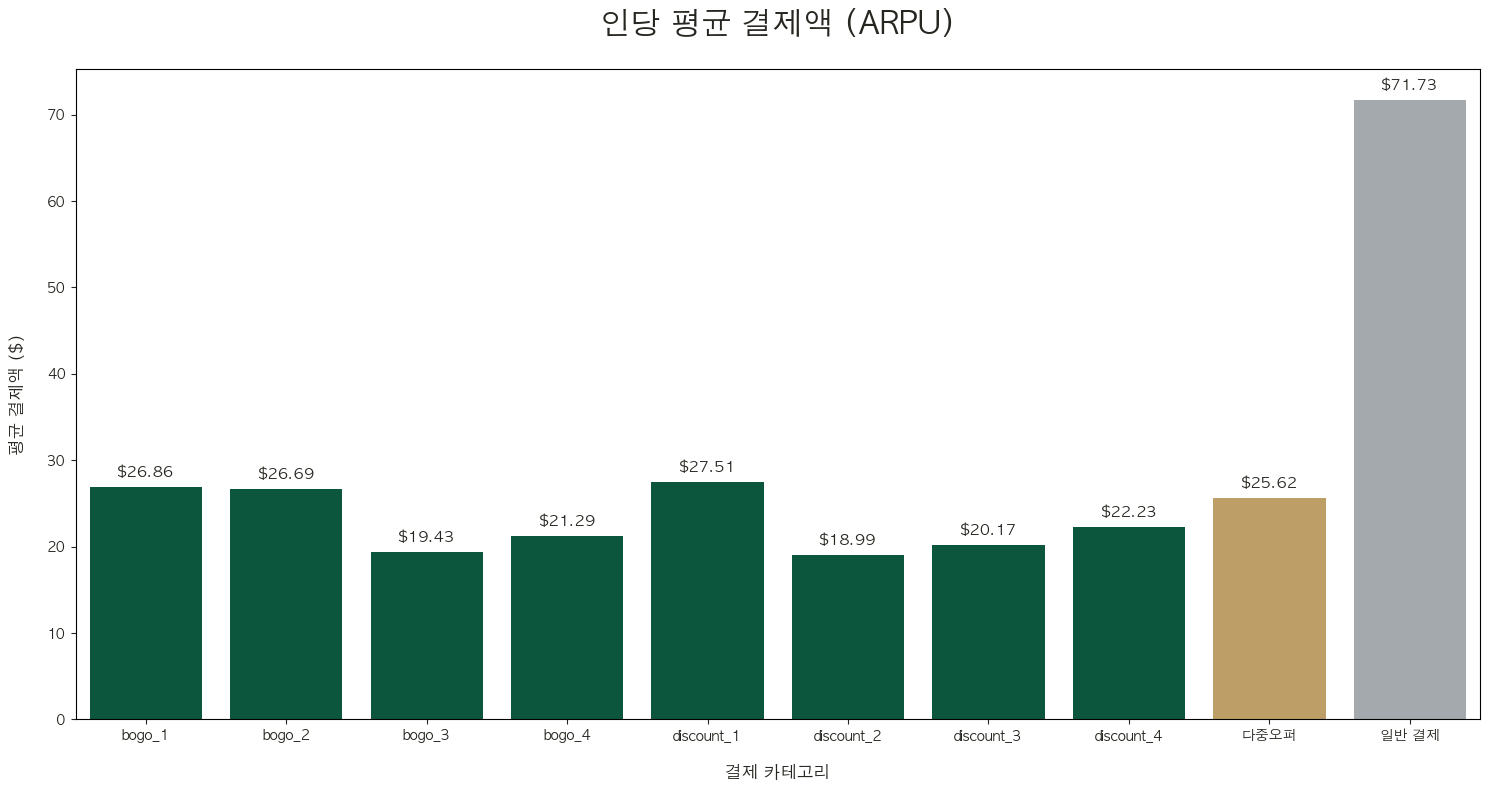

,final_label,총매출,결제인원수,ARPU
0,bogo_1,72251.56,2690,26.859316
1,bogo_2,66567.32,2494,26.690986
2,bogo_3,62767.30,3230,19.432601
3,bogo_4,70338.90,3304,21.289013
4,discount_1,63811.75,2320,27.505065
5,discount_2,74350.56,3915,18.991203
6,discount_3,79538.92,3944,20.167069
7,discount_4,65247.52,2935,22.230842
8,다중오퍼,61749.85,2410,25.622344
9,일반 결제,1158828.29,16156,71.727426


In [20]:
# ARPU 데이터 계산 (인원수 기준)
# trans_df의 final_label 이름을 통일 (띄어쓰기 방지)
transaction_df['final_label'] = transaction_df['final_label'].replace('일반결제', '일반 결제')

# 카테고리별 총매출액과 순수 결제 인원수(Unique Users) 계산
arpu_df = transaction_df.groupby('final_label').agg({
    'amount': 'sum',
    'person': 'nunique'
}).reset_index()

# 컬럼 이름 변경 및 ARPU 계산
arpu_df.columns = ['final_label', '총매출', '결제인원수']
arpu_df['ARPU'] = arpu_df['총매출'] / arpu_df['결제인원수']

# 10개 카테고리 순서 정의
order_10 = [
    'bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 
    'discount_1', 'discount_2', 'discount_3', 'discount_4', 
    '다중오퍼', '일반 결제'
]

arpu_df['final_label'] = pd.Categorical(arpu_df['final_label'], categories=order_10, ordered=True)
arpu_df = arpu_df.sort_values('final_label')


# 시각화
plt.figure(figsize=(15, 8))

# 색상 설정 
colors = [SB_GREY if cat == '일반 결제' else (SB_GOLD if cat == '다중오퍼' else SB_GREEN) for cat in arpu_df['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=arpu_df, x='final_label', y='ARPU', palette=colors)


plt.title('인당 평균 결제액 (ARPU)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=15)
plt.ylabel('평균 결제액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시 
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(arpu_df[['final_label', '총매출', '결제인원수', 'ARPU']])

### 9. 오퍼별 평균 완료 소요 시간 (Received → Completed)

In [21]:
# received / completed 이벤트 추출
received_data = noinfo_merge_df[noinfo_merge_df['event'] == 'received'][['person', 'offer_id', 'offer_label', 'receive_seq', 'time']].copy()
completed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'completed'][['person', 'offer_id', 'offer_label', 'receive_seq', 'time']].copy()

# 컬럼명 변경
received_data = received_data.rename(columns={'time': 'received_time'})
completed_data = completed_data.rename(columns={'time': 'completed_time'})

# 같은 오퍼 인스턴스 기준으로 연결
time_df = pd.merge(
    completed_data,
    received_data,
    on=['person', 'offer_id', 'offer_label', 'receive_seq'],
    how='left'
)

# 완료까지 걸린 시간 계산
time_df['time_to_complete'] = time_df['completed_time'] - time_df['received_time']

# 이상치 제거
time_df = time_df[time_df['time_to_complete'] >= 0]

# 오퍼별 평균 완료 소요 시간
avg_completion_time = (
    time_df.groupby('offer_label')['time_to_complete']
    .mean()
    .sort_values()
)

print("오퍼별 평균 완료 소요 시간")
print(avg_completion_time)

오퍼별 평균 완료 소요 시간
offer_label
bogo_4         42.316753
bogo_2         42.338079
bogo_1         54.465475
discount_2     56.992958
bogo_3         58.139902
discount_4     63.850656
discount_3     72.410256
discount_1    101.482635
Name: time_to_complete, dtype: float64


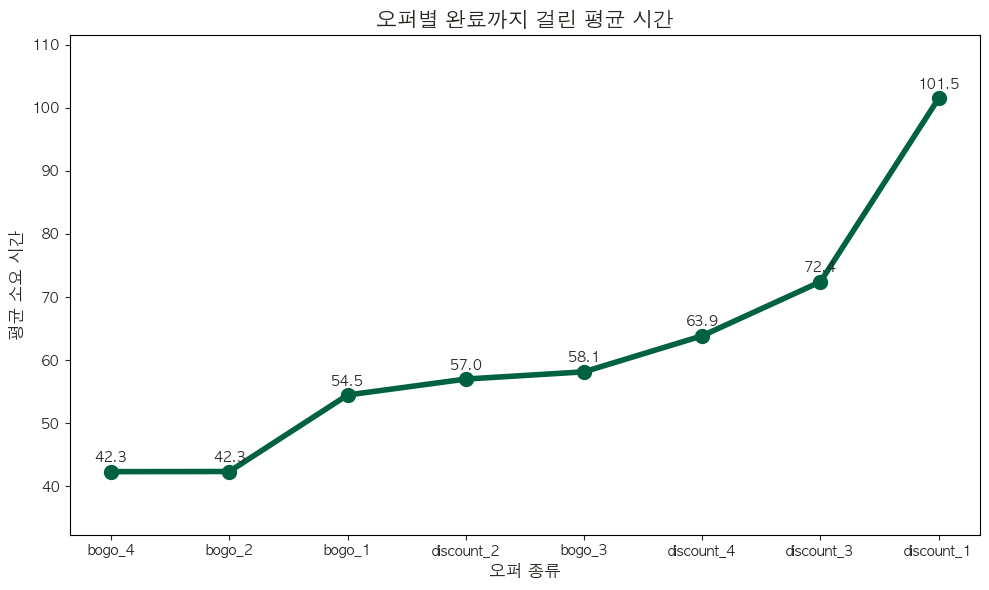

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    avg_completion_time.index,
    avg_completion_time.values,
    marker='o',
    linestyle='-',
    linewidth=4,
    markersize=8,
    color=SB_GREEN,
    markeredgewidth=3
)

y_min = avg_completion_time.min() - 10
y_max = avg_completion_time.max() + 10
plt.ylim(y_min, y_max)

for i, v in enumerate(avg_completion_time.values):
    plt.text(i, v + 1.5, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.title('오퍼별 완료까지 걸린 평균 시간', fontsize=15, fontweight='bold')
plt.xlabel('오퍼 종류', fontsize=12)
plt.ylabel('평균 소요 시간', fontsize=12)

plt.tight_layout()
plt.show()

# 3. 채널별 

### 1. 채널별 오퍼 발송 수

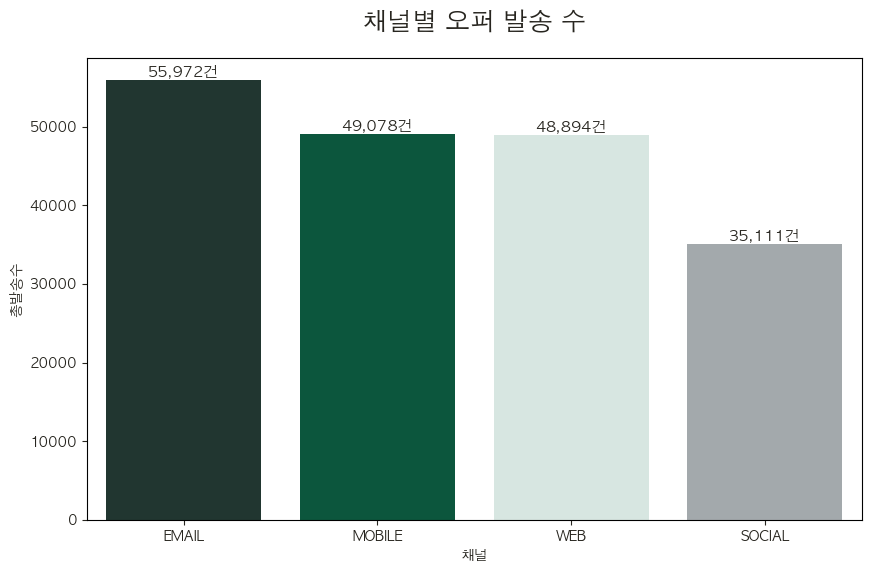

In [23]:
# 채널별 총 발송 수 (Received)
channels = ['web', 'email', 'mobile', 'social']
# 8종 개별 오퍼만 대상 (다중오퍼/일반결제 제외하고 진짜 채널 효과만 보기!)
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
channel_base = master_df[(master_df['final_label'].isin(offer_8_labels)) & (master_df['event'] == 'received')]

# 채널별 컬럼 합계 구하기
channel_sent = channel_base[channels].sum().reset_index()
channel_sent.columns = ['채널', '총발송수']
channel_sent['채널'] = channel_sent['채널'].str.upper()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=channel_sent.sort_values('총발송수', ascending=False), 
                 x='채널', y='총발송수', palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, SB_GREY]) 

plt.title('채널별 오퍼 발송 수', fontsize=18, fontweight='bold', pad=20)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

### 2. 채널별 오퍼 열람률 (%)

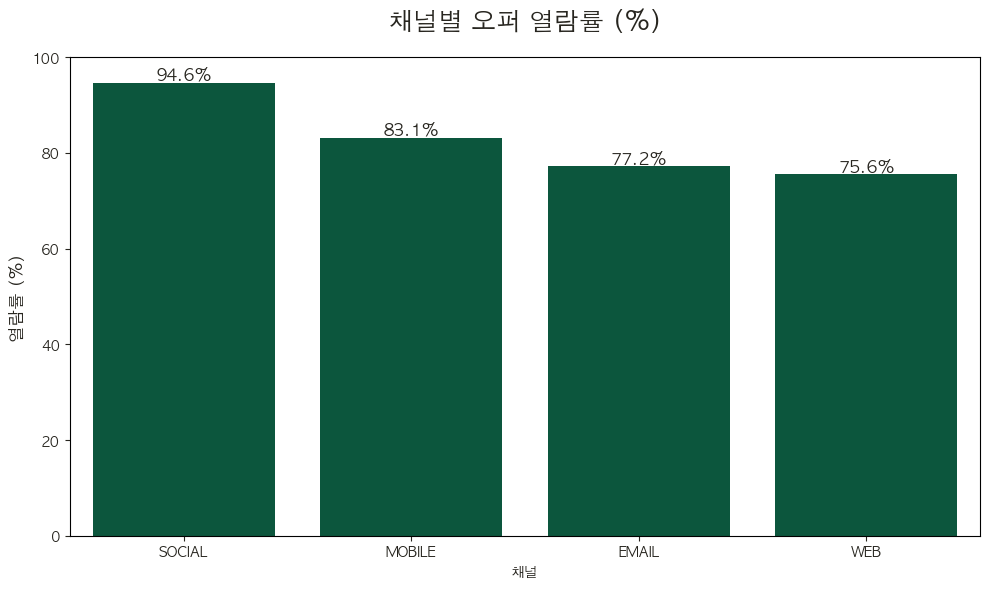

In [24]:
# 채널별 열람률 계산 (Viewed / Received)

# 8종 개별 오퍼만 필터링
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
offer_8_df = master_df[master_df['final_label'].isin(offer_8_labels)]


# 채널별 발송 수(received)와 열람 수(viewed) 집계
sent_by_channel = offer_8_df[offer_8_df['event'] == 'received'][channels].sum()
viewed_by_channel = offer_8_df[offer_8_df['event'] == 'viewed'][channels].sum()

# 열람률(%) 계산
channel_view_rate = (viewed_by_channel / sent_by_channel * 100).reset_index()
channel_view_rate.columns = ['채널', '열람률']
channel_view_rate['채널'] = channel_view_rate['채널'].str.upper()


# 시각화

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_view_rate.sort_values('열람률', ascending=False), 
                 x='채널', y='열람률', color=SB_GREEN)

plt.title('채널별 오퍼 열람률 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('열람률 (%)', fontsize=12)

# 막대 위에 퍼센트(%) 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

### 3. 채널별 오퍼 완료율 (%)

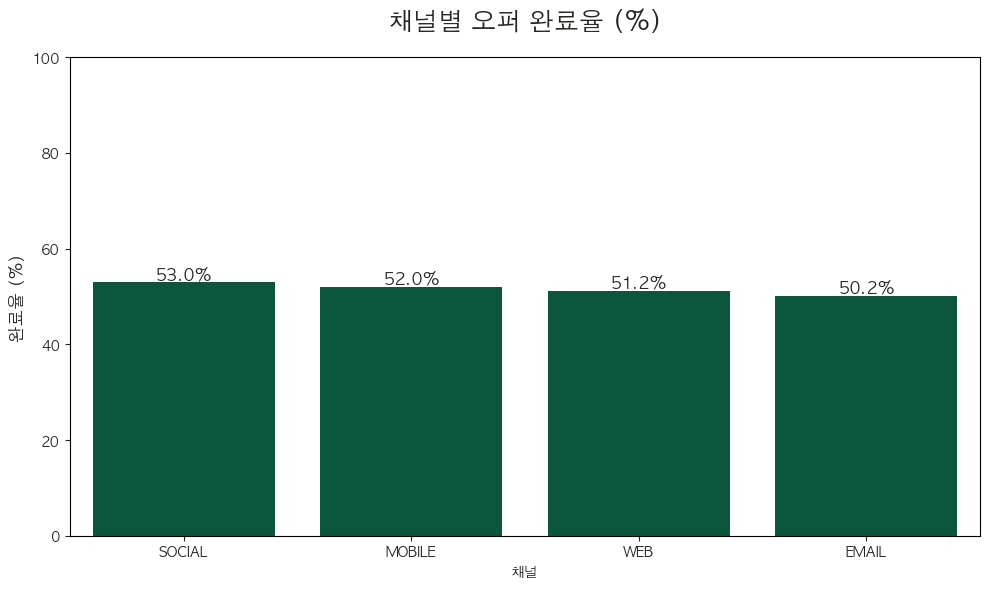

In [25]:
# 채널별 완료율 계산 (Completed / Received)

# 8종 개별 오퍼만 필터링
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
offer_8_df = master_df[master_df['final_label'].isin(offer_8_labels)]

# 채널별 발송 수(received)와 완료 수(completed) 집계
sent_by_channel = offer_8_df[offer_8_df['event'] == 'received'][channels].sum()
completed_by_channel = offer_8_df[offer_8_df['event'] == 'completed'][channels].sum()

# 완료율(%) 계산: (총완료수 / 총발송수) * 100
channel_complete_rate = (completed_by_channel / sent_by_channel * 100).reset_index()
channel_complete_rate.columns = ['채널', '완료율']
channel_complete_rate['채널'] = channel_complete_rate['채널'].str.upper()

# 시각화 
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_complete_rate.sort_values('완료율', ascending=False), 
                 x='채널', y='완료율', color=SB_GREEN)

plt.title('채널별 오퍼 완료율 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('완료율 (%)', fontsize=12)

# 막대 위에 퍼센트(%) 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

### 4. 채널별 총 매출

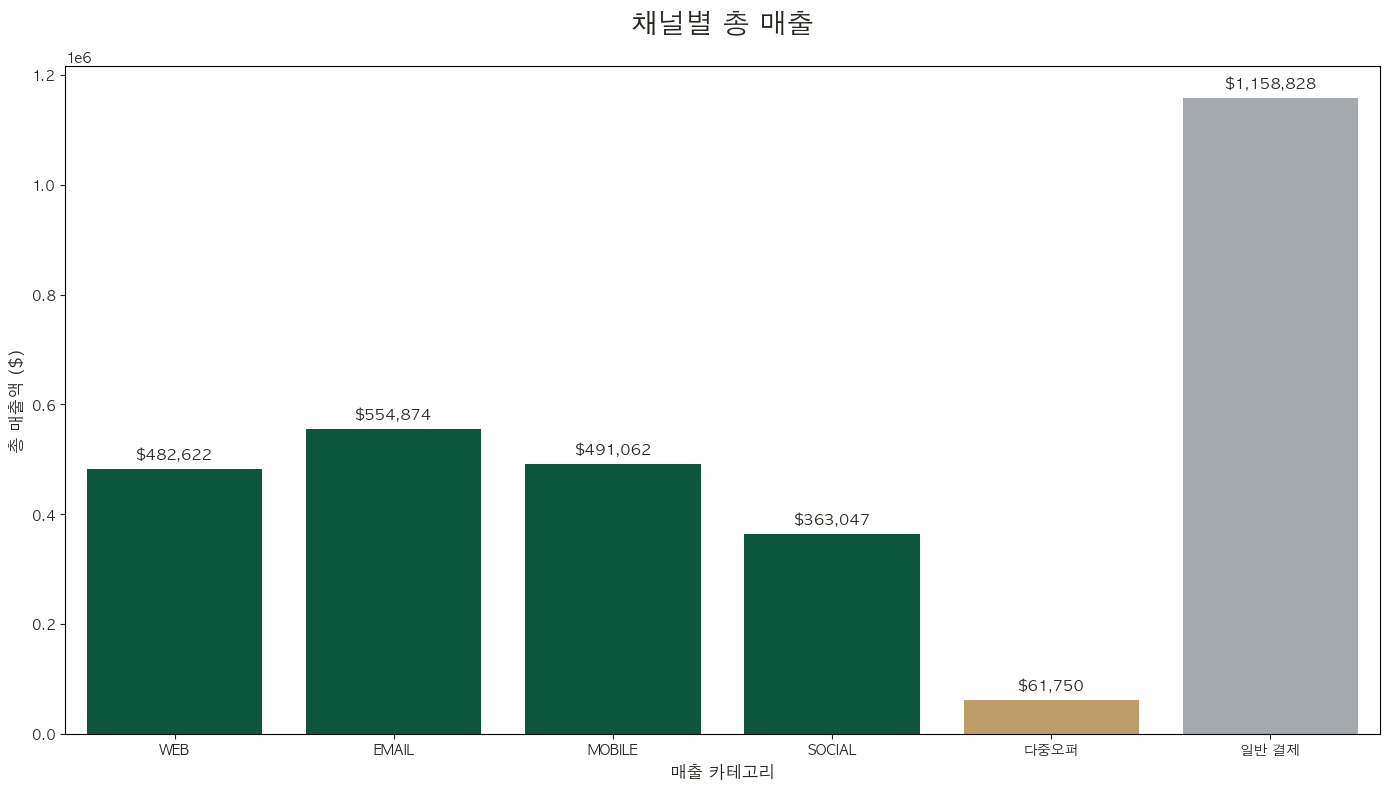

In [26]:
# 채널별 매출 집계
# 8종 오퍼 이름표 정의
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 매출액 집계
rev_by_offer = transaction_df.groupby('final_label')['amount'].sum().reset_index()

# master_df에서 오퍼별 채널 매핑 정보 추출
offer_channel_map = master_df[master_df['offer_label'].isin(offer_8_labels)][['offer_label'] + channels].drop_duplicates()

# 4대 채널 매출액 계산
channel_total_rev = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 매출 합산
    ch_sum = rev_by_offer[rev_by_offer['final_label'].isin(linked_offers)]['amount'].sum()
    channel_total_rev.append({'category': ch.upper(), 'amount': ch_sum})

# 다중오퍼 및 일반 결제 추가
# 다중오퍼 매출
multi_rev_val = rev_by_offer[rev_by_offer['final_label'] == '다중오퍼']['amount'].sum()

# 일반 결제 매출 (전체 - 오퍼연계) 로직 재확인
normal_rev_val = total_sales_val - offer_sales_val

# 리스트에 추가
channel_total_rev.append({'category': '다중오퍼', 'amount': multi_rev_val})
channel_total_rev.append({'category': '일반 결제', 'amount': normal_rev_val})

# 데이터프레임 변환
df_final_revenue = pd.DataFrame(channel_total_rev)

# 시각화 
plt.figure(figsize=(14, 8))

# 색상 설정: 채널(그린), 다중(골드), 일반(회색)
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=df_final_revenue, x='category', y='amount', palette=colors)

plt.title('채널별 총 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('총 매출액 ($)', fontsize=12)
plt.xlabel('매출 카테고리', fontsize=12)

# 막대 위에 금액 표시 ($ + 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 5. 채널별 완료당 평균 매출

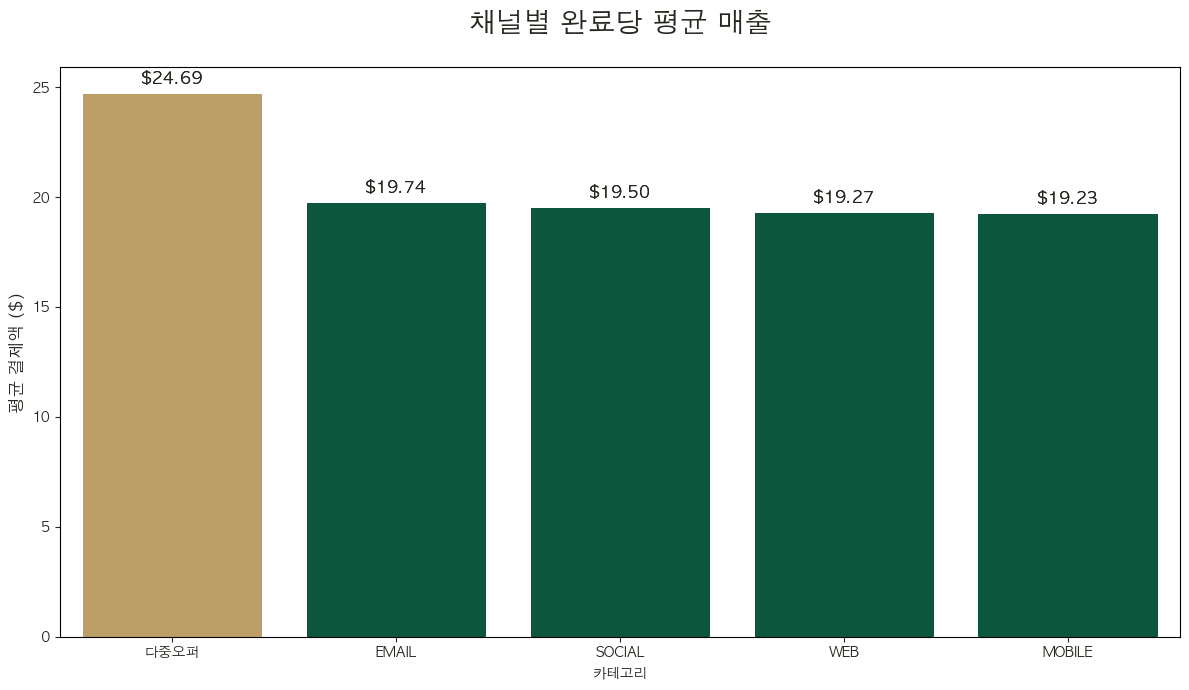

In [27]:
# 채널별 & 다중오퍼 완료당 매출 계산

# 8종 개별 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

channel_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 완료(completed) 건들
    ch_comps = master_df[(master_df['event'] == 'completed') & 
                         (master_df['final_label'].isin(offer_8_labels)) & 
                         (master_df[ch] == 1)]
    
    # 해당 완료 건의 총 매출액 매칭
    ch_rev = pd.merge(ch_comps[['person', 'time']], 
                      trans_df[['person', 'time', 'amount']], 
                      on=['person', 'time'], how='inner')['amount'].sum()
    
    ch_count = len(ch_comps)
    avg_val = ch_rev / ch_count if ch_count > 0 else 0
    channel_data.append({'카테고리': ch.upper(), '완료당_평균_매출': avg_val})

# 다중오퍼 데이터 집계
multi_comps = master_df[(master_df['event'] == 'completed') & (master_df['final_label'] == '다중오퍼')]
multi_rev = pd.merge(multi_comps[['person', 'time']], 
                     trans_df[['person', 'time', 'amount']], 
                     on=['person', 'time'], how='inner')['amount'].sum()
multi_count = len(multi_comps)
multi_avg = multi_rev / multi_count if multi_count > 0 else 0

# 데이터 합치기
df_comp_final = pd.DataFrame(channel_data)
df_comp_final = pd.concat([df_comp_final, pd.DataFrame([{'카테고리': '다중오퍼', '완료당_평균_매출': multi_avg}])], ignore_index=True)

# 시각화 
plt.figure(figsize=(12, 7))

# 색상 설정
colors = [SB_GREEN] * 4 + [SB_GOLD]

# 금액 순으로 정렬
ax = sns.barplot(data=df_comp_final.sort_values('완료당_평균_매출', ascending=False), 
                 x='카테고리', y='완료당_평균_매출', palette='viridis') # 혹은 위에서 만든 colors 적용

# 직접 지정한 색상 적용 (정렬 상태에 맞게 다시 매핑)
plot_order = df_comp_final.sort_values('완료당_평균_매출', ascending=False)['카테고리'].tolist()
final_colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_order]

ax = sns.barplot(data=df_comp_final.sort_values('완료당_평균_매출', ascending=False), 
                 x='카테고리', y='완료당_평균_매출', palette=final_colors)

plt.title('채널별 완료당 평균 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('평균 결제액 ($)', fontsize=12)

# 막대 위에 금액 표시
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 6. 채널별 총 거래 횟수

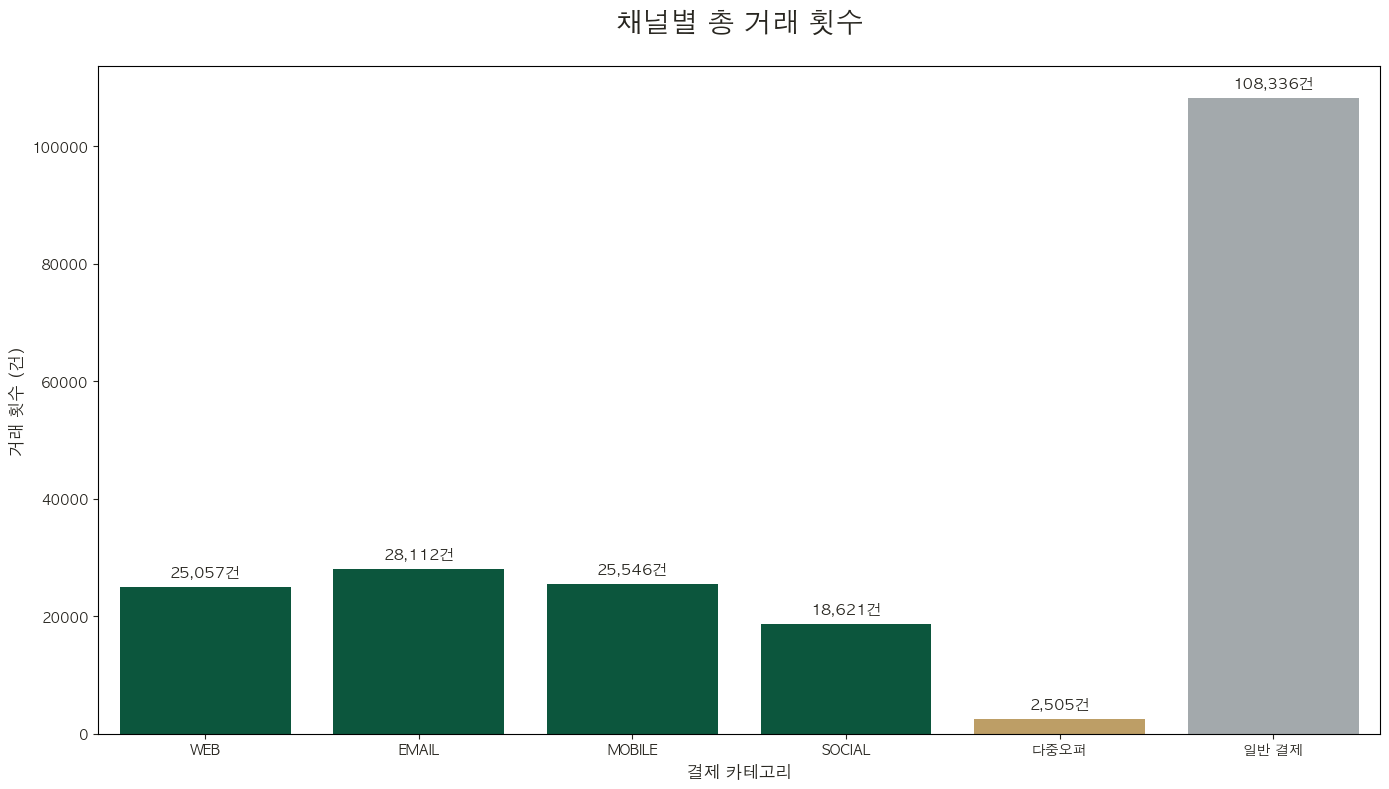

In [28]:
# 거래 횟수 집계 

# 8종 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 거래 횟수 계산 (trans_df 활용)
counts_by_offer = transaction_df.groupby('final_label').size().reset_index(name='count')

# 4대 채널 거래 횟수 (8종 오퍼 매핑)
offer_channel_map = master_df[master_df['offer_label'].isin(offer_8_labels)][['offer_label'] + channels].drop_duplicates()

channel_counts = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 거래 횟수 합산
    ch_sum = counts_by_offer[counts_by_offer['final_label'].isin(linked_offers)]['count'].sum()
    channel_counts.append({'category': ch.upper(), 'count': ch_sum})

# 다중오퍼 및 일반 결제 추가
# 다중오퍼 횟수
multi_count_val = counts_by_offer[counts_by_offer['final_label'] == '다중오퍼']['count'].sum()

# 일반 결제 횟수 (전체 거래수 - 오퍼연계 거래수)
total_txn_count = len(df[df['event'] == 'transaction'])
offer_txn_count = len(transaction_df[~transaction_df['final_label'].str.contains('일반', na=False)])
normal_count_val = total_txn_count - offer_txn_count

# 최종 데이터 정리
channel_counts.append({'category': '다중오퍼', 'count': multi_count_val})
channel_counts.append({'category': '일반 결제', 'count': normal_count_val})

df_final_counts = pd.DataFrame(channel_counts)


# 시각화 
plt.figure(figsize=(14, 8))

# 색상
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=df_final_counts, x='category', y='count', palette=colors)

plt.title('채널별 총 거래 횟수', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('거래 횟수 (건)', fontsize=12)
plt.xlabel('결제 카테고리', fontsize=12)

# 막대 위에 숫자 표시 (천 단위 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"{int(val):,}건", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 7. 채널 및 결제 유형별 RPS (발송 1건당 평균 매출)

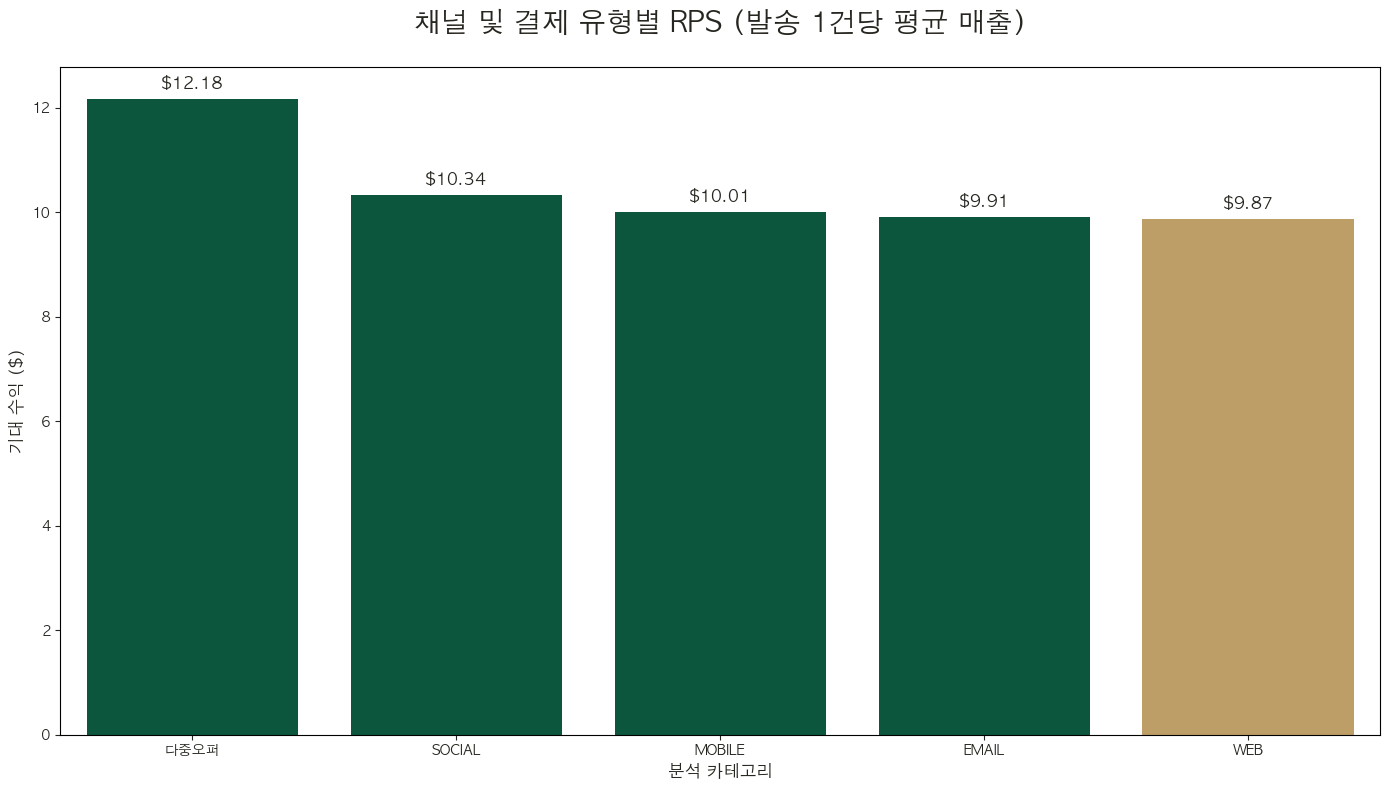

In [29]:
# 카테고리별 RPS 계산 (Revenue / Sent)

# 8종 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 매출액 집계
rev_by_label = transaction_df.groupby('final_label')['amount'].sum()
rps_6_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 발송(received) 건수
    ch_sent = master_df[(master_df['event'] == 'received') & 
                        (master_df['final_label'].isin(offer_8_labels)) & 
                        (master_df[ch] == 1)].shape[0]
    
    # 해당 채널을 포함하는 오퍼들의 총 매출액
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    ch_rev = rev_by_label[rev_by_label.index.isin(linked_offers)].sum()
    
    # RPS 계산
    ch_rps = ch_rev / ch_sent if ch_sent > 0 else 0
    rps_6_data.append({'category': ch.upper(), 'RPS': ch_rps})

# 다중오퍼 RPS 추가
multi_sent = master_df[(master_df['event'] == 'received') & (master_df['final_label'] == '다중오퍼')].shape[0]
multi_rev = rev_by_label.get('다중오퍼', 0)
multi_rps = multi_rev / multi_sent if multi_sent > 0 else 0
rps_6_data.append({'category': '다중오퍼', 'RPS': multi_rps})

df_rps_6 = pd.DataFrame(rps_6_data)

# 시각화 (스타벅스 테마)
plt.figure(figsize=(14, 8))

# 색상 설정 (채널: 그린, 다중: 골드, 일반: 회색)
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

# 시각적 효과를 위해 금액 순으로 정렬 (일반 결제는 0이므로 자동으로 뒤로 갑니다)
ax = sns.barplot(data=df_rps_6.sort_values('RPS', ascending=False), 
                 x='category', y='RPS', palette=colors)

plt.title('채널 및 결제 유형별 RPS (발송 1건당 평균 매출)', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('기대 수익 ($)', fontsize=12)
plt.xlabel('분석 카테고리', fontsize=12)

# 막대 위에 금액 표시 ($ + 소수점 둘째자리)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 8. 채널별 ARPU (인당 평균 결제액)

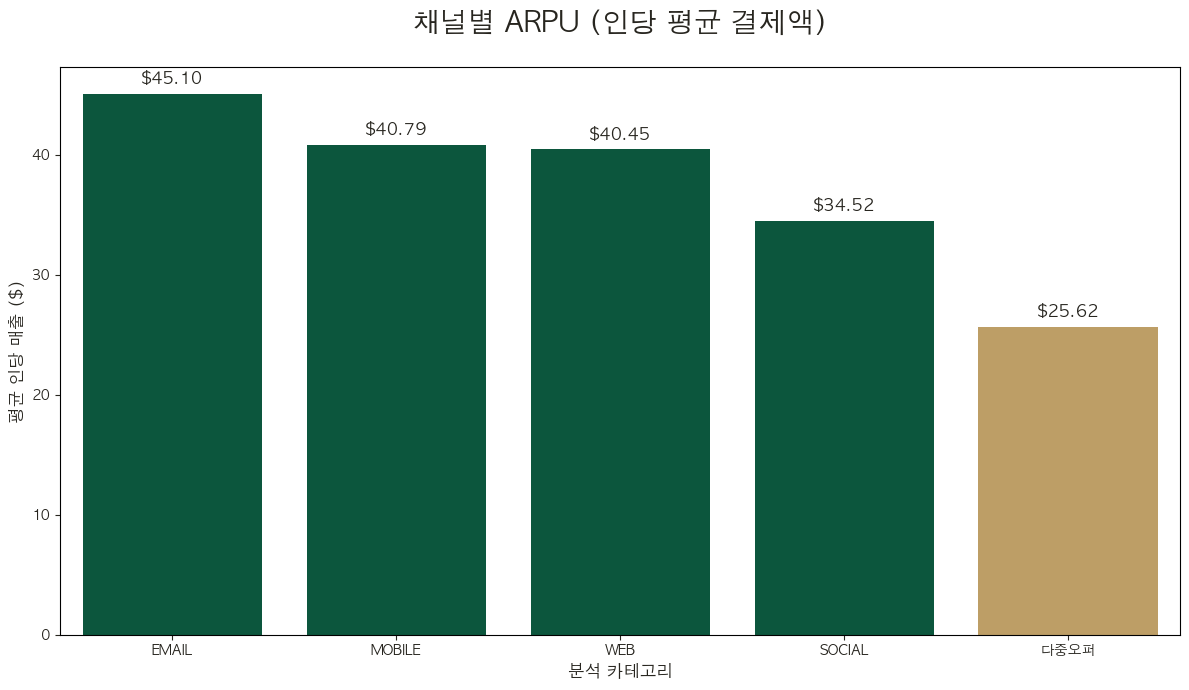

In [30]:
# 5개 카테고리 ARPU 계산 (인당 평균 결제액)

# 8종 개별 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
arpu_5_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    
    # 해당 채널 오퍼를 이용한 총 매출과 '순수 결제 인원수'
    ch_trans = transaction_df[transaction_df['final_label'].isin(linked_offers)]
    ch_rev = ch_trans['amount'].sum()
    ch_users = ch_trans['person'].nunique()
    
    # ARPU 계산
    ch_arpu = ch_rev / ch_users if ch_users > 0 else 0
    arpu_5_data.append({'category': ch.upper(), 'ARPU': ch_arpu})

# 다중오퍼 ARPU 추가
multi_trans = transaction_df[transaction_df['final_label'] == '다중오퍼']
multi_rev = multi_trans['amount'].sum()
multi_users = multi_trans['person'].nunique()
multi_arpu = multi_rev / multi_users if multi_users > 0 else 0

arpu_5_data.append({'category': '다중오퍼', 'ARPU': multi_arpu})

# 데이터프레임 변환
df_arpu_5 = pd.DataFrame(arpu_5_data)


# 시각화 
plt.figure(figsize=(12, 7))

# 금액 순으로 정렬하여 시각적 효과 극대화
df_plot_arpu = df_arpu_5.sort_values('ARPU', ascending=False)
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in df_plot_arpu['category']]

ax = sns.barplot(data=df_plot_arpu, x='category', y='ARPU', palette=colors)

plt.title('채널별 ARPU (인당 평균 결제액)', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('평균 인당 매출 ($)', fontsize=12)
plt.xlabel('분석 카테고리', fontsize=12)

# 막대 위에 금액 표시 ($ + 소수점 둘째자리)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 9. 채널별 고객 수

각 채널별로 값이 1인 행들에서 고유한 'person' 수를 집계

해당 채널 값이 1인 데이터만 필터링해서 고유 인원수 체크

In [31]:
df[['web','email','mobile','social']].head()

,web,email,mobile,social
0,1.0,1.0,1.0,0.0
1,1.0,1.0,1.0,0.0
2,1.0,1.0,1.0,0.0
3,1.0,1.0,1.0,0.0
4,0.0,1.0,1.0,1.0


채널별 고유 고객 수
  Channel  Unique_Customers
1   email             16994
2  mobile             16980
0     web             16916
3  social             16529


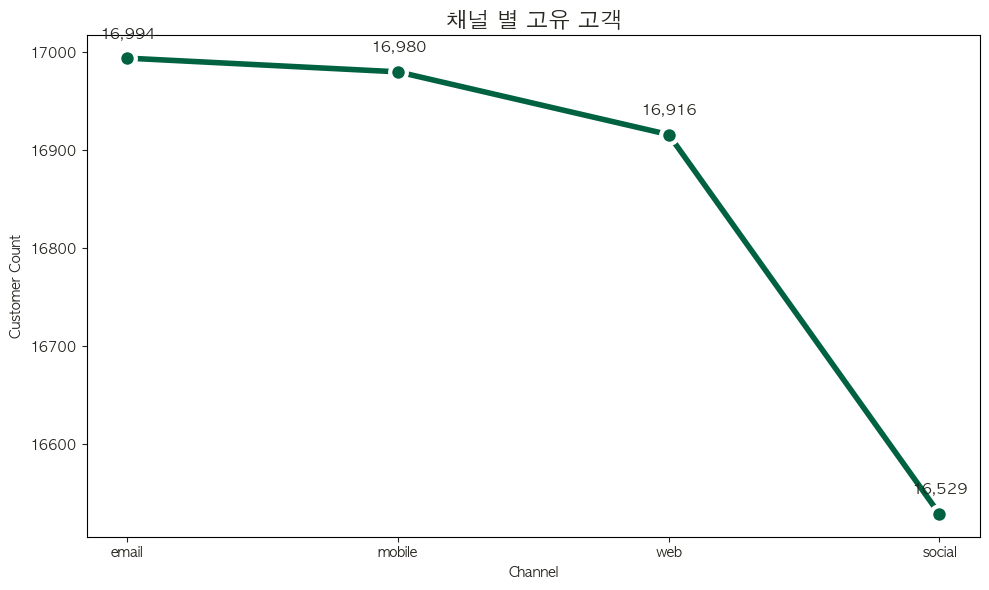

In [32]:
channel_customer_counts = {}
for ch in channels:
    unique_cnt = df[df[ch] == 1]['person'].nunique()
    channel_customer_counts[ch] = unique_cnt


channel_df = pd.DataFrame(list(channel_customer_counts.items()), columns=['Channel', 'Unique_Customers'])
channel_df = channel_df.sort_values(ascending=False,by='Unique_Customers')

print("채널별 고유 고객 수")
print(channel_df)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=channel_df, x='Channel', y='Unique_Customers', 
                marker='o', markersize=12, linewidth=4, 
                color=SB_GREEN,  # 선 색상
                markeredgewidth=3)

for i, val in enumerate(channel_df['Unique_Customers']):
    plt.text(i, val + 20, f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.title('채널 별 고유 고객', fontsize=16, fontweight='bold')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

# 4. Completed 관련

### completed된 거래 중 viewed 단계 여부

쿠폰 보고 완료: 27,534 건
쿠폰 안 보고 완료: 5,648 건


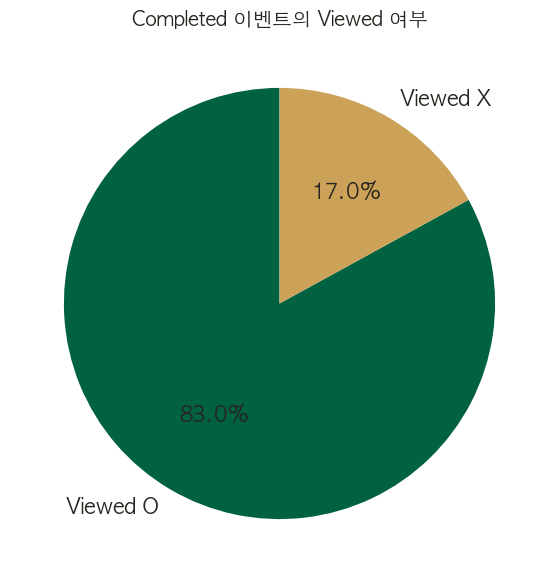

In [33]:
completed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'completed']
viewed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'viewed']

viewed_users = viewed_data[['person', 'offer_id', 'receive_seq']].drop_duplicates()
viewed_users['is_viewed'] = True

check_df = pd.merge(
    completed_data,
    viewed_users,
    on=['person', 'offer_id', 'receive_seq'],
    how='left'
)
check_df['is_viewed'] = check_df['is_viewed'].fillna(False)

true_roi = len(check_df[check_df['is_viewed'] == True])
accidental_roi = len(check_df[check_df['is_viewed'] == False])

print(f"쿠폰 보고 완료: {true_roi:,} 건")
print(f"쿠폰 안 보고 완료: {accidental_roi:,} 건")


labels = ['Viewed O', 'Viewed X']
sizes = [true_roi, accidental_roi]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=[SB_GREEN, SB_GOLD],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 15, 'fontweight': 'bold'})


plt.title('Completed 이벤트의 Viewed 여부', fontsize=14, fontweight='bold')
plt.show()

### 오퍼 효율 분석

x축 : 완료율

y축 : 발송 1건당 매출

점크기 : 총 매출 

색상 : 오퍼 유형

informatinal 제외

x축 : 완료율 (viewed -> completed)

In [34]:
df_core = df[df['offer_label'].notna()].copy()
df_core = df_core[~df_core['offer_label'].str.contains('informational', na=False)]

print(df_core['offer_label'].value_counts())

received_cnt = (
    df_core[df_core['event'] == 'received']
    .groupby('offer_label')['customer_id']
    .count()
)

viewed_cnt = (
    df_core[df_core['event'] == 'viewed']
    .groupby('offer_label')['customer_id']
    .count()
)

# 같은 고객이 같은 오퍼 인스턴스(receive_seq)를 여러 번 본 경우 1건만 남김
viewed_events = (
    df_core[df_core['event'] == 'viewed'][
        ['customer_id', 'offer_id', 'offer_label', 'receive_seq', 'time']
    ]
    .rename(columns={'time': 'viewed_time'})
    .drop_duplicates(subset=['customer_id', 'offer_id', 'receive_seq'])
)

completed_events = (
    df_core[df_core['event'] == 'completed'][
        ['customer_id', 'offer_id', 'offer_label', 'receive_seq', 'time']
    ]
    .rename(columns={'time': 'completed_time'})
)

# 같은 고객 + 같은 오퍼 인스턴스 기준으로 viewed와 completed 연결
true_comp_df = pd.merge(
    completed_events,
    viewed_events[['customer_id', 'offer_id', 'receive_seq', 'viewed_time']],
    on=['customer_id', 'offer_id', 'receive_seq'],
    how='left'
)

# viewed 이후 completed 된 경우만 true completion으로 인정
true_comp_df = true_comp_df[
    (true_comp_df['viewed_time'].notna()) &
    (true_comp_df['viewed_time'] <= true_comp_df['completed_time'])
]

true_completed_cnt = (
    true_comp_df.groupby('offer_label')['customer_id']
    .count()
)

print("\nViewed -> Completed 만족")
print(true_completed_cnt)

offer_label
discount_3    20189
discount_2    20095
bogo_4        19097
bogo_2        18192
bogo_1        18009
bogo_3        16151
discount_4    15714
discount_1    13671
Name: count, dtype: int64

Viewed -> Completed 만족
offer_label
bogo_1        2582
bogo_2        2739
bogo_3        2106
bogo_4        3514
discount_1    1312
discount_2    4357
discount_3    4610
discount_4    2107
Name: customer_id, dtype: int64


 y축 : 발송 1건당 매출 

In [35]:
transactions = df[df['event'] == 'transaction'][['customer_id', 'time', 'amount']]

true_completions_for_rev = true_comp_df[['customer_id', 'completed_time', 'offer_label']].rename(columns={'completed_time': 'time'})

# 오퍼 완료한 순간의 거래만 가져옴 (해찬님 코드 참고)
matched_sales = pd.merge(transactions, true_completions_for_rev, on=['customer_id', 'time'], how='inner')

# 오퍼별 총 매출 집계
revenue_df = matched_sales.groupby('offer_label').agg(
    total_offer_revenue=('amount', 'sum')
)

revenue_df

,total_offer_revenue
offer_label,
bogo_1,61508.30
bogo_2,65289.48
bogo_3,37422.05
bogo_4,70093.72
discount_1,34749.94
discount_2,74064.04
discount_3,82970.77
discount_4,42295.48


KPI 통합 

In [36]:
final_kpi_df = pd.DataFrame({
    'received_cnt': received_cnt,
    'viewed_cnt': viewed_cnt,
    'true_completed_cnt': true_completed_cnt
}).fillna(0).join(revenue_df).fillna(0)

final_kpi_df

,received_cnt,viewed_cnt,true_completed_cnt,total_offer_revenue
offer_label,,,,
bogo_1,7658,6716,2582,61508.30
bogo_2,7593,7298,2739,65289.48
bogo_3,7677,4171,2106,37422.05
bogo_4,7571,7264,3514,70093.72
discount_1,7668,2663,1312,34749.94
discount_2,7646,7337,4357,74064.04
discount_3,7597,7327,4610,82970.77
discount_4,7632,4118,2107,42295.48


X축 : 실제 완료율 = 실제 완료 수 / 총 발송 수 (여기서 실제란 Viewed -> Completed 과정을 거침)

Y축 : 발송 1건당 매출 = 총 오퍼 연계 매출 / 총 발송 수

In [37]:
final_kpi_df['true_completed_rate'] = (final_kpi_df['true_completed_cnt'] / final_kpi_df['received_cnt'] * 100).round(2)

final_kpi_df['revenue_per_send'] = (final_kpi_df['total_offer_revenue'] / final_kpi_df['received_cnt']).round(2)

그룹으로 묶어서 색상 구분

In [38]:
final_kpi_df = final_kpi_df.reset_index()
final_kpi_df['offer_type'] = final_kpi_df['offer_label'].apply(lambda x: 'bogo' if 'bogo' in x else 'discount')

final_kpi_df['received_cnt'] = final_kpi_df['received_cnt'].replace(0, np.nan)

산점도 그리기

| 요소 | 의미                   |
| -- | -------------------- |
| X축 | 완료율 (얼마나 잘 전환되었는지)     |
| Y축 | 발송당 매출 (얼마나 돈 잘 벌었는지) |
| 크기 | 총매출 (얼마나 크게 벌었는지)     |
| 색  | 오퍼 유형                |


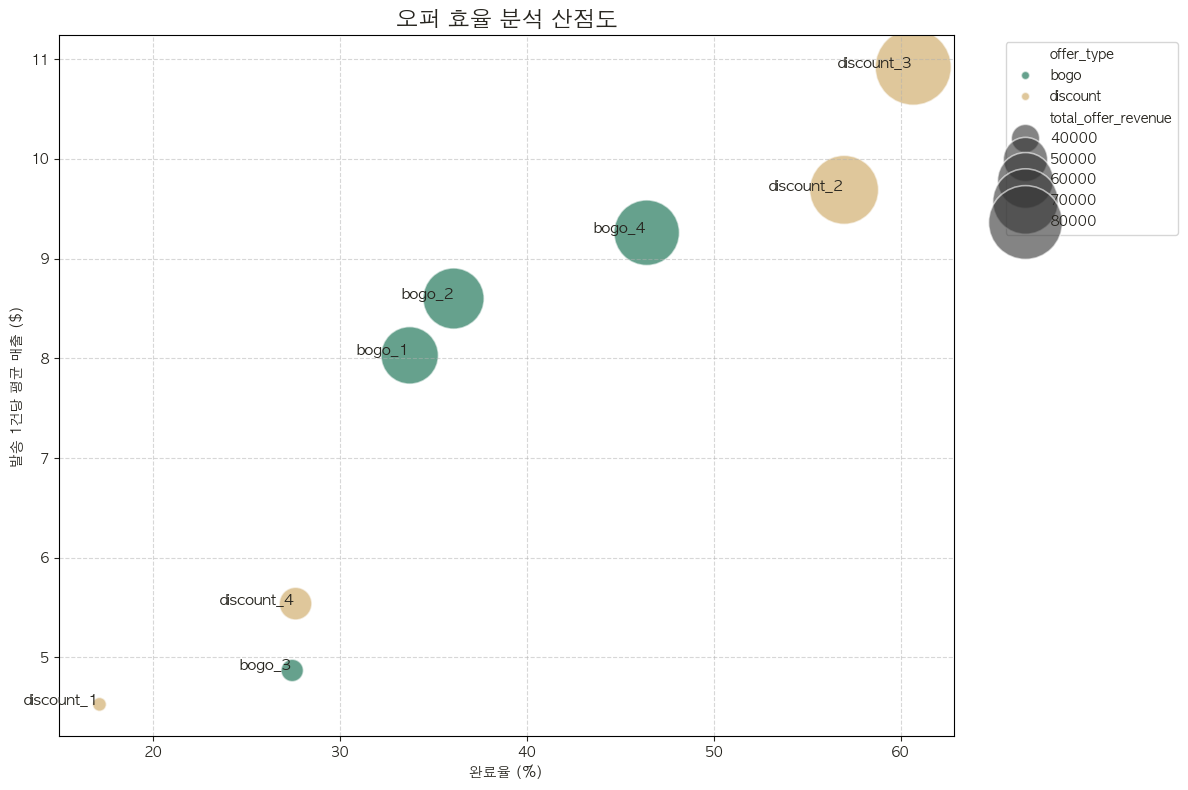

In [39]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_kpi_df,
    x='true_completed_rate', # 완료율
    y='revenue_per_send', # 발송 1건당 평균 매출
    size='total_offer_revenue', # 총 매출
    hue='offer_type',  # 색상 구분
    sizes=(100, 3000),
    alpha=0.6,
)

# 라벨 추가
for i in range(len(final_kpi_df)):
    plt.text(
        final_kpi_df['true_completed_rate'].iloc[i],
        final_kpi_df['revenue_per_send'].iloc[i],
        final_kpi_df['offer_label'].iloc[i],
        ha='right',
        fontsize=11,
        fontweight='bold',
        color=SB_BLACK
    )

plt.title('오퍼 효율 분석 산점도', fontsize=16, fontweight='bold')
plt.xlabel('완료율 (%)')
plt.ylabel('발송 1건당 평균 매출 ($)')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

### 알 수 있는 것

1. discount_3과 discount_2의 높은 완료율과 높은 원의 크기 (총 매출)

-> 고객들이 쉽게 참여하면서도 돈을 많이 쓰게 하는 최고의 오퍼

2. 중앙에 모여있는 bogo_1, bogo_2, bogo_4

-> 최고 1등은 아니지만 안정적인 성과를 보여줌

3. 하단에 있는 오퍼들 discount_1, discount_4, bogo_3

-> 완료율도 30% 이하이며 건당 매출도 5~6$로 낮음, 조건이 까다롭거나 보상이 별로?

4. 할인 쿠폰은 조건을 어떻게 짜느냐에 따라 큰 차이가 남

### 채널별 평균 소요 시간 (완료된 거래 기준)

In [40]:
completed_event = df[df['event'] == 'completed']
completed_event

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
1,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,1.0,NaN
7,0009655768c64bdeb2e877511632db8f,completed,414,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0,18,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,2,0,1.0,False
10,0009655768c64bdeb2e877511632db8f,completed,528,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,23,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,2,0,1.0,False
29,0011e0d4e6b944f998e987f904e8c1e5,completed,576,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,5.0,25,O,40.0,0011e0d4e6b944f998e987f904e8c1e5,2018-01-09,57000.0,0,0,5.0,20.0,10.0,1.0,1.0,0.0,0.0,discount_1,2,0,1.0,True
32,0011e0d4e6b944f998e987f904e8c1e5,completed,252,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,3.0,11,O,40.0,0011e0d4e6b944f998e987f904e8c1e5,2018-01-09,57000.0,0,0,3.0,7.0,7.0,1.0,1.0,1.0,1.0,discount_2,2,0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306109,ffff82501cea40309d5fdd7edcca4a07,completed,384,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,17,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,1.0,True
306112,ffff82501cea40309d5fdd7edcca4a07,completed,414,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,18,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,2.0,True
306114,ffff82501cea40309d5fdd7edcca4a07,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,3.0,False
306117,ffff82501cea40309d5fdd7edcca4a07,completed,504,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0,22,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,2,0,1.0,False


In [41]:
avg_time = {}

for ch in channels:
    channel_df = completed_event[completed_event[ch] == 1]
    
    total_time = channel_df['time'].sum()
    total_count = len(channel_df)
    
    avg_time[ch] = total_time / total_count if total_count > 0 else 0

avg_time_df = pd.DataFrame(list(avg_time.items()), columns=['channel', 'avg_time'])

print(avg_time_df)

  channel    avg_time
0     web  400.452026
1   email  399.641553
2  mobile  396.293345
3  social  392.196987


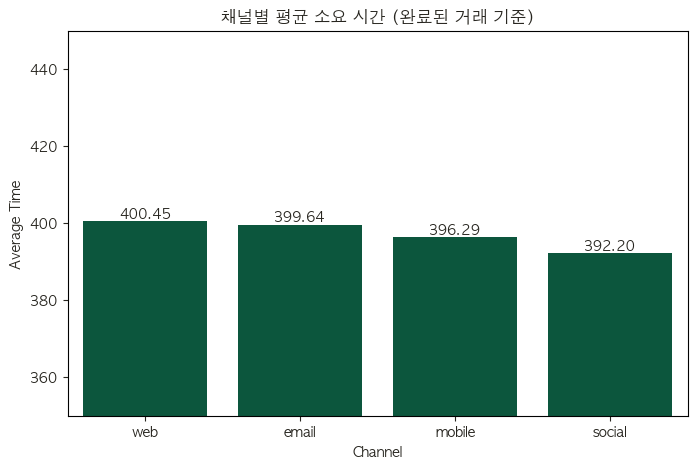

In [42]:
plt.figure(figsize=(8,5))

plt.xlabel('Channel')
plt.ylabel('Average Time')
plt.title('채널별 평균 소요 시간 (완료된 거래 기준)')

ax = sns.barplot(data=avg_time_df, x='channel', y='avg_time')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

# y축 범위 설정
ax.set_ylim(350, 450)

plt.show()

# 5. 오퍼 퍼널

> 퍼널은 3개로 분리

> **1) received → viewed → completed 3단계를 모두 거치는 오퍼에 대한 퍼널 (전략적 전환)**  
    - 대상: bogo, discount  
    - 핵심 KPI  
        - 열람율 = viewed / received  
        - 전략적 전환율 = viewed가 선행된 후의 completed / received  

> **2) received → completed 2단계만 거치는 오퍼에 대한 퍼널 (자발적/우연적 전환)**  
    - 대상: bogo, discount  
    - 여기서는 오퍼가 없어도 완료까지 수행하는 고객 군이므로 오퍼 낭비 대상이라고 생각  
          (굳이 오퍼 안해도 사먹으니까?)  
    - 핵심 KPI  
        - 낭비된 완료 수  
        - 낭비된 리워드 비율 = Viewed 없이 Completed 된 리워드 합계 / 전체 리워드 합계

> **3) informational 만 따로 뺀 퍼널**  
    - 대상: informational (received → viewed)  
    - 핵심 KPI  
        - viewed 이후 24시간 내에 transaction 발생 수  
        - viewed 이후 24시간 내 구매 전환율  
        - viewed 이후 24시간 내 평균 구매 금액  
        - viewed O vs viewed X 고객 세그먼트 분석  
        - 보상에 따른 매출 증대율 계산(오퍼를 완료한 사람들의 평균 결제액 - 정보 제공 후 24시간 내 매출 / 정보 제공 후 24시간 내 매출 )*100 ← duration * 24 시간 이내 발생한 결제를 분모로 잡으면 더 정확한 계산

### 오퍼 인스턴스 테이블

In [43]:
df['offer_type'] = df['offer_label'].str.split('_').str[0]
# customer_id, offer_id, time 기준으로 정렬
df = df.sort_values(['customer_id', 'offer_id', 'time']).reset_index(drop=True)

df.columns

Index(['person', 'event', 'time', 'offer_id', 'amount', 'bonus_reward',
       'time_days', 'gender', 'age', 'customer_id', 'became_member_on',
       'income', 'income_missing', 'age_missing', 'reward', 'difficulty',
       'duration', 'web', 'email', 'mobile', 'social', 'offer_label',
       'event_order', 'is_received', 'receive_seq', 'order_label',
       'offer_type'],
      dtype='str')

In [44]:
# 오퍼 인스턴스 테이블 만들기
# ---------------------------------------------------------
# 목적:
# - 같은 고객이 같은 offer_id를 여러 번 받을 수 있으므로 받은 1건 단위로 분석해야 함
# - 각 received 이벤트를 하나의 오퍼 인스턴스로 보고,
#   그 이후 유효기간(duration) 안에 viewed/completed가 있었는지 확인


# 발송(received) 이벤트만 추출
offer_received = df[df['event'] == 'received'].copy()

# 같은 고객이 같은 오퍼를 몇 번째 받았는지 순번 부여(receive_seq 컬럼 생성)
offer_received = offer_received.sort_values(['customer_id', 'offer_id', 'time']).copy()
offer_received['receive_seq'] = offer_received.groupby(['customer_id', 'offer_id']).cumcount() + 1

# 다음 동일 오퍼 수신 시점 계산
# - 같은 고객이 같은 offer_id를 또 받기 전까지만 현재 오퍼 인스턴스의 유효 범위로 본다
offer_received['next_received_time'] = offer_received.groupby(['customer_id', 'offer_id'])['time'].shift(-1)

# 원래 오퍼 만료 시점 = received_time + duration * 24시간
offer_received['offer_end_time'] = offer_received['time'] + offer_received['duration'] * 24

# 실제 분석 윈도우 종료 시점
# - 다음 오퍼를 다시 받기 전이 더 빠르면 거기까지
# - 아니면 원래 duration 종료 시점까지
offer_received['window_end_time'] = np.where(
    offer_received['next_received_time'].notna(),
    np.minimum(offer_received['offer_end_time'], offer_received['next_received_time']),
    offer_received['offer_end_time']
)

# 컬럼명 정리
offer_received = offer_received.rename(columns={'time': 'received_time'})

# 필요한 컬럼만 남김
offer_received = offer_received[
    [
        'customer_id', 'offer_id', 'offer_label', 'offer_type',
        'received_time', 'window_end_time', 'duration',
        'reward', 'difficulty',
        'web', 'email', 'mobile', 'social',
        'receive_seq'
    ]
].copy()

display(offer_received.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1
2,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1
4,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1
6,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1
9,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1


### 열람과 완료 이벤트를 위 오퍼 인스턴스에 붙이기

In [45]:
# 열람(viewed), 완료(completed) 이벤트 준비
offer_viewed = df[df['event'] == 'viewed'][['customer_id', 'offer_id', 'time']].copy()
offer_completed = df[df['event'] == 'completed'][['customer_id', 'offer_id', 'time', 'bonus_reward']].copy()

# 각 발송 건마다 열람 여부 붙이기
# ---------------------------------------------------------
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 열람 시점이 received_time 이후
# - 열람 시점이 window_end_time 이전
view_merge = offer_received.merge(
    offer_viewed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 안 본 경우도 분석해야 하므로 left join
    suffixes=('', '_view')
)

view_merge = view_merge[
    (view_merge['time'].isna()) |                                # 열람 기록이 아예 없거나(안 본 사람 계산)
    (
        (view_merge['time'] >= view_merge['received_time']) &    # 열람 시간이 오퍼를 받은 시점 이후이고,
        (view_merge['time'] <= view_merge['window_end_time'])    # 오퍼 유효기간 끝나는 시점 이전
    )
]

view_summary = (
    view_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        viewed=('time', lambda x: x.notna().any()),    # 유효한 열람 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_view_time=('time', 'min')                # 수신 건에 대해 가장 빠른 열람 시간을 저장
    )
)


# 각 발송 건마다 완료 여부 붙이기
# ---------------------------------------------------------
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 완료 시점이 received_time 이후
# - 완료 시점이 window_end_time 이전
complete_merge = offer_received.merge(
    offer_completed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 완료 안 한 경우도 분석해야 하므로 left join
    suffixes=('', '_complete')
)

complete_merge = complete_merge[
    (complete_merge['time'].isna()) |                                  # 완료 기록이 아예 없거나(완료 안 한 사람 계산)
    (
        (complete_merge['time'] >= complete_merge['received_time']) &  # 완료 시간이 오퍼를 받은 시점 이후이고,
        (complete_merge['time'] <= complete_merge['window_end_time'])  # 오퍼 유효기간 끝나는 시점 이전
    )
]

complete_summary = (
    complete_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        completed=('time', lambda x: x.notna().any()),    # 유효한 완료 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_complete_time=('time', 'min'),              # 수신 건에 대해 가장 빠른 완료 시간을 저장
        bonus_reward_sum=('bonus_reward', 'max')          # 수신 건에서 발생한 bonus_reward 최대값(오퍼 1번 완료 시 1번 보상이므로 합계 구할 필요 X)
    )
)


### 오퍼 인스턴스 테이블 완성

In [46]:
# 오퍼 인스턴스 테이블 완성
offer_instance = (
    offer_received
    .merge(view_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
    .merge(complete_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
)

# 결측 처리
offer_instance['viewed'] = offer_instance['viewed'].fillna(False)
offer_instance['completed'] = offer_instance['completed'].fillna(False)
offer_instance['bonus_reward_sum'] = offer_instance['bonus_reward_sum'].fillna(0)


# 전략적 완료 / 우연적 완료 분류
# ---------------------------------------------------------
# 전략적 완료(effective_completed):
# - completed == True
# - viewed == True
# - first_view_time <= first_complete_time
#
# 우연적 완료(accidental_completed):
# - completed 이긴 한데, 전략적 완료는 아닌 경우
offer_instance['effective_completed'] = (
    offer_instance['completed'] &
    offer_instance['viewed'] &
    (offer_instance['first_view_time'] <= offer_instance['first_complete_time'])
)

offer_instance['accidental_completed'] = (
    offer_instance['completed'] &
    (~offer_instance['effective_completed'])
)

display(offer_instance.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq,viewed,first_view_time,completed,first_complete_time,bonus_reward_sum,effective_completed,accidental_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1,False,NaN,True,576.0,2.0,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1,True,372.0,False,NaN,0.0,False,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1,True,192.0,False,NaN,0.0,False,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1,True,456.0,True,414.0,5.0,False,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1,True,540.0,True,528.0,2.0,False,True


## 전략적 전환 퍼널

#### bogo / discount

In [47]:
# 전략적 전환 퍼널 대상 추출
# - bogo, discount만 포함
# - informational은 제외
conv_offer = offer_instance[offer_instance['offer_type'].isin(['bogo', 'discount'])].copy()

# 단계별 건수
received_cnt = len(conv_offer)
viewed_cnt = conv_offer['viewed'].sum()
completed_cnt = conv_offer['completed'].sum()
effective_completed_cnt = conv_offer['effective_completed'].sum()
accidental_completed_cnt = conv_offer['accidental_completed'].sum()

# 핵심 KPI
view_rate = viewed_cnt / received_cnt if received_cnt > 0 else 0
strategic_conversion_rate = effective_completed_cnt / received_cnt if received_cnt > 0 else 0
view_to_effective_rate = effective_completed_cnt / viewed_cnt if viewed_cnt > 0 else 0

print("=" * 60)
print("[전략적 전환 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {received_cnt:,}건")
print(f"열람 수: {viewed_cnt:,}건")
print(f"완료 수(전체): {completed_cnt:,}건")
print(f"전략적 완료 수: {effective_completed_cnt:,}건")
print(f"우연적 완료 수: {accidental_completed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {view_rate:.2%}")
print(f"전략적 전환율 = 전략적 완료 / 발송: {strategic_conversion_rate:.2%}")
print(f"열람 후 전략적 완료율 = 전략적 완료 / 열람: {view_to_effective_rate:.2%}")

[전략적 전환 퍼널 KPI]
발송 수: 61,042건
열람 수: 46,685건
완료 수(전체): 33,163건
전략적 완료 수: 23,313건
우연적 완료 수: 9,850건
열람율 = 열람 / 발송: 76.48%
전략적 전환율 = 전략적 완료 / 발송: 38.19%
열람 후 전략적 완료율 = 전략적 완료 / 열람: 49.94%


#### 전략적 전환 퍼널 시각화

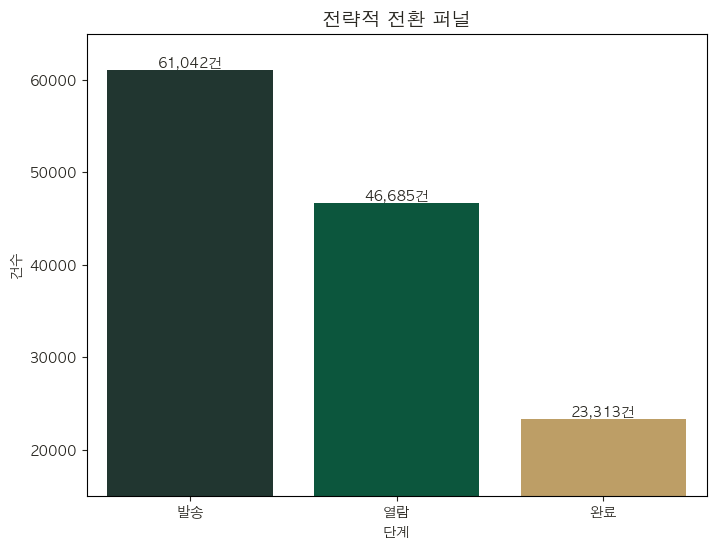

In [48]:
# 전략적 전환 퍼널 시각화
strategic_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람', '완료'],
    '건수': [received_cnt, viewed_cnt, effective_completed_cnt]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=strategic_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_DEEP_GREEN, SB_GREEN, SB_GOLD]
)

for i, v in enumerate(strategic_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('전략적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(15000, 65000)
plt.show()

## 우연적 전환 퍼널

#### bogo / discount

In [49]:
# 우연적 전환 KPI
# ---------------------------------------------------------
# 우연적 완료 = viewed 없이 completed 된 경우
# 리워드 낭비 비율 = Viewed 없이 Completed 된 reward 합 / 전체 completed 건의 reward 합
wasted_completed_cnt = accidental_completed_cnt

total_reward_paid = conv_offer.loc[conv_offer['completed'], 'reward'].sum()
wasted_reward_amt = conv_offer.loc[conv_offer['accidental_completed'], 'reward'].sum()
wasted_reward_rate = wasted_reward_amt / total_reward_paid if total_reward_paid > 0 else 0
wasted_reward_pct = wasted_reward_amt / wasted_completed_cnt if total_reward_paid > 0 else 0

print("=" * 60)
print("[우연적 전환 KPI]")
print("=" * 60)
print(f"낭비된 완료 수: {wasted_completed_cnt:,}건")
print(f"낭비된 리워드 금액: ${wasted_reward_amt:,.2f}")
print(f"낭비된 리워드 비율: {wasted_reward_rate:.2%}")
print(f"낭비된 리워드 평균 금액: ${wasted_reward_pct:.2f}")

[우연적 전환 KPI]
낭비된 완료 수: 9,850건
낭비된 리워드 금액: $48,287.00
낭비된 리워드 비율: 29.67%
낭비된 리워드 평균 금액: $4.90


#### 우연적 전환 퍼널 시각화

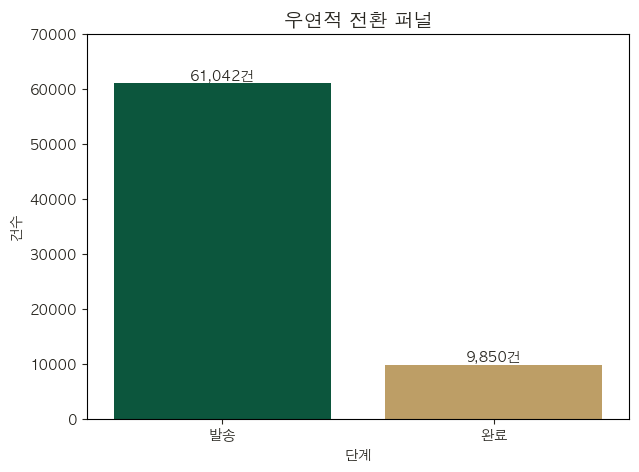

In [50]:
# 우연적 전환 퍼널 시각화
accidental_funnel_df = pd.DataFrame({
    '단계': ['발송', '완료'],
    '건수': [received_cnt, wasted_completed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=accidental_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(accidental_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('우연적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(0, 70000)
plt.show()

### informational 퍼널 및 24시간 내 구매 분석

#### informational 발송 → 열람 퍼널

In [51]:
# informational 오퍼만 추출
info_offer = offer_instance[offer_instance['offer_type'] == 'informational'].copy()

info_received_cnt = len(info_offer)
info_viewed_cnt = info_offer['viewed'].sum()
info_view_rate = info_viewed_cnt / info_received_cnt if info_received_cnt > 0 else 0

print("=" * 60)
print("[Informational 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {info_received_cnt:,}건")
print(f"열람 수: {info_viewed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {info_view_rate:.2%}")

[Informational 퍼널 KPI]
발송 수: 15,235건
열람 수: 9,952건
열람율 = 열람 / 발송: 65.32%


> 열람율 = 65.32% → 단순 정보성 오퍼이지만 열람 비율 높은 편

### informational 퍼널 시각화

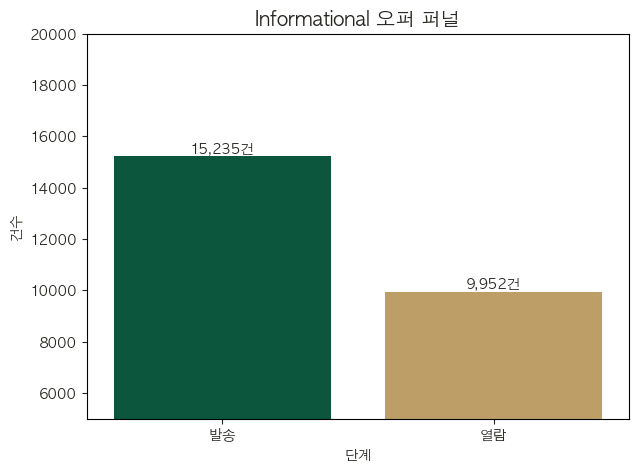

In [52]:
# informational 퍼널 시각화
info_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람'],
    '건수': [info_received_cnt, info_viewed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=info_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('Informational 오퍼 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(5000, 20000)
plt.show()

#### 열람 후 24시간 내 구매 분석

In [53]:
# informational 열람 이벤트만 추출
info_view_events = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
][['customer_id', 'offer_id', 'time']].copy()

info_view_events = info_view_events.rename(columns={'time': 'view_time'})

# transaction 데이터는 customer_id, time, amount만 사용
transactions_small = transaction_df[['customer_id', 'time', 'amount']].copy()
transactions_small = transactions_small.rename(columns={'time': 'txn_time'})


# 열람 이벤트와 구매 이력 연결
# ---------------------------------------------------------
# 같은 고객의 transaction을 모두 붙인 후,
# viewed 후 24시간 이내인지 여부를 체크
info_txn_merge = info_view_events.merge(
    transactions_small,
    on='customer_id',
    how='left'
)

info_txn_merge['txn_within_24h'] = (
    (info_txn_merge['txn_time'] >= info_txn_merge['view_time']) &
    (info_txn_merge['txn_time'] <= info_txn_merge['view_time'] + 24)
)


# viewed 1건 단위로 요약
# ---------------------------------------------------------
# viewed 1건마다:
# - 24시간 내 구매가 있었는지
# - 24시간 내 구매금액 합계가 얼마인지
info_24h_summary = (
    info_txn_merge.groupby(['customer_id', 'offer_id', 'view_time'], as_index=False)
    .agg(
        purchased_24h=('txn_within_24h', 'any'),
        revenue_24h=('amount', lambda x: x[info_txn_merge.loc[x.index, 'txn_within_24h']].sum())
    )
)

display(info_24h_summary.head())

,customer_id,offer_id,view_time,purchased_24h,revenue_24h
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,False,0.0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,False,0.0
2,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,6,False,0.0
3,0011e0d4e6b944f998e987f904e8c1e5,5a8bc65990b245e5a138643cd4eb9837,354,False,0.0
4,0020c2b971eb4e9188eac86d93036a77,5a8bc65990b245e5a138643cd4eb9837,660,False,0.0


In [54]:
info_24h_summary[info_24h_summary['purchased_24h'] == True].describe()

,view_time,revenue_24h
count,4254.000000,4254.000000
mean,364.005642,16.780646
std,192.295857,30.895251
min,0.000000,0.050000
25%,192.000000,4.352500
50%,408.000000,12.490000
75%,520.500000,22.355000
max,714.000000,725.990000


In [55]:
# informational 24시간 KPI 계산
info_24h_purchase_cnt = info_24h_summary['purchased_24h'].sum()
info_24h_conversion_rate = info_24h_purchase_cnt / info_viewed_cnt
info_24h_total_revenue = info_24h_summary['revenue_24h'].sum()
info_24h_avg_revenue = info_24h_total_revenue / info_24h_purchase_cnt

print("=" * 60)
print("[Informational 24시간 내 구매 KPI]")
print("=" * 60)
print(f"열람 후 24시간 내 transaction 발생 수: {info_24h_purchase_cnt:,}건")
print(f"열람 후 24시간 내 구매 전환율: {info_24h_conversion_rate:.2%}")
print(f"열람 후 24시간 내 총 구매 금액: ${info_24h_total_revenue:,.2f}")
print(f"열람 후 24시간 내 평균 구매 금액: ${info_24h_avg_revenue:,.2f}")

[Informational 24시간 내 구매 KPI]
열람 후 24시간 내 transaction 발생 수: 4,254건
열람 후 24시간 내 구매 전환율: 42.75%
열람 후 24시간 내 총 구매 금액: $71,384.87
열람 후 24시간 내 평균 구매 금액: $16.78


> 열람 후 24시간 내 구매 전환율 = 42.75%  
→ 단순 정보 제공이지만 구매 전환율이 꽤 나와서 의미 없는 오퍼는 아니다?  
→ 그렇지만 인과관계는 아님

#### informational 본 사람 vs 안 본 사람

> 본 사람: informational viewed 경험이 1번 이상 있는 고객  
안 본 사람: informational viewed 경험이 없는 고객

In [56]:
# 고객별 총 구매금액 테이블 만들기
customer_stats = (
    transactions.groupby('customer_id')['amount']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
    .rename(columns={
        'sum': 'total_spend',
        'count': 'purchase_cnt',
        'mean': 'aov_customer'
    })
)

# 전체 고객을 기준으로 0원 구매 고객도 포함하기 위해
# customer_master를 만들어 left join 한 뒤 결측을 0으로 채워준다
customer_master = pd.DataFrame({'customer_id': df['customer_id'].unique()})

customer_stats = customer_master.merge(customer_stats, on='customer_id', how='left')
customer_stats[['total_spend', 'purchase_cnt', 'aov_customer']] = customer_stats[
    ['total_spend', 'purchase_cnt', 'aov_customer']
].fillna(0)


# informational 열람 경험 고객 표시
info_view_customer = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
]['customer_id'].unique()

customer_stats['info_viewed_flag'] = customer_stats['customer_id'].isin(info_view_customer)

# 그룹별 평균 비교
info_view_compare = (
    customer_stats.groupby('info_viewed_flag', as_index=False)
    .agg(
        고객수=('customer_id', 'nunique'),
        평균총구매금액=('total_spend', 'mean'),
        평균구매횟수=('purchase_cnt', 'mean'),
        평균객단가=('aov_customer', 'mean')
    )
)

info_view_compare['info_viewed_flag'] = info_view_compare['info_viewed_flag'].map({
    True: 'informational 본 사람',
    False: 'informational 안 본 사람'
})

display(info_view_compare)

,info_viewed_flag,고객수,평균총구매금액,평균구매횟수,평균객단가
0,informational 안 본 사람,8749,103.655199,8.237627,13.142103
1,informational 본 사람,8251,105.268771,8.105927,13.551229


> informational 본 사람이 구매횟수는 좀 낮지만 구매 금액 & 객단가 약간 높음

#### informational 본 사람 vs 안 본 사람 시각화

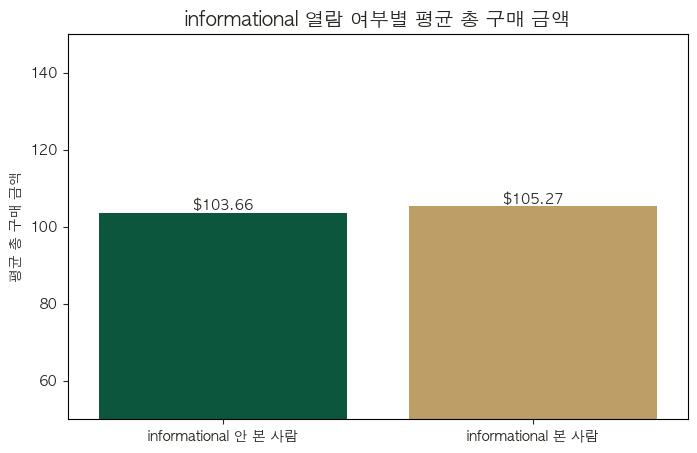

In [57]:
# informational 본 사람 vs 안 본 사람 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=info_view_compare,
    x='info_viewed_flag',
    y='평균총구매금액',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_view_compare['평균총구매금액']):
    ax.text(i, v, f"${v:,.2f}", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('informational 열람 여부별 평균 총 구매 금액', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('평균 총 구매 금액')
plt.ylim(50, 150)
plt.show()

### (bogo & discount) vs informational 매출 비교

In [58]:
# =========================================================
# (단위 불일치: 24시간 누적 평균 vs 1회 결제 평균)
# =========================================================
# # 완료 고객의 평균 결제액
# # 여기서는 bogo, discount completed 고객군(단일 + multi)의 평균 총 구매금액을 사용
# transaction_only = pd.read_csv("../../Data/transactions_260325.csv")
# 
# # reward completed와 연결된 거래
# completed_tx = transaction_only[
#     transaction_only['tx_offer_type'].isin(['bogo', 'discount', 'multi'])
# ].copy()
# 
# # 일반 거래
# normal_tx = transaction_only[
#     transaction_only['tx_offer_type'] == 'normal'
# ].copy()
# 
# completed_customer_avg_spend = completed_tx['amount'].mean()
# normal_customer_avg_spend = normal_tx['amount'].mean()
# 
# # informational 열람 후 24시간 내 평균 매출
# # info_24h_avg_revenue = info_24h_total_revenue / info_24h_purchase_cnt
# 
# # 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율
# # (완료 고객 평균 결제액 - informational 열람 후 24시간 평균 매출) / informational 열람 후 24시간 평균 매출 * 100
# revenue_lift_rate = (
#     (completed_customer_avg_spend - info_24h_avg_revenue) / info_24h_avg_revenue * 100
#     if info_24h_avg_revenue > 0 else np.nan
# )
# 
# print("=" * 60)
# print("[기존] 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율")
# print("=" * 60)
# print(f"completed 거래 고객 평균 결제액: ${completed_customer_avg_spend:,.2f}")
# print(f"일반 거래 고객 평균 결제액: ${normal_customer_avg_spend:,.2f}")
# print(f"informational 열람 후 24시간 평균 매출: ${info_24h_avg_revenue:,.2f}")
# print(f"정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율: {revenue_lift_rate:,.2f}%\n")

# =============================================================
# [기존 결과] [정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율]
# =============================================================
# completed 거래 고객 평균 결제액: $20.14
# 일반 거래 고객 평균 결제액: $10.70
# informational 열람 후 24시간 평균 매출: $16.78
# 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율: 20.02%


# =========================================================
# 모든 기준을 '건당 1회 평균 결제액(AOV)'으로 통일
# =========================================================

# BOGO, Discount 완료(사용) 거래 및 일반 거래 건당 평균 결제액
completed_tx = transaction_df[
    transaction_df['tx_offer_type'].isin(['bogo', 'discount', 'multi'])
].copy()

normal_tx = transaction_df[
    transaction_df['tx_offer_type'] == 'normal'
].copy()

completed_tx_aov = completed_tx['amount'].mean()
normal_tx_aov = normal_tx['amount'].mean()


# Informational 열람 후 24시간 내 발생한 거래들의 건당 평균 결제액(AOV) 구하기
# info_txn_merge 데이터프레임에서 실제 24시간 내 발생한 거래만 필터링
valid_info_txns = info_txn_merge[info_txn_merge['txn_within_24h'] == True].copy()

# 하나의 영수증(결제)이 여러 번의 열람 이벤트에 중복 카운트되는 것을 방지
unique_info_txns = valid_info_txns.drop_duplicates(subset=['customer_id', 'txn_time'])

# 인포메이션 오퍼의 영향을 받은 1회 결제당 평균 금액
info_24h_tx_aov = unique_info_txns['amount'].mean()


# 새로운 매출 증대율 계산
new_revenue_lift_rate = (
    (completed_tx_aov - info_24h_tx_aov) / info_24h_tx_aov * 100
    if info_24h_tx_aov > 0 else np.nan
)

print("=" * 60)
print("오퍼 유형별 건당 객단가(AOV) 및 매출 증대율")
print("=" * 60)
print(f"일반 거래(normal) 평균 객단가: ${normal_tx_aov:,.2f}")
print(f"informational 열람 후 24시간 내 거래 평균 객단가: ${info_24h_tx_aov:,.2f}")
print(f"bogo/discount 완료(사용) 거래 평균 객단가: ${completed_tx_aov:,.2f}")
print("-" * 60)
print(f"정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: {new_revenue_lift_rate:,.2f}%")

# =========================================================
# KPI DataFrame 업데이트 부분
# =========================================================
# info_kpi_df도 수정된 변수명에 맞게 업데이트 (선택 사항)
# info_kpi_df.loc[info_kpi_df['지표'] == '열람 후 24시간 내 평균 구매 금액', '값'] = round(info_24h_tx_aov, 2)
# info_kpi_df.loc[info_kpi_df['지표'] == '정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율', '값'] = round(new_revenue_lift_rate, 2) if pd.notna(new_revenue_lift_rate) else np.nan

오퍼 유형별 건당 객단가(AOV) 및 매출 증대율
일반 거래(normal) 평균 객단가: $10.70
informational 열람 후 24시간 내 거래 평균 객단가: $12.95
bogo/discount 완료(사용) 거래 평균 객단가: $20.14
------------------------------------------------------------
정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: 55.48%


### informational KPI

In [59]:
# informational KPI 표 정리
info_kpi_df = pd.DataFrame({
    '지표': [
        '발송 수',
        '열람 수',
        '열람율',
        '열람 후 24시간 내 구매가 있었던 열람 수',
        '열람 후 24시간 내 구매 전환율',
        '열람 후 24시간 내 평균 구매 금액',
        'bogo/discount 완료(사용) 거래 평균 객단가',
        '정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율'
    ],
    '값': [
        info_received_cnt,
        info_viewed_cnt,
        round(info_view_rate * 100, 2),
        int(info_24h_purchase_cnt),
        round(info_24h_conversion_rate * 100, 2),
        round(info_24h_tx_aov, 2),
        round(completed_tx_aov, 2),
        round(new_revenue_lift_rate, 2) if pd.notna(new_revenue_lift_rate) else np.nan
    ]
})

display(info_kpi_df)

,지표,값
0,발송 수,15235.00
1,열람 수,9952.00
2,열람율,65.32
3,열람 후 24시간 내 구매가 있었던 열람 수,4254.00
4,열람 후 24시간 내 구매 전환율,42.75
5,열람 후 24시간 내 평균 구매 금액,12.95
6,bogo/discount 완료(사용) 거래 평균 객단가,20.14
7,정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율,55.48


### 요약

In [60]:
# 요약 표
summary_df = pd.DataFrame({
    '구분': [
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        'Informational',
        'Informational',
        'Informational'
    ],
    '지표': [
        '발송 수',
        '열람율',
        '전략적 전환율',
        '낭비된 완료 수',
        '낭비된 리워드 금액',
        '낭비된 리워드 비율',
        '발송 수',
        '열람율',
        '24시간 내 구매 전환율'
    ],
    '값': [
        received_cnt,
        round(view_rate * 100, 2),
        round(strategic_conversion_rate * 100, 2),
        wasted_completed_cnt,
        round(wasted_reward_amt, 2),
        round(wasted_reward_rate * 100, 2),
        info_received_cnt,
        round(info_view_rate * 100, 2),
        round(info_24h_conversion_rate * 100, 2)
    ]
})

display(summary_df)

,구분,지표,값
0,전략적 전환 퍼널,발송 수,61042.00
1,전략적 전환 퍼널,열람율,76.48
2,전략적 전환 퍼널,전략적 전환율,38.19
3,우연적 전환 퍼널,낭비된 완료 수,9850.00
4,우연적 전환 퍼널,낭비된 리워드 금액,48287.00
5,우연적 전환 퍼널,낭비된 리워드 비율,29.67
6,Informational,발송 수,15235.00
7,Informational,열람율,65.32
8,Informational,24시간 내 구매 전환율,42.75


### 고객 세그먼트 분석

In [61]:
# 고객 기본 정보 추출
customers = df[['customer_id', 'age', 'gender', 'income', 'became_member_on']].drop_duplicates()
customers['became_member_on']  = pd.to_datetime(customers['became_member_on'])
customers['membership_years']  = (
    (pd.to_datetime('2018-07-31') - customers['became_member_on']).dt.days // 365
)

# 연령대 그룹화
customers['age_group'] = pd.cut(
    customers.loc[customers['age'] != 118, 'age'],
    bins=AGE_BINS, labels=AGE_LABELS, right=True
)

# 소득 구간 그룹화
customers['income_group'] = pd.cut(
    customers['income'], bins=INCOME_BINS, labels=INCOME_LABELS, right=False
)
customers['income_group'] = customers['income_group'].cat.add_categories('Unknown').fillna('Unknown')

# 성별 매핑
customers['gender_mapped'] = (
    customers['gender'].fillna('Unknown')
    .map({'M': '남성', 'F': '여성', 'O': 'Other', 'Unknown': 'Unknown'})
)

# 가입 연차 그룹화
customers['tenure_group'] = customers['membership_years'].map(
    {0: '1년 미만', 1: '1~2년', 2: '2~3년', 3: '3~4년', 4: '4~5년', 5: '5년 이상'}
)

# VIP 정의: 구매 이력 있는 고객 상위 20%
monetary = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['amount'].sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
)
customers = pd.merge(customers, monetary, on='customer_id', how='left')
customers['total_amount'] = customers['total_amount'].fillna(0)

threshold = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.80)
customers['is_vip']       = customers['total_amount'] >= threshold
customers['customer_type'] = np.where(customers['is_vip'], 'VIP 고객', '일반 고객')

actual_vip_pct = customers['is_vip'].mean() * 100
print(f"VIP 기준 결제액  : ${threshold:.2f}")
print(f"실제 VIP 비중    : {actual_vip_pct:.1f}%  (비구매 포함 전체 대비)")

# 구매력 등급
q75 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.75)
q25 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.25)

def assign_spending_tier(spent):
    if spent == 0:       return '비구매'
    elif spent >= q75:   return '고매출'
    elif spent <= q25:   return '저매출'
    else:                return '일반매출'

customers['spending_tier'] = customers['total_amount'].apply(assign_spending_tier)

# 오퍼 선호도(마케팅)
offer_events    = df[df['event'].isin(['viewed', 'completed'])].copy()
preferred_offer = (
    offer_events.groupby(['customer_id', 'offer_type']).size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['customer_id'], keep='first')
    .rename(columns={'offer_type': 'preferred_offer'})[['customer_id', 'preferred_offer']]
)
customers = pd.merge(customers, preferred_offer, on='customer_id', how='left')
customers['preferred_offer'] = customers['preferred_offer'].fillna('반응없음')

# 정보성 오퍼 열람 여부
info_viewers = df[(df['offer_type'] == 'informational') & (df['event'] == 'viewed')]['customer_id'].unique()
customers['info_viewer'] = customers['customer_id'].isin(info_viewers)

# 최근 방문일
last_visit = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['time_days'].max()
    .reset_index()
    .rename(columns={'time_days': 'last_visit_day'})
)
customers = pd.merge(customers, last_visit, on='customer_id', how='left')
customers['days_since_last_visit'] = df['time_days'].max() - customers['last_visit_day']

customers.info()

VIP 기준 결제액  : $170.65
실제 VIP 비중    : 19.5%  (비구매 포함 전체 대비)
<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            17000 non-null  str           
 1   age                    14825 non-null  float64       
 2   gender                 17000 non-null  str           
 3   income                 14825 non-null  float64       
 4   became_member_on       17000 non-null  datetime64[us]
 5   membership_years       17000 non-null  int64         
 6   age_group              14825 non-null  category      
 7   income_group           17000 non-null  category      
 8   gender_mapped          17000 non-null  str           
 9   tenure_group           17000 non-null  str           
 10  total_amount           17000 non-null  float64       
 11  is_vip                 17000 non-null  bool          
 12  customer_typ

## 기초 통계 및 분석

### ARPU 및 채널별 도달률

In [62]:
total_customers = len(customers)
total_revenue   = customers['total_amount'].sum()
arpu            = total_revenue / total_customers

vip_cust     = customers[customers['is_vip']]
general_cust = customers[~customers['is_vip']]

print("=" * 60)
print(f"총 고유 고객 수  : {total_customers:,}명")
print(f"총 발생 매출     : ${total_revenue:,.2f}")
print(f"전체 평균 ARPU   : ${arpu:.2f}")
print("-" * 60)
print("[세그먼트별 ARPU 비교]")
print(f"VIP 고객 ARPU    : ${(vip_cust['total_amount'].sum() / len(vip_cust)):.2f} (고객 수: {len(vip_cust):,}명)")
print(f"일반 고객 ARPU   : ${(general_cust['total_amount'].sum() / len(general_cust)):.2f} (고객 수: {len(general_cust):,}명)")
print("=" * 60)

channels = ['web', 'email', 'mobile', 'social']
print("\n채널별 순수 도달 고객 수 (event: 'received')")
for ch in channels:
    unique_users = df[(df[ch] == 1) & (df['event'] == 'received')]['customer_id'].nunique()
    print(f"  {ch.upper():8s}: {unique_users:,}명")

총 고유 고객 수  : 17,000명
총 발생 매출     : $1,775,451.97
전체 평균 ARPU   : $104.44
------------------------------------------------------------
[세그먼트별 ARPU 비교]
VIP 고객 ARPU    : $285.82 (고객 수: 3,316명)
일반 고객 ARPU   : $60.49 (고객 수: 13,684명)

채널별 순수 도달 고객 수 (event: 'received')


  WEB     : 16,916명
  EMAIL   : 16,994명
  MOBILE  : 16,980명
  SOCIAL  : 16,529명


### 오퍼 유형별 퍼널 전환율

In [63]:
offer_types = ['bogo', 'discount', 'informational']

print("=" * 60)
print("[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]")
for offer_type in offer_types:
    offer_df = df[df['offer_type'] == offer_type]

    received  = offer_df[offer_df['event'] == 'received' ]['customer_id'].nunique()
    viewed    = offer_df[offer_df['event'] == 'viewed'   ]['customer_id'].nunique()
    completed = offer_df[offer_df['event'] == 'completed']['customer_id'].nunique()

    view_rate     = (viewed    / received * 100) if received > 0 else 0
    complete_rate = (completed / viewed   * 100) if viewed   > 0 else 0

    print(f"\n[{offer_type.upper()}]")
    print(f"  발송 {received:,}명 → 열람 {viewed:,}명 → 완료 {completed:,}명")
    print(f"  발송→열람 전환율 : {view_rate:.2f}%")
    if offer_type != 'informational':
        print(f"  열람→완료 전환율 : {complete_rate:.2f}%")

# 퍼널 소요 시간 분석
views     = df[df['event'] == 'viewed'   ][['customer_id','offer_id','time_days','offer_type']].rename(columns={'time_days':'view_day'})
completes = df[df['event'] == 'completed'][['customer_id','offer_id','time_days']              ].rename(columns={'time_days':'complete_day'})

funnel_time = pd.merge(views, completes, on=['customer_id','offer_id'], how='inner')
funnel_time = funnel_time[funnel_time['complete_day'] >= funnel_time['view_day']]
funnel_time['days_to_complete'] = funnel_time['complete_day'] - funnel_time['view_day']

funnel_time = (
    funnel_time
    .sort_values(['customer_id','offer_id','view_day','days_to_complete'])
    .drop_duplicates(subset=['customer_id','offer_id','view_day'],     keep='first')
    .drop_duplicates(subset=['customer_id','offer_id','complete_day'], keep='first')
)

print("\n" + "=" * 60)
print(f"전체 평균 열람→구매 소요 시간 : {funnel_time['days_to_complete'].mean():.2f}일")


[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]

[BOGO]
  발송 14,992명 → 열람 14,008명 → 완료 9,263명
  발송→열람 전환율 : 93.44%
  열람→완료 전환율 : 66.13%

[DISCOUNT]
  발송 14,945명 → 열람 12,676명 → 완료 10,289명
  발송→열람 전환율 : 84.82%
  열람→완료 전환율 : 81.17%

[INFORMATIONAL]
  발송 10,547명 → 열람 8,251명 → 완료 0명
  발송→열람 전환율 : 78.23%

전체 평균 열람→구매 소요 시간 : 2.26일


### 시각화

#### 기본 인구통계 종합 분포

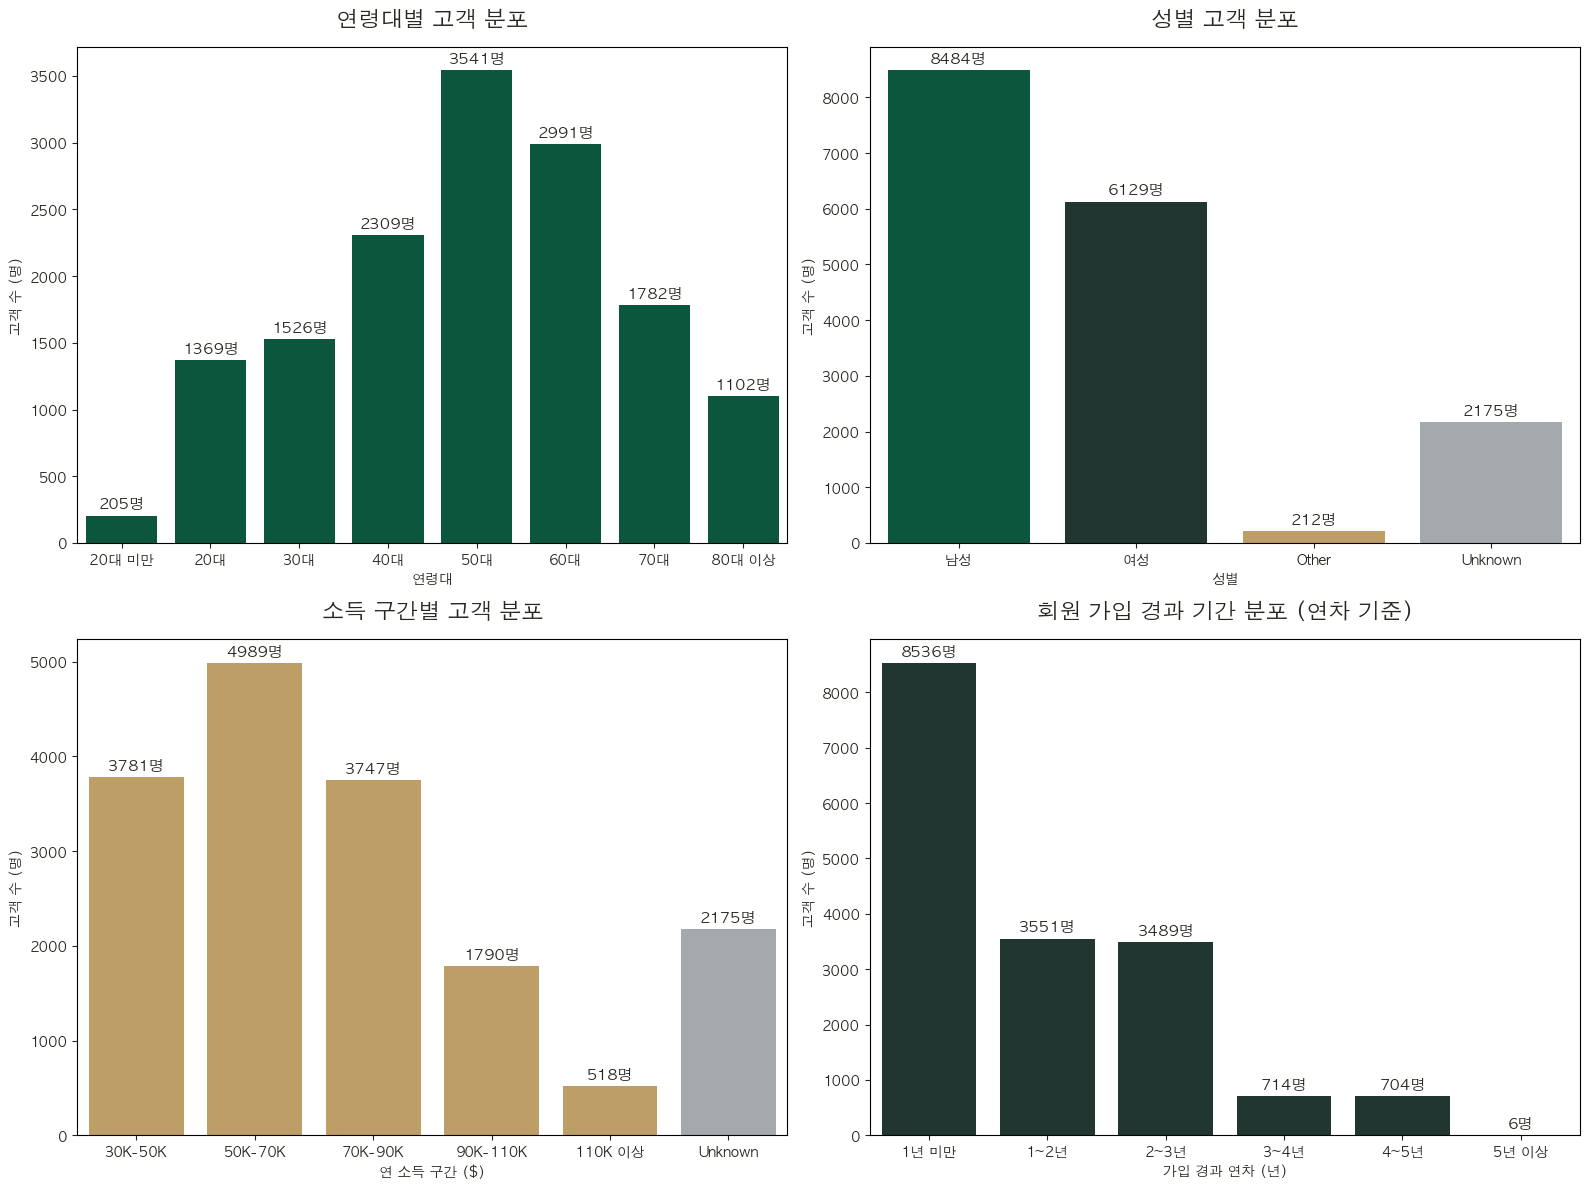

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 연령대별 고객 분포
ax1 = sns.countplot(data=customers, x='age_group', color=SB_GREEN,
                    ax=axes[0, 0], order=AGE_LABELS)
axes[0, 0].set_title('연령대별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('연령대')
axes[0, 0].set_ylabel('고객 수 (명)')
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 성별 고객 분포
ax2 = sns.countplot(data=customers, x='gender_mapped',
                    palette=[SB_GREEN, SB_DEEP_GREEN, SB_GOLD, SB_GREY],
                    ax=axes[0, 1], order=GENDER_ORDER)
axes[0, 1].set_title('성별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('성별')
axes[0, 1].set_ylabel('고객 수 (명)')
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 소득 구간별 고객 분포
ax3 = sns.countplot(data=customers, x='income_group',
                    palette=[SB_GOLD] * 5 + [SB_GREY],
                    ax=axes[1, 0], order=INCOME_ORDER)
axes[1, 0].set_title('소득 구간별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('연 소득 구간 ($)')
axes[1, 0].set_ylabel('고객 수 (명)')
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 회원 가입 경과 기간 분포
ax4 = sns.countplot(data=customers, x='tenure_group', color=SB_DEEP_GREEN,
                    ax=axes[1, 1], order=TENURE_ORDER)
axes[1, 1].set_title('회원 가입 경과 기간 분포 (연차 기준)', fontsize=16, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('가입 경과 연차 (년)')
axes[1, 1].set_ylabel('고객 수 (명)')
for c in ax4.containers:
    ax4.bar_label(c, fmt='%d명', padding=3, fontsize=11)

plt.tight_layout()
plt.show()


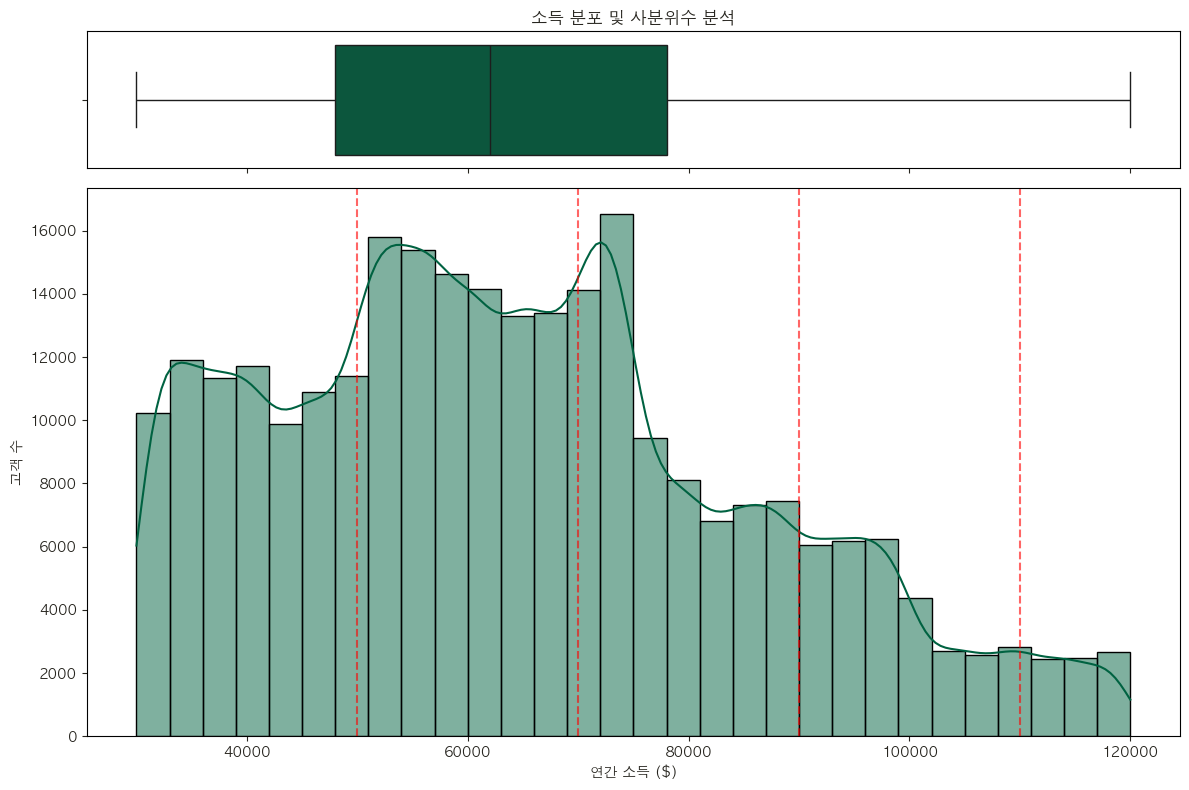

In [65]:
fig, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(12, 8)
)

sns.boxplot(x=df['income'].dropna(), ax=ax_box, color=SB_GREEN)
ax_box.set(title='소득 분포 및 사분위수 분석', xlabel='')

sns.histplot(df['income'].dropna(), kde=True, ax=ax_hist, color=SB_GREEN, bins=30)
ax_hist.set(xlabel='연간 소득 ($)', ylabel='고객 수')

for x in [50000, 70000, 90000, 110000]:
    ax_hist.axvline(x=x, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 전체 매출 대비 VIP 기여도 및 성별 그룹 내 VIP 비중

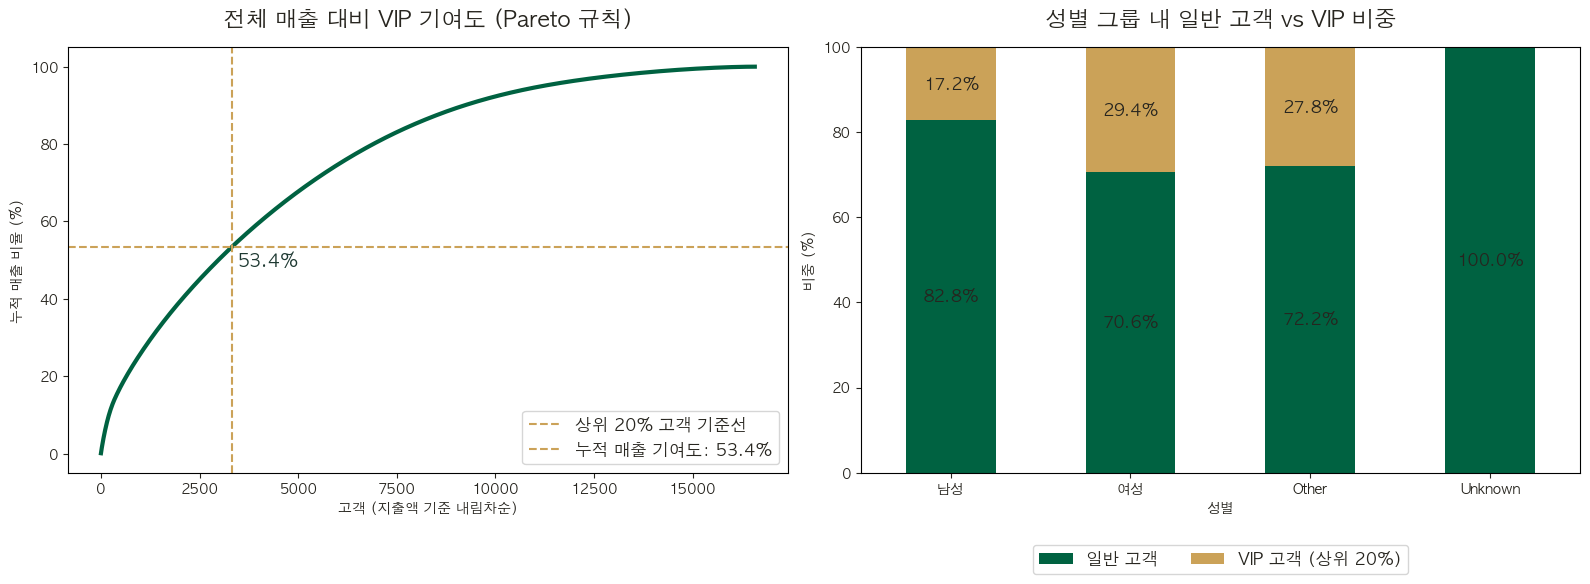

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto 곡선
sorted_cust = (
    customers[customers['total_amount'] > 0]
    .sort_values('total_amount', ascending=False)
    .reset_index(drop=True)
)
sorted_cust['cum_amount']  = sorted_cust['total_amount'].cumsum()
sorted_cust['cum_percent'] = sorted_cust['cum_amount'] / sorted_cust['total_amount'].sum() * 100

top20_idx     = int(len(sorted_cust) * 0.2)
top20_revenue = sorted_cust.loc[top20_idx, 'cum_percent']

axes[0].plot(sorted_cust.index, sorted_cust['cum_percent'], color=SB_GREEN, lw=3)
axes[0].axvline(top20_idx,     color=SB_GOLD, linestyle='--', label='상위 20% 고객 기준선')
axes[0].axhline(top20_revenue, color=SB_GOLD, linestyle='--',
                label=f'누적 매출 기여도: {top20_revenue:.1f}%')
axes[0].set_title('전체 매출 대비 VIP 기여도 (Pareto 규칙)',
                  fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('고객 (지출액 기준 내림차순)')
axes[0].set_ylabel('누적 매출 비율 (%)')
axes[0].text(top20_idx + 150, top20_revenue - 5, f'{top20_revenue:.1f}%',
             color=SB_DEEP_GREEN, fontweight='bold', fontsize=13)
axes[0].legend(fontsize=12)

# 성별 내 VIP 비중
gender_vip = (
    customers.groupby('gender_mapped')['is_vip']
    .value_counts(normalize=True)
    .unstack()
    .reindex(GENDER_ORDER) * 100
)
ax = gender_vip.plot(kind='bar', stacked=True, color=[SB_GREEN, SB_GOLD], ax=axes[1])
axes[1].set_title('성별 그룹 내 일반 고객 vs VIP 비중',
                  fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('성별')
axes[1].set_ylabel('비중 (%)')
axes[1].legend(['일반 고객', 'VIP 고객 (상위 20%)'],
               loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##### 지출액 기준 상위 20%의 고객이 전체 매출의 53.4%를 발생시키고 있음
##### 고객수는 남성이 더 많지만 VIP 고객 비율은 여성이 높다
##### 이는 고액 지출로 이어지는 충성 고객층은 주로 여성 중심으로 형성되어 있음

##### 여성 VIP 고객의 이탈을 막기 위해, 이들의 선호도와 구매 패턴에 맞춘 프라이빗 혜택이나 전용 맴버십 프로그램을 강화하는 것이 효율적
##### 남성 고객의 VIP 전환 전략 검토 : 전환율이 낮은 이유를 파악해야 한다. 상품군이 부족한 것인지, 마케팅 메시지가 맞지 않는 것인지 분석해야 객단가를 높히는 전략을 마련할 수 있음
##### 전체 매출의 46.6%를 차지하는 일반 고객층 중, 상위 20% 커트라인에 근접한 고객들을 타겟화하여 추가 구매를 유도하면 전체 매출 볼륨을 크게 키울 수 있음.

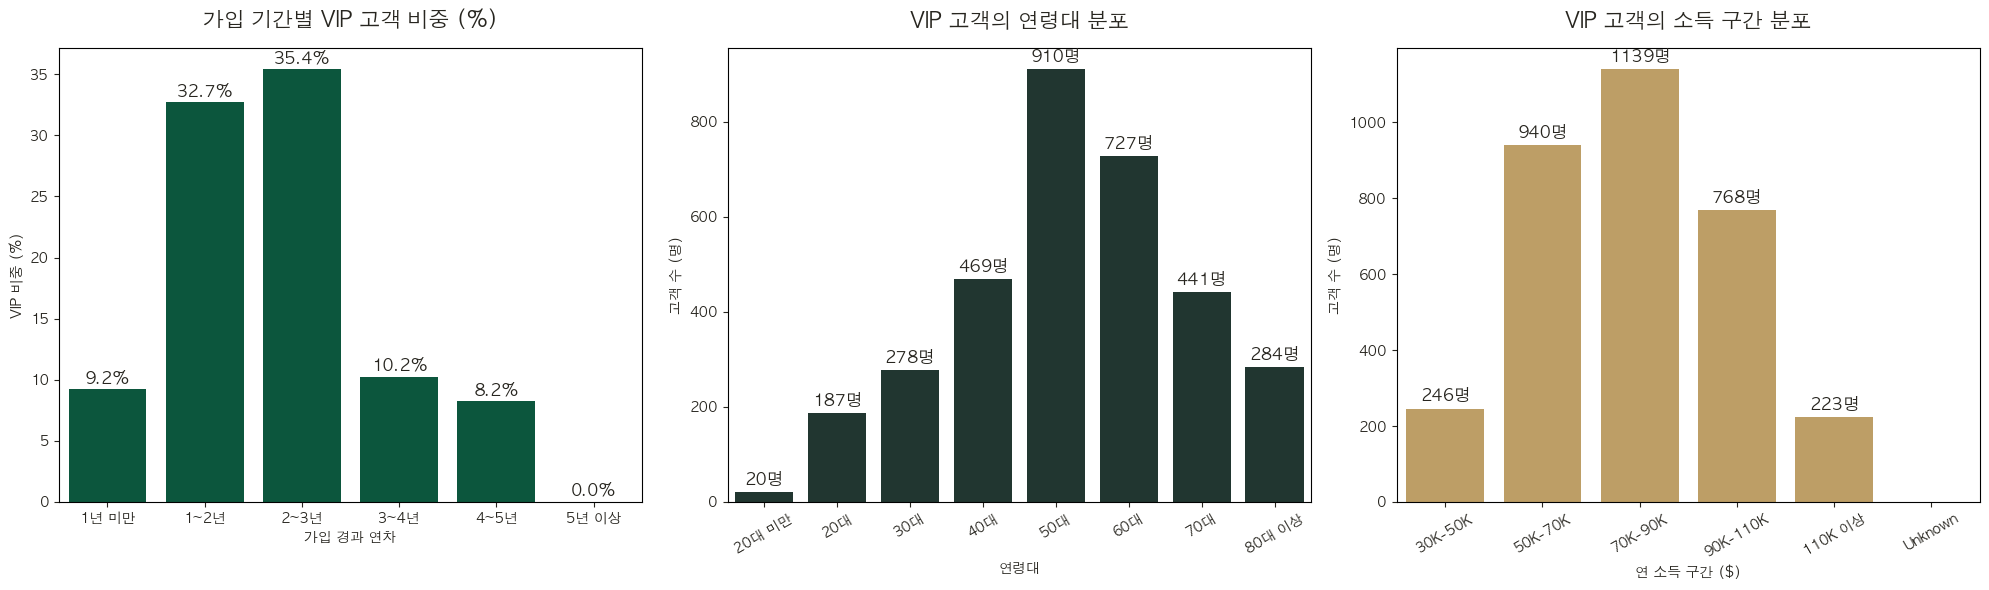

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
vip_cust = customers[customers['is_vip']]

# 가입 기간별 VIP 비중
vip_tenure = customers.groupby('tenure_group')['is_vip'].mean().reindex(TENURE_ORDER) * 100
ax1 = sns.barplot(x=vip_tenure.index, y=vip_tenure.values, color=SB_GREEN, ax=axes[0])
axes[0].set_title('가입 기간별 VIP 고객 비중 (%)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('가입 경과 연차')
axes[0].set_ylabel('VIP 비중 (%)')
for i, v in enumerate(vip_tenure.values):
    if not pd.isna(v):
        ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# VIP 고객의 연령대 분포
ax2 = sns.countplot(data=vip_cust, x='age_group', color=SB_DEEP_GREEN,
                    ax=axes[1], order=AGE_LABELS)
axes[1].set_title('VIP 고객의 연령대 분포', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('연령대')
axes[1].set_ylabel('고객 수 (명)')
axes[1].tick_params(axis='x', rotation=30)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

# VIP 고객의 소득 구간 분포
ax3 = sns.countplot(data=vip_cust, x='income_group', color=SB_GOLD,
                    ax=axes[2], order=INCOME_ORDER)
axes[2].set_title('VIP 고객의 소득 구간 분포', fontsize=15, fontweight='bold', pad=15)
axes[2].set_xlabel('연 소득 구간 ($)')
axes[2].set_ylabel('고객 수 (명)')
axes[2].tick_params(axis='x', rotation=30)
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


In [68]:
# 해찬추가-import오류 해결용
from scipy.stats import kruskal 

# 소득 구간별 지출액 Kruskal-Wallis 검정
income_groups = [
    customers[customers['income_group'] == grp]['total_amount'].dropna()
    for grp in INCOME_LABELS
    if len(customers[customers['income_group'] == grp]) > 0
]

k_stat, k_p = kruskal(*income_groups)
print("=" * 60)
print("[소득 구간별 지출액 차이 — Kruskal-Wallis]")

[소득 구간별 지출액 차이 — Kruskal-Wallis]


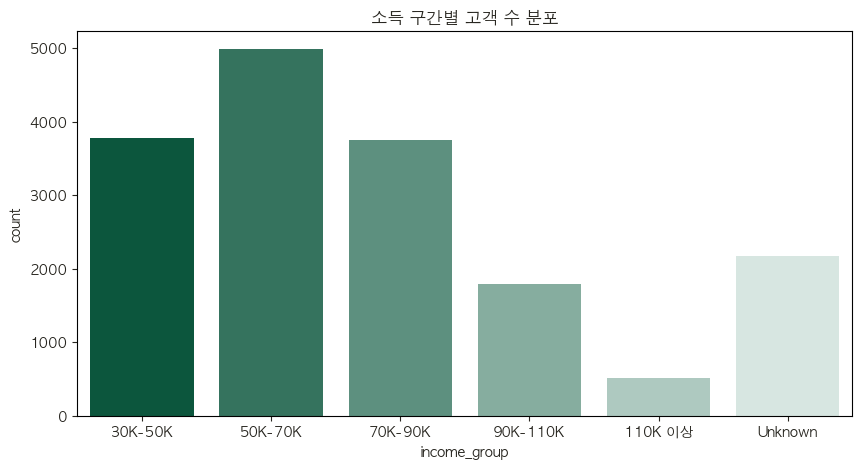

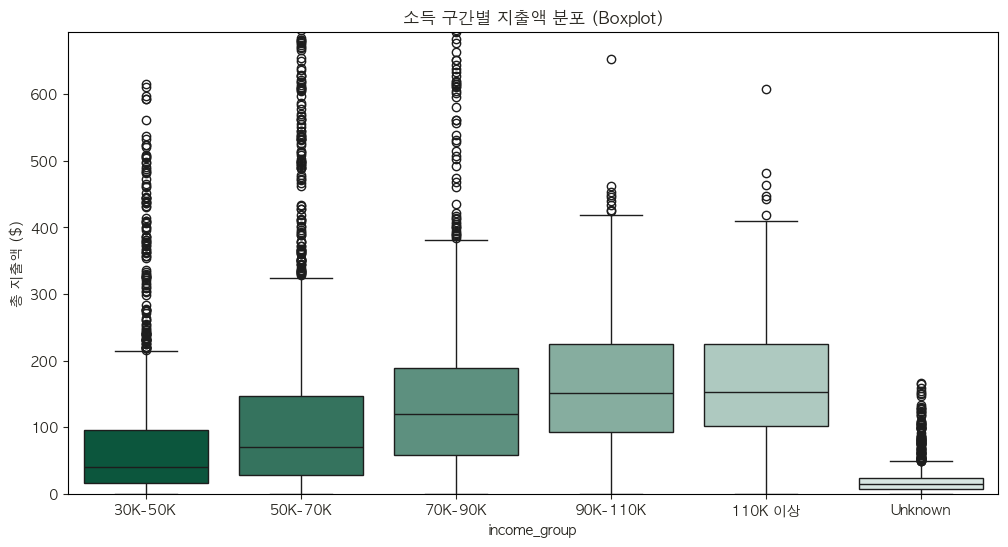

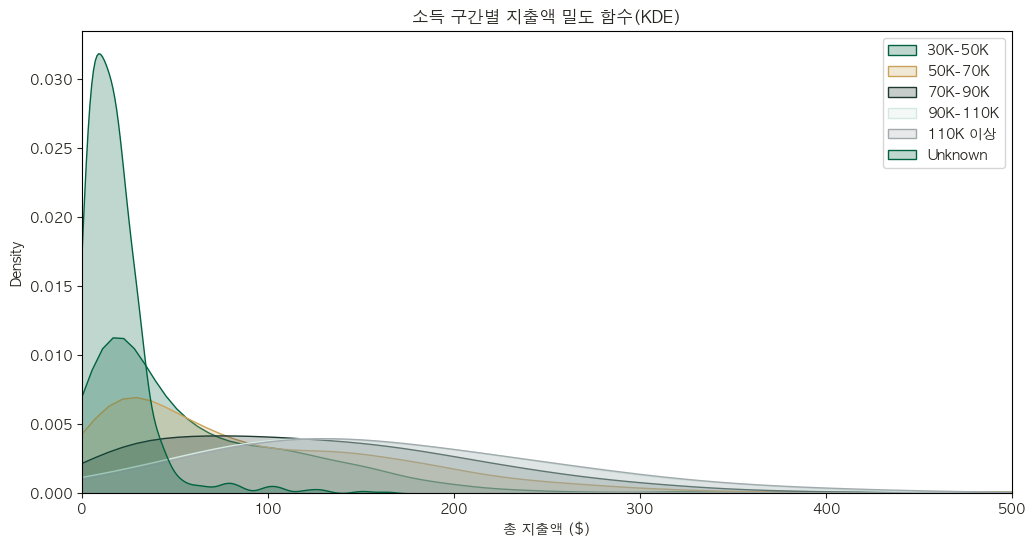

[소득 구간별 지출액 차이 — Kruskal-Wallis]
  H = 2327.12,  p = 0.0000  ★ 유의미 (p<0.05)
  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.
    (사후 검정 필요: 아래 셀 참고)


In [69]:
income_group_palette = sns.blend_palette([SB_GREEN, SB_LIGHT_GREEN], n_colors=6)

# 소득 구간별 고객 수 분포 (샘플 사이즈 확인)
plt.figure(figsize=(10, 5))
sns.countplot(data=customers, x='income_group', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 고객 수 분포')
plt.show()

# 소득 구간별 지출액(total_amount) 분포 - Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=customers, x='income_group', y='total_amount', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 지출액 분포 (Boxplot)')
plt.ylim(0, customers['total_amount'].quantile(0.99))
plt.ylabel('총 지출액 ($)')
plt.show()

# 소득 구간별 지출액 밀도 그래프 (Distribution Shape 확인)
plt.figure(figsize=(12, 6))
for grp in INCOME_ORDER:
    subset = customers[customers['income_group'] == grp]
    sns.kdeplot(subset['total_amount'], label=grp, fill=True)

plt.title('소득 구간별 지출액 밀도 함수(KDE)')
plt.xlim(0, 500) # 주요 지출 구간 집중 확인
plt.xlabel('총 지출액 ($)')
plt.legend()
plt.show()

# 소득 구간별 지출액 Kruskal-Wallis 검정
income_groups = [
    customers[customers['income_group'] == grp]['total_amount'].dropna()
    for grp in INCOME_LABELS
    if len(customers[customers['income_group'] == grp]) > 0
]
k_stat, k_p = kruskal(*income_groups)
print("=" * 60)
print("[소득 구간별 지출액 차이 — Kruskal-Wallis]")
print(f"  H = {k_stat:.2f},  p = {k_p:.4f}  {'★ 유의미 (p<0.05)' if k_p < 0.05 else '유의미하지 않음'}")
if k_p < 0.05:
    print("  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.")
    print("    (사후 검정 필요: 아래 셀 참고)")
print("=" * 60)


##### 중/저소득층 (30K-90K): 트래픽을 유발하는 다수이므로, 'BOGO(1+1)'나 '할인 쿠폰'처럼 가격 민감도를 낮춰주는 혜택이 효과적일 수 있다.

##### 고소득층 (90K 이상): 가격보다는 가치에 반응할 가능성이 높으므로, 가격 할인이 없더라도 특별한 경험을 제공하는 프로모션(예: 신메뉴 선공개, 일정 금액 이상 구매 시 한정판 굿즈 증정 등)이 객단가를 극대화하는 데 유리.

##### Unknown 그룹 정비: 이 그룹에 마케팅 예산을 낭비하지 않도록 타겟팅에서 제외하거나, 첫 구매를 유도하는 강력한 웰컴 쿠폰 하나만을 찔러보는 식별화 작업이 필요해 보인다.

### 소득 구간별 지출액 통계 검정 결과 정리
#### [분석 목적]
##### 고객의 연간 소득 수준이 총 지출액 형성에 유의미한 영향을 미치는지 검증하고, 마케팅 타겟팅을 위한 소득 구간별 구매력 차이를 확인하고자 함.

#### [검정 방법]
##### 1. 그룹 간 차이 검정 - Kruskal-wallis Test : 데이터의 비정규성 고려
##### 결과 : H = 2327.12, p < 0.001 (굉장히 유의미)
##### 해석 : 모든 소득 구간의 지출액 분포가 동일하다는 귀무가설을 기각함. 즉, 소득 구간에 따라 지출액의 차이가 매우 확실하게 존재함.

##### 2. 상세 구간 비교 - Dunn's Post-hoc Test
##### 결과 : 최상위 고소득층 두 그룹(90K-110K와 110K 이상) 간을 제외한 모든 소득 구간에서 서로 유의미한 지출액 차이(p < 0.001)를 보임
##### 해석 : 단순히 "차이가 있다"를 넘어, 모든 소득 구간이 서로 통계적으로 다른 지출 패턴을 보임.

#### [최종 인사이트]
##### 돈을 많이 벌면 많이 쓴다는 직관이 본 데이터셋에서 높은 신뢰도로 증명.
##### 모든 구간이 통계적으로 다르기 때문에, 각 소득 구간별로 차별화된 오퍼를 제공하는 전략이 데이터적으로 정당성을 가짐.
##### 소득 미기재 그룹(Unknown) 또한 다른 모든 그룹과 유의미하게 다른 지출 패턴을 보이므로, 이들을 별도의 마케팅 관리 대상으로 분류할 필요가 있음.

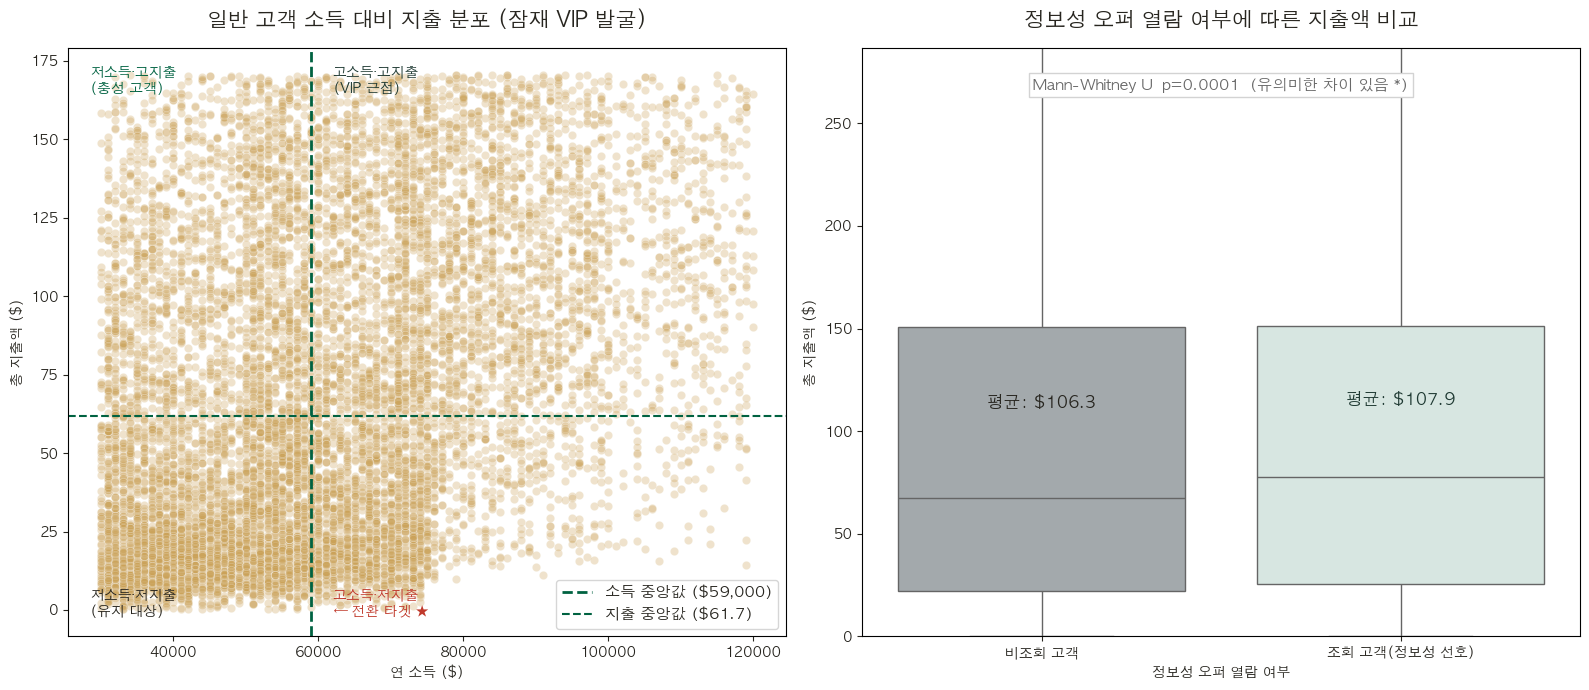

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)
general_cust = customers[~customers['is_vip'] & (customers['total_amount'] > 0) & customers['income'].notna()].copy()

sns.scatterplot(data=general_cust, x='income', y='total_amount',
                alpha=0.3, color=SB_GOLD, ax=axes[0])

med_inc = general_cust['income'].median()
med_amt = general_cust['total_amount'].median()

axes[0].axvline(med_inc, color=SB_GREEN, linestyle='--', lw=2,
                label=f'소득 중앙값 (${med_inc:,.0f})')
axes[0].axhline(med_amt, color=SB_GREEN, linestyle='--', lw=1.5,
                label=f'지출 중앙값 (${med_amt:.1f})')
axes[0].set_title('일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('연 소득 ($)')
axes[0].set_ylabel('총 지출액 ($)')
axes[0].legend(fontsize=11)

xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()
x_offset = (xlim[1] - xlim[0]) * 0.03
y_offset = (ylim[1] - ylim[0]) * 0.03

axes[0].text(med_inc + x_offset, ylim[1] - y_offset,
             '고소득·고지출\n(VIP 근접)',      ha='left', va='top',   fontsize=10, color=SB_DEEP_GREEN, fontweight='bold')
axes[0].text(med_inc + x_offset, ylim[0] + y_offset,
             '고소득·저지출\n← 전환 타겟 ★', ha='left', va='bottom', fontsize=10, color='#C0392B',    fontweight='bold')
axes[0].text(xlim[0] + x_offset, ylim[1] - y_offset,
             '저소득·고지출\n(충성 고객)',      ha='left', va='top',   fontsize=10, color=SB_GREEN)
axes[0].text(xlim[0] + x_offset, ylim[0] + y_offset,
             '저소득·저지출\n(유지 대상)',      ha='left', va='bottom', fontsize=10, color=SB_BLACK)

# 정보성 오퍼 열람 여부별 지출액 비교 (박스플롯)
sns.boxplot(data=customers[customers['total_amount'] > 0],
            x='info_viewer', y='total_amount',
            palette=[SB_GREY, SB_LIGHT_GREEN], ax=axes[1])

axes[1].set_title('정보성 오퍼 열람 여부에 따른 지출액 비교',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(['비조회 고객', '조회 고객(정보성 선호)'])
axes[1].set_xlabel('정보성 오퍼 열람 여부')
axes[1].set_ylabel('총 지출액 ($)')

axes[1].set_ylim(0, customers['total_amount'].quantile(0.95))

mean_non = customers[(customers['total_amount'] > 0) & ~customers['info_viewer']]['total_amount'].mean()
mean_yes = customers[(customers['total_amount'] > 0) &  customers['info_viewer']]['total_amount'].mean()
axes[1].text(0, mean_non + 5, f'평균: ${mean_non:.1f}', ha='center',
             fontweight='bold', color=SB_BLACK,      fontsize=12)
axes[1].text(1, mean_yes + 5, f'평균: ${mean_yes:.1f}', ha='center',
             fontweight='bold', color=SB_DEEP_GREEN, fontsize=12)

# Mann-Whitney U 검정 수행 및 텍스트 표시
from scipy.stats import mannwhitneyu
g1 = customers[(customers['total_amount'] > 0) & ~customers['info_viewer']]['total_amount']
g2 = customers[(customers['total_amount'] > 0) &  customers['info_viewer']]['total_amount']
stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
sig = "유의미한 차이 있음 *" if p_val < 0.05 else "유의미한 차이 없음"

axes[1].text(0.5, axes[1].get_ylim()[1] * 0.95,
             f'Mann-Whitney U  p={p_val:.4f}  ({sig})',
             ha='center', va='top', fontsize=11, color='dimgray',
             transform=axes[1].transData,
             bbox=dict(fc='white', ec='lightgray', pad=3))

plt.tight_layout()
plt.show()

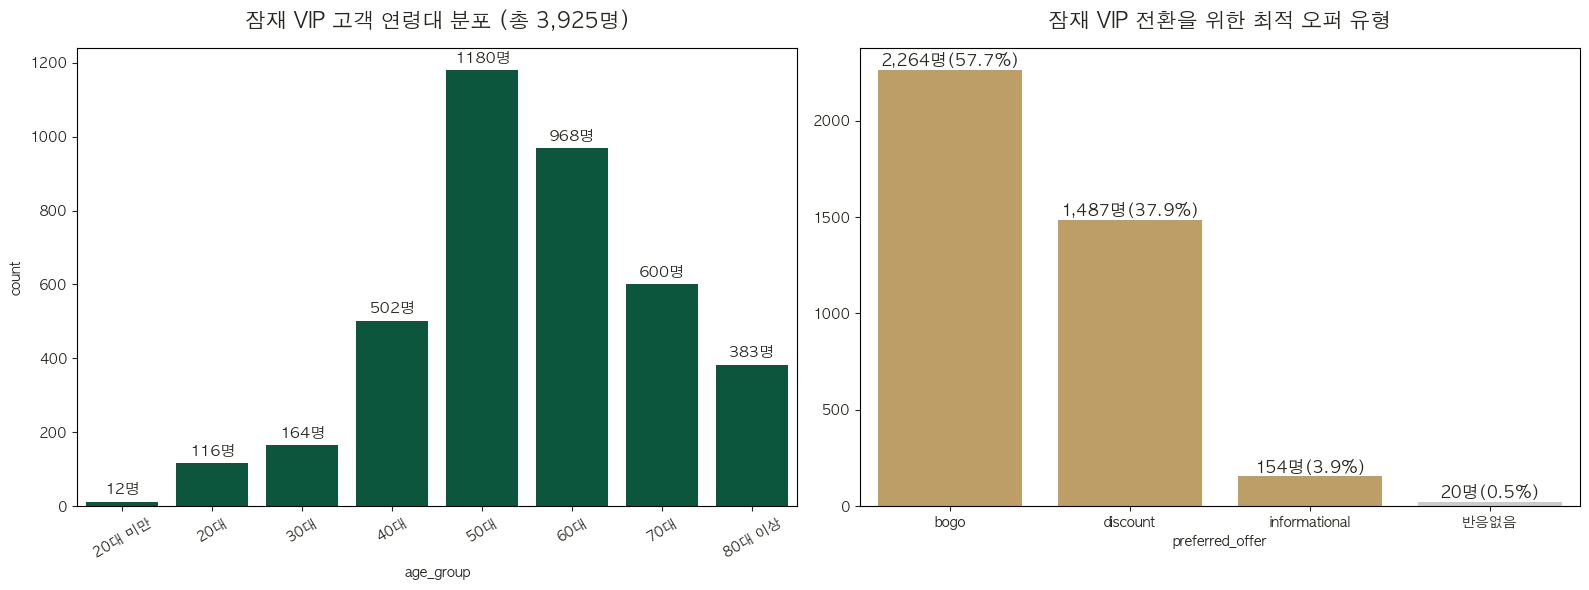

In [71]:
potential_vip_mask = (~customers['is_vip']) & (customers['income'] >= 70000)
potential_vips     = customers[potential_vip_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 잠재 VIP 연령대 분포
ax1 = sns.countplot(data=potential_vips, x='age_group', color=SB_GREEN,
                    order=AGE_LABELS, ax=axes[0])
axes[0].set_title(f'잠재 VIP 고객 연령대 분포 (총 {len(potential_vips):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=30)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 잠재 VIP 선호 오퍼
pref_offer = potential_vips['preferred_offer'].value_counts()
ax2 = sns.barplot(x=pref_offer.index, y=pref_offer.values,
                  palette=[SB_GOLD] * 3 + ['#CCCCCC'], ax=axes[1])
axes[1].set_title('잠재 VIP 전환을 위한 최적 오퍼 유형',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(pref_offer.values):
    ax2.text(i, v + 20, f'{v:,.0f}명({v/len(potential_vips)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

##### 5060 고소득저지출 즉, 우리 브랜드에 지갑을 열지 않은 그룹이 뚜렷하게 존재 - > 구매를 유인할 결정적인 트리거가 없었을 확률이 큼 -> bogo쿠폰을 우선순위 오퍼로 진행 후 discount오퍼 진행

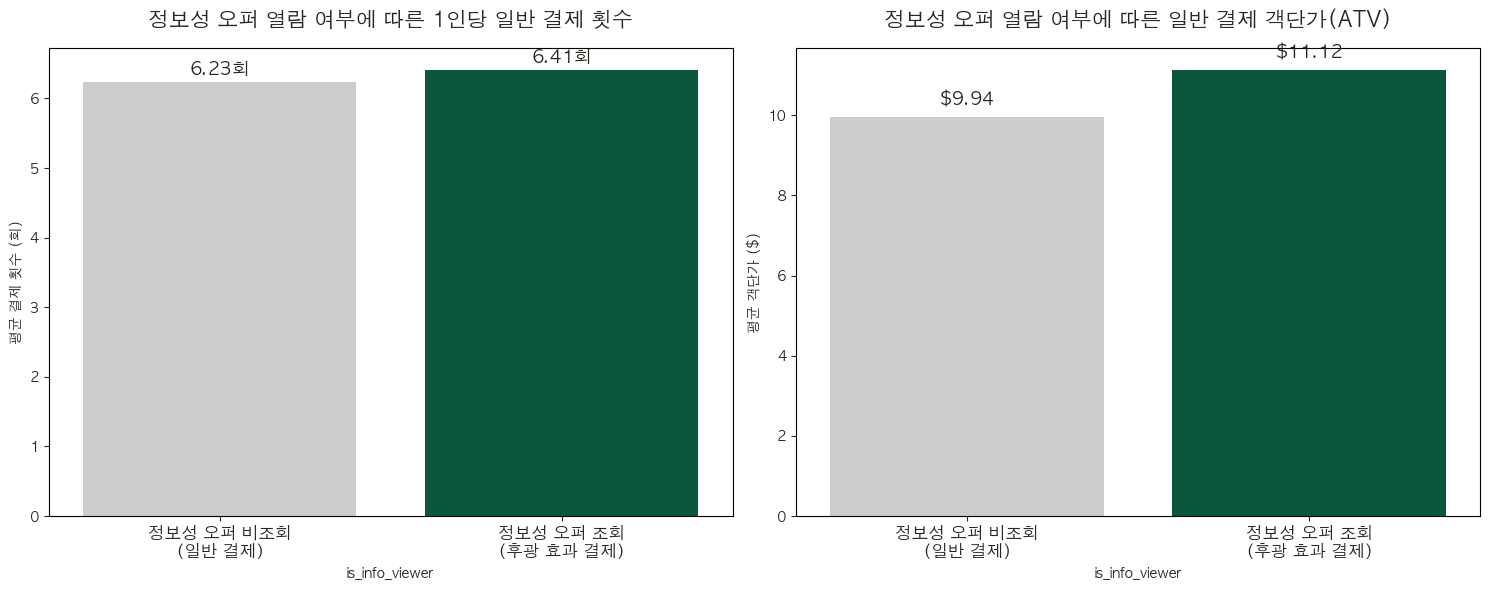

[후광 효과 통계 검정 — Mann-Whitney U]
결제 횟수 차이  : p = 0.0002  ★ 유의미 (p<0.05)
객단가 차이     : p = 0.0000  ★ 유의미 (p<0.05)

정보성 오퍼 조회 고객이 일반 결제 횟수 약 2.8% 더 많음
단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로
'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.


In [72]:
# 일반 결제(오퍼 X) 추출
tx_df   = df[df['event'] == 'transaction'][['customer_id','time_days','amount']]
comp_df = df[df['event'] == 'completed'  ][['customer_id','time_days','offer_type']]

tx_merged = pd.merge(tx_df, comp_df, on=['customer_id','time_days'], how='left')
tx_merged = tx_merged.drop_duplicates(subset=['customer_id','time_days','amount'])

general_tx = tx_merged[tx_merged['offer_type'].isna()].copy()
general_tx['is_info_viewer'] = general_tx['customer_id'].isin(info_viewers)

# 그룹별 집계
freq_df  = general_tx.groupby(['is_info_viewer','customer_id']).size().reset_index(name='tx_count')
avg_freq = freq_df.groupby('is_info_viewer')['tx_count'].mean()
avg_atv  = general_tx.groupby('is_info_viewer')['amount'].mean()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels = ['정보성 오퍼 비조회\n(일반 결제)', '정보성 오퍼 조회\n(후광 효과 결제)']
colors = ['#CCCCCC', SB_GREEN]

ax1 = sns.barplot(x=avg_freq.index, y=avg_freq.values, palette=colors, ax=axes[0])
axes[0].set_title('정보성 오퍼 열람 여부에 따른 1인당 일반 결제 횟수',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylabel('평균 결제 횟수 (회)')
for i, v in enumerate(avg_freq.values):
    ax1.text(i, v + 0.1, f'{v:.2f}회', ha='center', fontweight='bold', fontsize=13)

ax2 = sns.barplot(x=avg_atv.index, y=avg_atv.values, palette=colors, ax=axes[1])
axes[1].set_title('정보성 오퍼 열람 여부에 따른 일반 결제 객단가(ATV)',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel('평균 객단가 ($)')
for i, v in enumerate(avg_atv.values):
    ax2.text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# Mann-Whitney U 검정 (결제 횟수 & 객단가)
g_no  = freq_df[~freq_df['is_info_viewer']]['tx_count']
g_yes = freq_df[ freq_df['is_info_viewer']]['tx_count']
stat_freq, p_freq = mannwhitneyu(g_no, g_yes, alternative='two-sided')

g_no_atv  = general_tx[~general_tx['is_info_viewer']]['amount']
g_yes_atv = general_tx[general_tx['is_info_viewer']]['amount']
stat_atv,  p_atv  = mannwhitneyu(g_no_atv, g_yes_atv, alternative='two-sided')

print("=" * 70)
print("[후광 효과 통계 검정 — Mann-Whitney U]")
print(f"결제 횟수 차이  : p = {p_freq:.4f}  {'★ 유의미 (p<0.05)' if p_freq < 0.05 else '유의미하지 않음'}")
print(f"객단가 차이     : p = {p_atv:.4f}  {'★ 유의미 (p<0.05)' if p_atv  < 0.05 else '유의미하지 않음'}")
print()
if avg_freq[True] > avg_freq[False]:
    print(f"정보성 오퍼 조회 고객이 일반 결제 횟수 약 {(avg_freq[True]/avg_freq[False]-1)*100:.1f}% 더 많음")
    print("단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로")
    print("'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.")
print("=" * 70)


##### 이 분석은 상관관계임. 고관여 고객이 원래부터 열람률이 높을 수 있으므로(선택 편향), 인과 관계로 단정하지 말 것.

##### 결과 : 결제 횟수($p=0.0002$), 객단가($p=0.0000$) 모두 유의미.
##### 해석 : 정보성 오퍼는 직접적인 보상이 없어도 브랜드 상기 효과를 통해 고객을 매장으로 불러들이고(횟수 증가), 더 많이 쓰게(객단가 증가) 만드는 후광 효과가 입증됨.
##### 전략 : VIP와 고소득층에게는 비용이 드는 할인 쿠폰보다 정보성 콘텐츠를 자주 노출하는 것이 비용 효율적임을 시사.

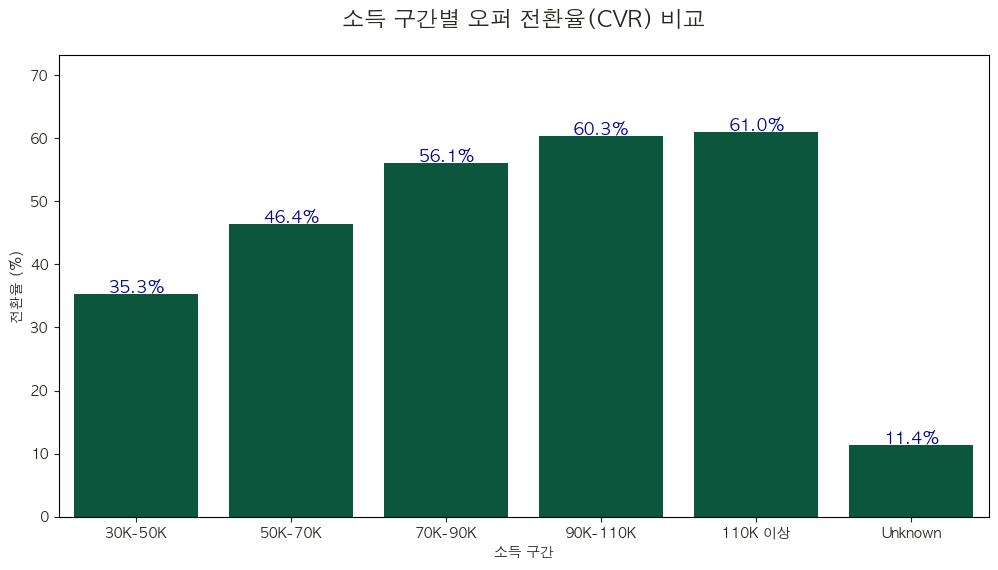

In [73]:
# 오퍼 반응 데이터 계산 (Received -> Completed 전환율)
offer_stats = df[df['event'].isin(['received', 'completed'])].copy()

# 소득 구간 정보 결합
offer_stats = pd.merge(offer_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 구간별/이벤트별 카운트
cvr_data = offer_stats.groupby(['income_group', 'event']).size().unstack(fill_value=0)
cvr_data['conversion_rate'] = (cvr_data['completed'] / cvr_data['received']) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cvr_data.index, y=cvr_data['conversion_rate'], palette=[SB_GREEN], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 전환율(CVR) 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (%)')
plt.xlabel('소득 구간')
plt.ylim(0, cvr_data['conversion_rate'].max() * 1.2)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=12, fontweight='bold', color='darkblue')

plt.show()

##### 30K-50K(54.0%)에서 시작해 소득이 높아질수록 전환율이 가파르게 상승하여, 110K 이상 구간에서는 82.2%라는 압도적인 반응률을 보임

#### [마케팅 반응 최종 통계 및 인사이트]
##### 고소득층은 구매력(Buying Power)과 반응도(Response)를 모두 갖춘 최적의 타겟.
##### 고소득 VIP 세그먼트에게는 '정보성 오퍼'로 브랜드 로열티를 관리하고, '전략적 오퍼'로 확실한 매출을 견인하는 투트랙 전략이 유효함.

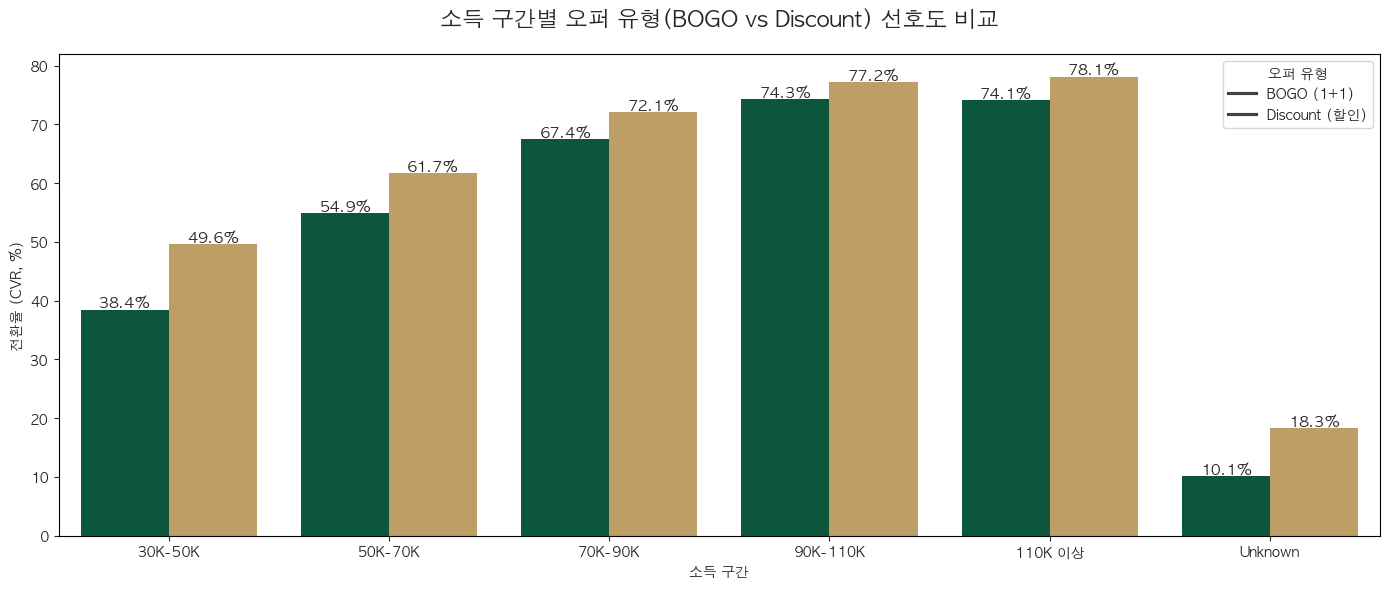

In [74]:
# 오퍼 유형별 전환율 데이터
offer_type_stats = df[df['event'].isin(['received', 'completed'])].copy()
offer_type_stats = pd.merge(offer_type_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 유형별(BOGO/Discount)로 나누어 계산
offer_pivot = offer_type_stats.groupby(['income_group', 'offer_type', 'event']).size().unstack(fill_value=0)
offer_pivot['cvr'] = (offer_pivot['completed'] / offer_pivot['received']) * 100
offer_pivot = offer_pivot.reset_index()

# 시각화
plt.figure(figsize=(14, 6))
sns.barplot(data=offer_pivot[offer_pivot['offer_type'].isin(['bogo', 'discount'])], 
            x='income_group', y='cvr', hue='offer_type', 
            palette=[SB_GREEN, SB_GOLD], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 유형(BOGO vs Discount) 선호도 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (CVR, %)')
plt.xlabel('소득 구간')
plt.legend(title='오퍼 유형', labels=['BOGO (1+1)', 'Discount (할인)'])

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                           ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

##### 소득 구간이 높아질수록 오퍼 전환율이 정비례하여 상승하며 모든 소득 구간에서 할인 오퍼의 전환율(발송대비완료)이 일관되게 더 높음.

##### 각적인 매출(CVR) 전환이 목표라면 '할인(Discount)'을 주력 무기로 사용해야 한다.

### 고객 세그먼트 딥다이브

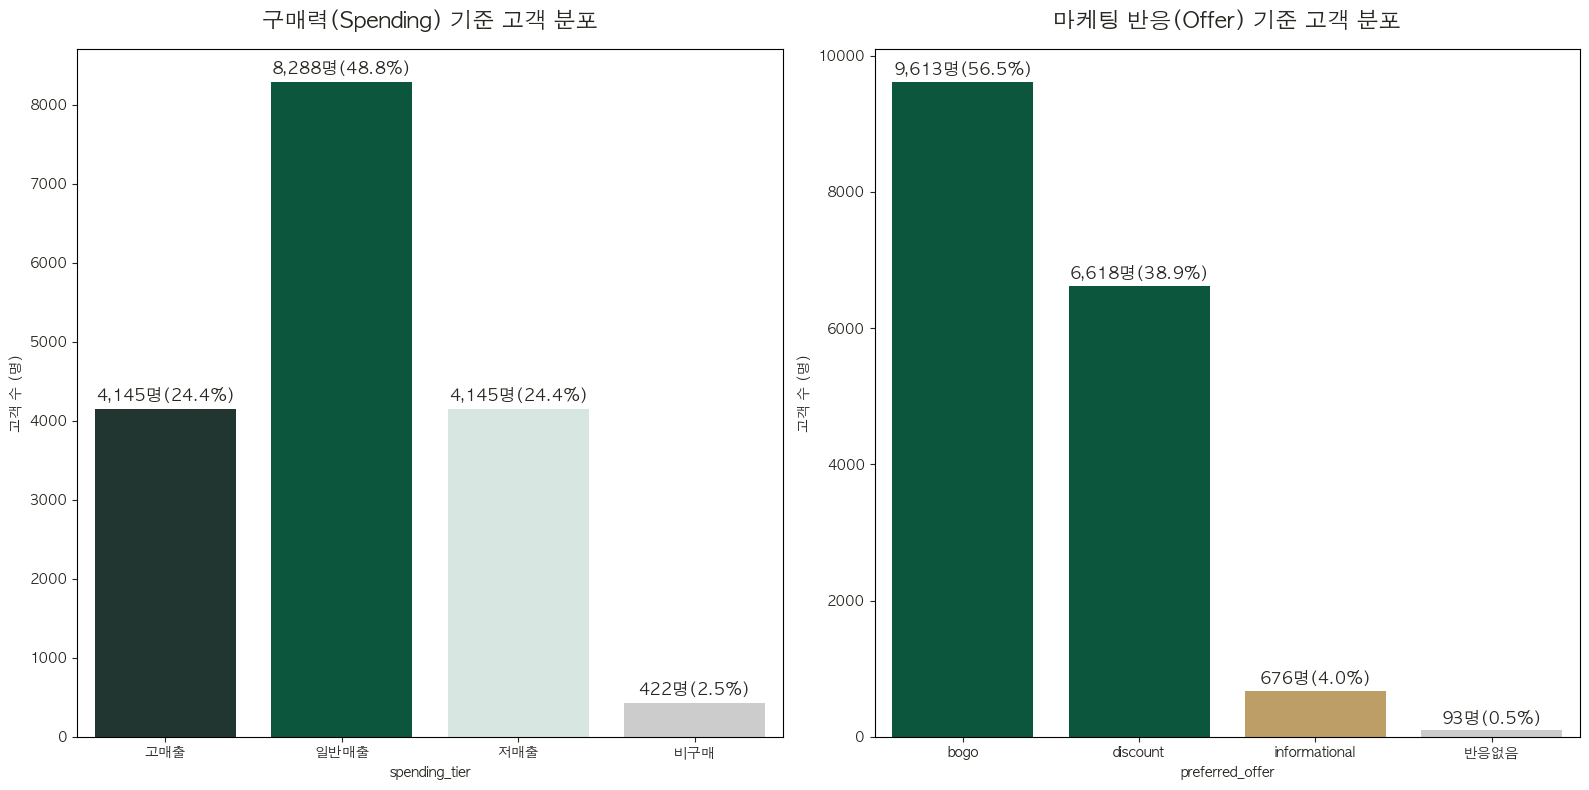

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 구매력 기준 분포
spend_order  = ['고매출', '일반매출', '저매출', '비구매']
spend_counts = customers['spending_tier'].value_counts().reindex(spend_order)
spend_pct    = spend_counts / len(customers) * 100

ax1 = sns.barplot(x=spend_counts.index, y=spend_counts.values,
                  palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#CCCCCC'], ax=axes[0])
axes[0].set_title('구매력(Spending) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(spend_counts.values, spend_pct.values)):
    if not pd.isna(v):
        ax1.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                 fontweight='bold', fontsize=12)

# 마케팅 반응 기준 분포
offer_order  = ['bogo', 'discount', 'informational', '반응없음']
offer_counts = customers['preferred_offer'].value_counts().reindex(offer_order)
offer_pct    = offer_counts / len(customers) * 100

ax2 = sns.barplot(x=offer_counts.index, y=offer_counts.values,
                  palette=[SB_GREEN, SB_GREEN, SB_GOLD, '#CCCCCC'], ax=axes[1])
axes[1].set_title('마케팅 반응(Offer) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(offer_counts.values, offer_pct.values)):
    if not pd.isna(v):
        ax2.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                 fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


#### [액션 플랜]
##### bogo 오퍼 유형으로 고소득 일반 고객 타겟 프로모션 진행 후 discount 오퍼 추가 진행 고려

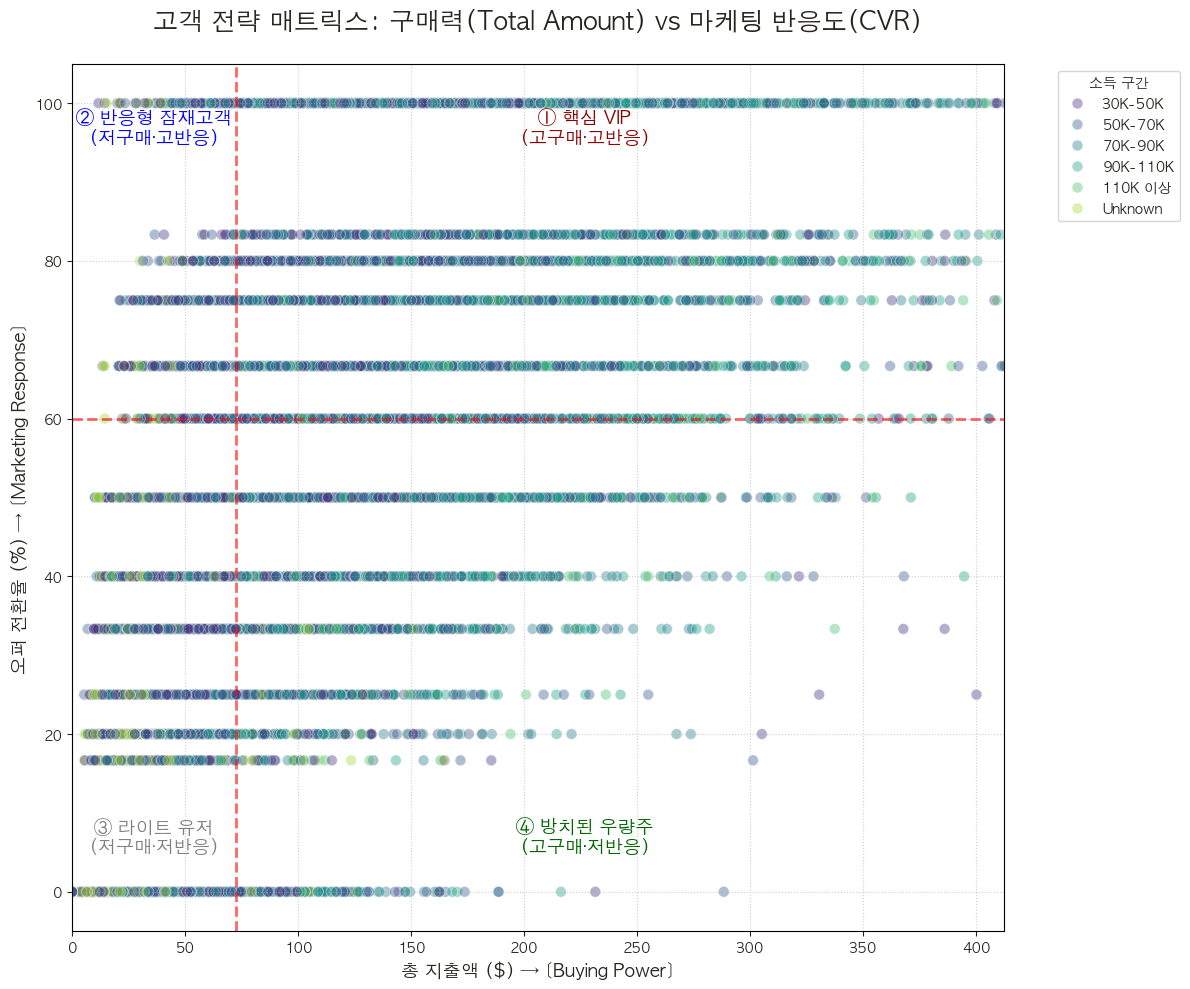

In [76]:
# 고객별 마케팅 반응도(CVR) 계산
offer_counts = df[df['event'].isin(['received', 'completed'])].groupby(['customer_id', 'event']).size().unstack(fill_value=0)

if 'received' in offer_counts.columns and 'completed' in offer_counts.columns:
    # 수령(received)이 0인 경우 결측치 처리를 위해 np.where 사용
    offer_counts['individual_cvr'] = np.where(
        offer_counts['received'] > 0,
        (offer_counts['completed'] / offer_counts['received']) * 100,
        0
    )
else:
    offer_counts['individual_cvr'] = 0

# 기존 customers 데이터와 결합
matrix_df = pd.merge(customers, offer_counts[['individual_cvr']], on='customer_id', how='left')

# 범주형 에러 방지: 필요한 컬럼(individual_cvr)에만 0을 채웁니다.
matrix_df['individual_cvr'] = matrix_df['individual_cvr'].fillna(0)
# total_amount도 혹시 모를 결측치가 있다면 개별적으로 처리
matrix_df['total_amount'] = matrix_df['total_amount'].fillna(0)

plt.figure(figsize=(12, 10))

# 중앙값(Median) 기준 (지출이 있는 고객 대상)
x_mid = matrix_df[matrix_df['total_amount'] > 0]['total_amount'].median()
y_mid = matrix_df[matrix_df['individual_cvr'] > 0]['individual_cvr'].median()

sns.scatterplot(data=matrix_df, x='total_amount', y='individual_cvr', 
                alpha=0.4, hue='income_group', palette='viridis', s=60)

plt.axvline(x_mid, color='red', linestyle='--', alpha=0.6, lw=2)
plt.axhline(y_mid, color='red', linestyle='--', alpha=0.6, lw=2)

# 레이블 위치 조정
plt.text(matrix_df['total_amount'].quantile(0.9), 95, '① 핵심 VIP\n(고구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='darkred')
plt.text(x_mid/2, 95, '② 반응형 잠재고객\n(저구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='blue')
plt.text(x_mid/2, 5, '③ 라이트 유저\n(저구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='grey')
plt.text(matrix_df['total_amount'].quantile(0.9), 5, '④ 방치된 우량주\n(고구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='darkgreen')

plt.title('고객 전략 매트릭스: 구매력(Total Amount) vs 마케팅 반응도(CVR)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('총 지출액 ($) → [Buying Power]', fontsize=13)
plt.ylabel('오퍼 전환율 (%) → [Marketing Response]', fontsize=13)
plt.xlim(0, matrix_df['total_amount'].quantile(0.98))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='소득 구간', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

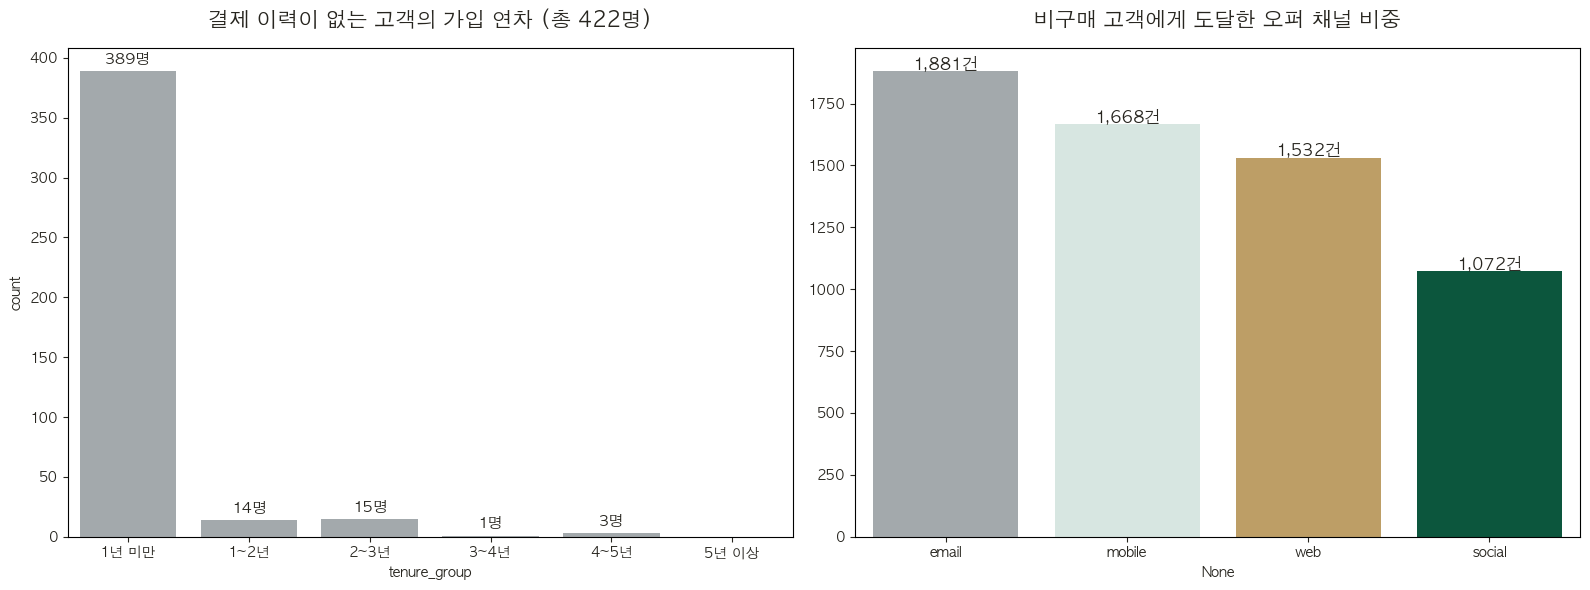

In [77]:
zero_spend_cust = customers[customers['spending_tier'] == '비구매']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 비구매 고객 가입 연차
ax1 = sns.countplot(data=zero_spend_cust, x='tenure_group', color=SB_GREY,
                    order=TENURE_ORDER, ax=axes[0])
axes[0].set_title(f'결제 이력이 없는 고객의 가입 연차 (총 {len(zero_spend_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 비구매 고객 도달 채널
zero_spend_ids = zero_spend_cust['customer_id']
zero_channels  = (
    df[(df['customer_id'].isin(zero_spend_ids)) & (df['event'] == 'received')]
    [['email', 'mobile', 'web', 'social']]
    .sum()
    .sort_values(ascending=False)
)
ax2 = sns.barplot(x=zero_channels.index, y=zero_channels.values,
                  palette=[SB_GREY, SB_LIGHT_GREEN, SB_GOLD, SB_GREEN], ax=axes[1])
axes[1].set_title('비구매 고객에게 도달한 오퍼 채널 비중',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(zero_channels.values):
    ax2.text(i, v + 5, f'{v:,.0f}건', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

#### [액션 플랜]
##### 1년 미만 신규 고객 → 첫 구매 BOGO 쿠폰
##### 가입 기간 긴 미활성 고객 → 휴면 전환 안내(앱 푸시/이메일)
##### Unknown 그룹에는 프로모션 발송 비용(예: 알림톡, SMS 발송비)을 최소화하고, 무료 채널(앱 푸시, 이메일) 위주로만 운영하여 마케팅 ROI를 방어해야 한다.

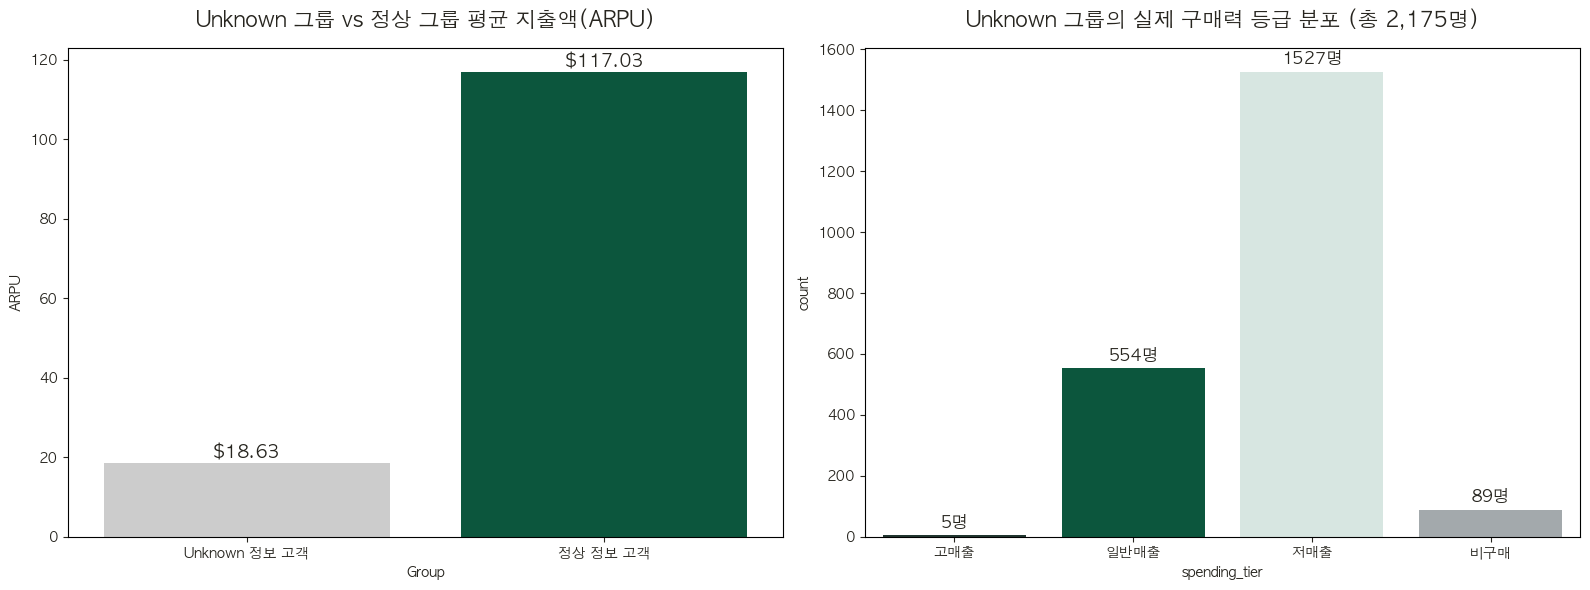

In [78]:
unknown_cust = customers[customers['income_group'] == 'Unknown']
known_cust   = customers[customers['income_group'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unknown vs 정상 ARPU 비교
arpu_data = pd.DataFrame({
    'Group': ['Unknown 정보 고객', '정상 정보 고객'],
    'ARPU' : [unknown_cust['total_amount'].mean(), known_cust['total_amount'].mean()]
})
ax1 = sns.barplot(data=arpu_data, x='Group', y='ARPU',
                  palette=['#CCCCCC', SB_GREEN], ax=axes[0])
axes[0].set_title('Unknown 그룹 vs 정상 그룹 평균 지출액(ARPU)',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(arpu_data['ARPU']):
    ax1.text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

# Unknown 그룹 구매력 등급 분포
ax2 = sns.countplot(data=unknown_cust, x='spending_tier',
                    palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#A2AAAD'],
                    order=['고매출', '일반매출', '저매출', '비구매'], ax=axes[1])
axes[1].set_title(f'Unknown 그룹의 실제 구매력 등급 분포 (총 {len(unknown_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


## 종합 인사이트 & 액션 플랜

| 세그먼트 | 오퍼 유형 | 핵심 채널 | 우선순위 |
|----------|-----------|-----------|----------|
| **VIP (상위 20%)** | 정보성 오퍼 (브랜드 상기) | Email / App Push | ★★★ |
| **잠재 VIP** (고소득·저지출 일반 고객) | 선호 오퍼 집중 타겟팅 (BOGO or Discount) | Mobile | ★★★ |
| **신규 비구매** (가입 1년 미만) | 첫 구매 BOGO 파격 쿠폰 | Mobile / Social | ★★ |
| **장기 비구매** (가입 2년 이상, 결제 없음) | 휴면 전환 안내 또는 윈백 할인 | Email | ★ |
| **Unknown 소득 고매출** | 정보성 오퍼 (Privacy 존중) | App Push | ★★ |

#### 높은 전환율이 보장되는 90K 이상 우량 고객은 할인보다 브랜드 경험 중심의 프리미엄화 전략을 취하고,

#### 성장의 핵심 키를 쥔 5060 잠재 VIP에게는 가장 반응이 좋은 BOGO 오퍼로 활성화를 유도하며,

#### Unknown 및 미결제 그룹에 낭비되던 마케팅 비용은 최소화해야 합니다.

### 주요 수치 요약
- 상위 20% VIP가 전체 매출의 약 54% 기여
- 정보성 오퍼 조회 고객의 일반 결제 횟수 유의미하게 높음 (Mann-Whitney p<0.05 확인 완료)
- 소득 구간별 지출액은 유의미한 차이가 있다 (Kruskal-Wallis 검정 결과 p=0.0001)

> **한계**: 전체 분석 기간이 약 30일로 짧아 장기 고객 행동 패턴이 과소 추정될 수 있습니다.
> 후광 효과 분석은 상관관계이며, 인과 관계로 단정하려면 A/B 테스트가 필요합니다.

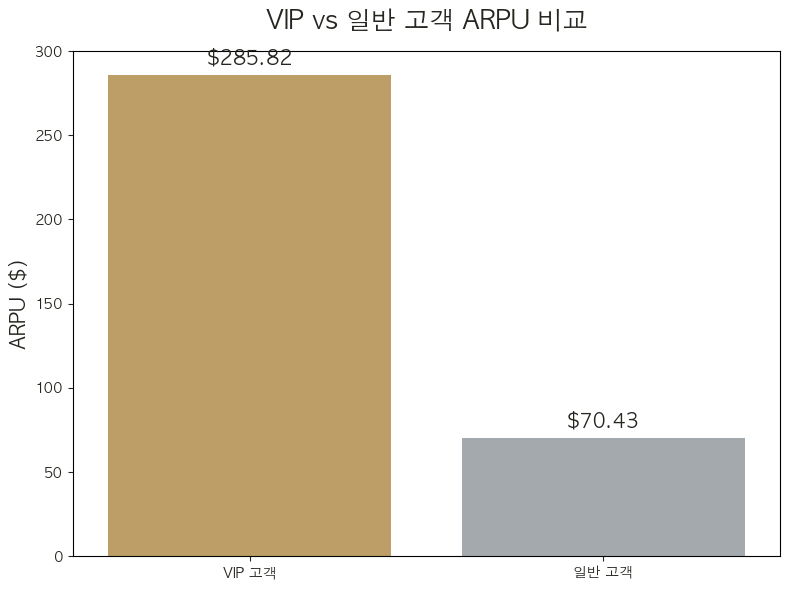

In [79]:
#피드백(해찬추가)-발표용 정리
# 2. 세그먼트별 ARPU 시각화
arpu_data = pd.DataFrame({
    '세그먼트': ['VIP 고객', '일반 고객'],
    'ARPU': [vip_cust['total_amount'].sum() / len(vip_cust), general_cust['total_amount'].sum() / len(general_cust)]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='세그먼트', y='ARPU', data=arpu_data, palette=[SB_GOLD, SB_GREY])

plt.title('VIP vs 일반 고객 ARPU 비교', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('ARPU ($)', fontsize=14)
plt.xlabel('')

# 막대 위에 정확한 수치 달아주기
for p in ax.patches:
    ax.annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=14, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

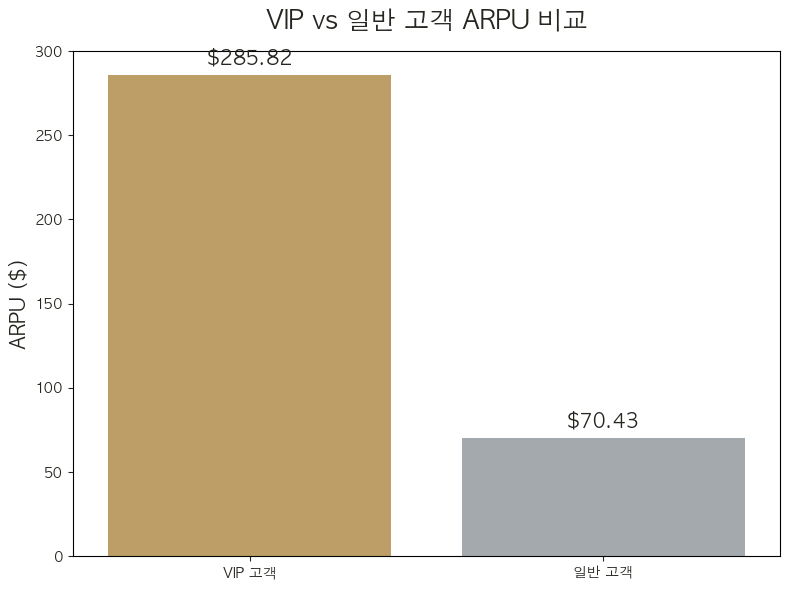

In [80]:
#피드백(해찬추가)-발표용 정리
# 2. 세그먼트별 ARPU 시각화
arpu_data = pd.DataFrame({
    '세그먼트': ['VIP 고객', '일반 고객'],
    'ARPU': [vip_cust['total_amount'].sum() / len(vip_cust), general_cust['total_amount'].sum() / len(general_cust)]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='세그먼트', y='ARPU', data=arpu_data, palette=[SB_GOLD, SB_GREY])

plt.title('VIP vs 일반 고객 ARPU 비교', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('ARPU ($)', fontsize=14)
plt.xlabel('')

# 막대 위에 정확한 수치 달아주기
for p in ax.patches:
    ax.annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=14, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

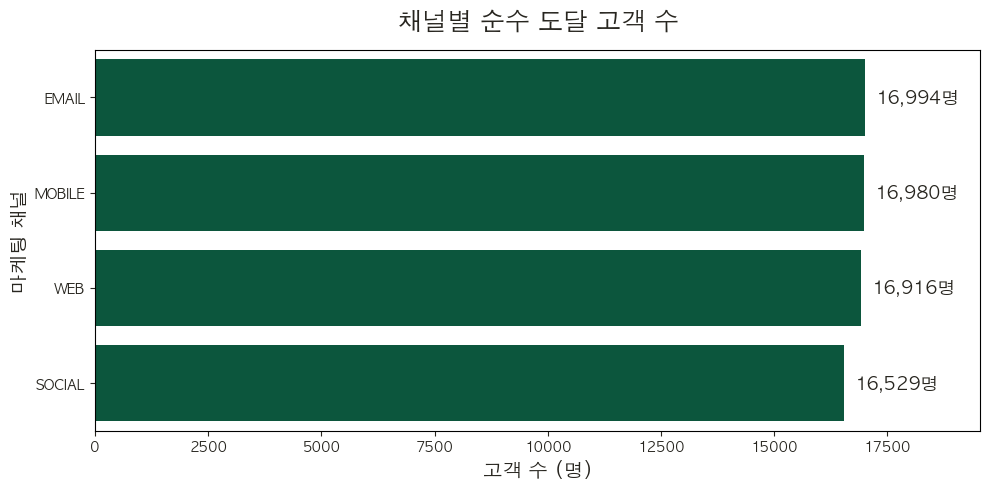

In [81]:
#피드백(해찬추가)-발표용 정리
# 3. 채널별 도달 고객 수 시각화
channel_reach = []
for ch in channels:
    unique_users = df[(df[ch] == 1) & (df['event'] == 'received')]['customer_id'].nunique()
    channel_reach.append({'채널': ch.upper(), '도달 고객 수': unique_users})

channel_df = pd.DataFrame(channel_reach).sort_values(by='도달 고객 수', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='도달 고객 수', y='채널', data=channel_df, palette=[SB_GREEN]*4)

plt.title('채널별 순수 도달 고객 수', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('고객 수 (명)', fontsize=14)
plt.ylabel('마케팅 채널', fontsize=14)

# 막대 끝에 수치 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}명", (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=13, fontweight='bold', xytext=(8, 0), textcoords='offset points')

plt.xlim(0, channel_df['도달 고객 수'].max() * 1.15) # 글자가 잘리지 않게 여백 확보
plt.tight_layout()
plt.show()

In [82]:
#피드백(해찬추가)-발표용 정리
# 4. 오퍼 유형별 퍼널 전환율 데이터프레임 및 히트맵 스타일링
funnel_data = []
for offer_type in offer_types:
    offer_df = df[df['offer_type'] == offer_type]
    
    received  = offer_df[offer_df['event'] == 'received']['customer_id'].nunique()
    viewed    = offer_df[offer_df['event'] == 'viewed']['customer_id'].nunique()
    completed = offer_df[offer_df['event'] == 'completed']['customer_id'].nunique()
    
    view_rate     = (viewed / received * 100) if received > 0 else 0
    complete_rate = (completed / viewed * 100) if viewed > 0 else 0
    
    funnel_data.append({
        '오퍼 유형': offer_type.upper(),
        '발송 (명)': received,
        '열람 (명)': viewed,
        '완료 (명)': completed,
        '발송→열람 전환율': f"{view_rate:.2f}%",
        '열람→완료 전환율': f"{complete_rate:.2f}%" if offer_type != 'informational' else '-'
    })

funnel_df = pd.DataFrame(funnel_data)

# 발표용 그라데이션(히트맵) 스타일 적용
display(funnel_df.style.hide(axis='index')\
        .background_gradient(cmap='Greens', subset=['발송 (명)', '열람 (명)', '완료 (명)'])\
        .set_properties(**{'text-align': 'center', 'font-size': '14px'})\
        .set_table_styles([{'selector': 'th', 'props': [('font-size', '15px'), ('text-align', 'center')]}]))

오퍼 유형,발송 (명),열람 (명),완료 (명),발송→열람 전환율,열람→완료 전환율
BOGO,14992,14008,9263,93.44%,66.13%
DISCOUNT,14945,12676,10289,84.82%,81.17%
INFORMATIONAL,10547,8251,0,78.23%,-


In [83]:
#해찬추가-"p-value가 표본이 큰 상태(1.7만건)에서는 작은 차이에도 0에 수렴하므로, 
# 중앙값이나 IQR, 효과크기(Effect Size)를 같이 명시해주는 게 좋습니다(import에러 때문에 코드 수정함)
print("===  기초 통계량 상세 분석 (Median, IQR) ===")

def get_advanced_stats(data):
    return {
        '수': len(data),
        '평균': round(data.mean(), 2),
        '중앙값': round(data.median(), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2)
    }

vip_stats = get_advanced_stats(vip_cust['total_amount'])
gen_stats = get_advanced_stats(general_cust['total_amount'])

print(f"VIP 고객   : {vip_stats}")
print(f"일반 고객 : {gen_stats}")
print("-" * 60)

print("===  [피드백 2번] 통계 검정 및 효과크기 (Effect Size) ===")

# t-test 실행
ttest_res = pg.ttest(vip_cust['total_amount'], general_cust['total_amount'], correction=True)

# 1. 결과 표 전체 출력 
display(ttest_res)

# 2. 이름이 뭐든 간에 p-value와 효과크기 위치로 찾아오기 (방어 로직)
# 보통 p-value는 'p'가 들어가는 컬럼, 효과크기는 'd'나 'cohen'이 들어가는 컬럼에 있습니다.
try:
    p_col = [c for c in ttest_res.columns if 'p' in c.lower()][0]
    d_col = [c for c in ttest_res.columns if 'd' in c.lower() or 'eff' in c.lower()][-1]
    
    p_val = ttest_res[p_col].values[0]
    d_val = ttest_res[d_col].values[0]

    print(f"\n 분석 결과 요약")
    print(f"- P-value: {p_val:.4e}")
    print(f"- 효과크기(Cohen's d): {d_val:.3f}")

    if d_val >= 0.8:
        print(" 해석: 효과크기가 0.8 이상으로 '매우 큰 차이'입니다. 실질적인 매출 격차가 뚜렷합니다")
    elif d_val >= 0.5:
        print(" 해석: 효과크기가 0.5 이상으로 '중간 수준'의 차이입니다.")
    else:
        print(" 해석: 효과크기가 작습니다. 실무적인 매출 차이는 크지 않을 수 있습니다.")
        
except Exception as e:
    print("\n 자동 요약 실패: 라이브러리 버전 문제로 컬럼을 찾지 못했습니다.")
    print("하지만 위 display(ttest_res) 표에 모든 수치가 나와있으니 발표에는 문제 없습니다 ")

===  기초 통계량 상세 분석 (Median, IQR) ===
VIP 고객   : {'수': 3316, '평균': np.float64(285.82), '중앙값': np.float64(229.35), 'IQR': np.float64(94.1)}
일반 고객 : {'수': 11176, '평균': np.float64(70.43), '중앙값': np.float64(61.66), 'IQR': np.float64(85.6)}
------------------------------------------------------------
===  [피드백 2번] 통계 검정 및 효과크기 (Effect Size) ===


NameError: name 'pg' is not defined

In [ ]:
#해찬추가-이벤트 단위(행 하나하나)로 분석하면 한 사람이 여러 번 참여한 게 중복 계산되어 통계가 뻥튀기되니, 
# 고객 단위로 묶어서(groupby) 분석하라
print("===  독립성 가정 점검 (고객 단위 집계 분석) ===")

# 1. 이벤트 단위 -> 고객 단위로 데이터 압축
# 한 고객이 여러 번 오퍼를 완료했을 수 있으므로, '고객 1명 + 오퍼 1종류'를 한 줄로 묶습니다.
completed_events = df[df['event'] == 'completed']
customer_offer_stats = completed_events.groupby(['customer_id', 'offer_type']).size().reset_index(name='completions')

print(f" 분석 대상 이벤트 수: {len(completed_events):,}건")
print(f"독립성 확보 후 고객 수: {len(customer_offer_stats):,}건")
print("-" * 60)

# 2. 독립성이 확보된 데이터로 오퍼 유형별 차이 검정
# 특정 오퍼에만 유독 많이 참여한 '헤비 유저'가 있을 수 있으므로 비모수 검정(Kruskal)을 씁니다.
kruskal_res = pg.kruskal(data=customer_offer_stats, dv='completions', between='offer_type')

print("[고객 단위 집계 후 오퍼 유형별 참여 횟수 차이 검정]")
display(kruskal_res)

# 3. 결과 해석 (p-value 위치를 안전하게 찾음)
p_col = [c for c in kruskal_res.columns if 'p' in c.lower()][0]
p_val = kruskal_res[p_col].values[0]

print("\n 분석 결과 요약")
if p_val < 0.05:
    print(f"- P-value: {p_val:.4e}")
    print(" 해석: 고객 단위로 중복을 제거하고 분석했음에도 오퍼 유형별로 유의미한 참여 차이가 발견되었습니다")
    print("         이로써 우리 분석 결과가 '중복 데이터' 때문이 아님을 증명했습니다. ")
else:
    print(f"- P-value: {p_val:.4e}")
    print(" 해석: 고객 단위로 묶으니 유의미한 차이가 사라졌습니다. 특정 고객들의 반복 참여가 전체 통계에 영향을 주었을 가능성이 큽니다.")

===  독립성 가정 점검 (고객 단위 집계 분석) ===
 분석 대상 이벤트 수: 33,182건
독립성 확보 후 고객 수: 19,552건
------------------------------------------------------------
[고객 단위 집계 후 오퍼 유형별 참여 횟수 차이 검정]


,Source,ddof1,H,p_unc
Kruskal,offer_type,1,14.170552,0.000167



 분석 결과 요약
- P-value: 1.6696e-04
 해석: 고객 단위로 중복을 제거하고 분석했음에도 오퍼 유형별로 유의미한 참여 차이가 발견되었습니다
         이로써 우리 분석 결과가 '중복 데이터' 때문이 아님을 증명했습니다. 


In [ ]:
#해찬추가-다중 비교면 Bonferroni/Holm/FDR 같은 보정 로직을 명시해야 합니다
from scipy.stats import mannwhitneyu
from itertools import combinations

print("===  다중 비교 사후 분석 (Bonferroni 보정 적용) ===")

# 1. 존재하는 소득 구간 그룹들만 추출
valid_groups = [grp for grp in INCOME_LABELS if len(customers[customers['income_group'] == grp]) > 0]

# 2. 1:1로 짝지어서 비교할 수 있는 모든 경우의 수 생성
comparisons = list(combinations(valid_groups, 2))
num_comparisons = len(comparisons)

print(f"총 {num_comparisons}번의 1:1 비교를 수행하므로, p-value 기준을 엄격하게 보정합니다.\n")

# 3. 각 짝꿍끼리 비교 (Mann-Whitney U 검정 + 본페로니 보정)
for g1, g2 in comparisons:
    data1 = customers[customers['income_group'] == g1]['total_amount'].dropna()
    data2 = customers[customers['income_group'] == g2]['total_amount'].dropna()
    
    # 두 집단 간의 비모수 검정
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    
    # 본페로니 보정: 기존 p-value에 비교 횟수를 곱해줌
    p_adj = min(p * num_comparisons, 1.0) 
    
    # 결과 출력
    if p_adj < 0.05:
        print(f" [{g1}] vs [{g2}] : 확연한 차이 있음! (보정된 p-value: {p_adj:.4f})")
    else:
        print(f" [{g1}] vs [{g2}] : 차이 없음 (보정된 p-value: {p_adj:.4f})")

===  다중 비교 사후 분석 (Bonferroni 보정 적용) ===
총 10번의 1:1 비교를 수행하므로, p-value 기준을 엄격하게 보정합니다.

 [30K-50K] vs [50K-70K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [30K-50K] vs [70K-90K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [30K-50K] vs [90K-110K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [30K-50K] vs [110K 이상] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [50K-70K] vs [70K-90K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [50K-70K] vs [90K-110K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [50K-70K] vs [110K 이상] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [70K-90K] vs [90K-110K] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [70K-90K] vs [110K 이상] : 확연한 차이 있음! (보정된 p-value: 0.0000)
 [90K-110K] vs [110K 이상] : 차이 없음 (보정된 p-value: 1.0000)


In [ ]:
#해찬추가-다중 비교면 Bonferroni/Holm/FDR 같은 보정 로직을 명시해야 합니다
#위는 소득구간 비교 보정/ 얘는 오퍼 유형 비교 보정
print("===  오퍼 유형별 다중 비교 (Bonferroni 보정) ===")

# 1. 비교할 오퍼 유형들 리스트 (informational 제외하고 분석하는 경우가 많음)
target_offers = [ot for ot in customer_offer_stats['offer_type'].unique() if ot != 'informational']
offer_combinations = list(combinations(target_offers, 2))
num_comp = len(offer_combinations)

print(f"총 {num_comp}번의 비교를 수행하므로 본페로니 보정을 적용합니다.\n")

# 2. 1:1 비교 진행
for o1, o2 in offer_combinations:
    data1 = customer_offer_stats[customer_offer_stats['offer_type'] == o1]['completions']
    data2 = customer_offer_stats[customer_offer_stats['offer_type'] == o2]['completions']
    
    # Mann-Whitney U 검정
    _, p = mannwhitneyu(data1, data2, alternative='two-sided')
    
    # 본페로니 보정 (p-value * 비교 횟수)
    p_adj = min(p * num_comp, 1.0)
    
    if p_adj < 0.05:
        print(f" [{o1}] vs [{o2}] : 완료 횟수 차이 있음! (adj.p={p_adj:.4f})")
    else:
        print(f" [{o1}] vs [{o2}] : 통계적 차이 없음 (adj.p={p_adj:.4f})")
